In [1]:
# ============================================================
# Cell 1: Imports & Environment Sanity Check
# (RF-DETR detection + ByteTrack tracking)
# ============================================================

# ---- Standard library ----
import os
import sys
import time
import json
import random
from pathlib import Path
from typing import List, Dict, Tuple, Optional

# ---- Numerical / scientific ----
import numpy as np

# ---- Computer vision / video I/O ----
import cv2

# ---- Visualization ----
import matplotlib.pyplot as plt

# ---- Deep learning ----
import torch

# ---- Detector ----
from rfdetr import RFDETRNano

# ---- Tracking (ByteTrack) ----
# supervision provides a ByteTrack wrapper that's convenient for notebooks
try:
    import supervision as sv
    SUPERVISION_OK = True
except Exception as e:
    SUPERVISION_OK = False
    print("Could not import supervision (needed for ByteTrack).")
    print(" Install with: pip install supervision")
    print(" Import error:", repr(e))

# ---- Utilities ----
from tqdm.auto import tqdm
import psutil

# ============================================================
# Environment sanity prints
# ============================================================

print("=== Environment Check ===")
print(f"Python version      : {sys.version.split()[0]}")
print(f"PyTorch version     : {torch.__version__}")
print(f"CUDA available      : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA version        : {torch.version.cuda}")
    print(f"GPU                 : {torch.cuda.get_device_name(0)}")

print(f"CPU cores           : {psutil.cpu_count(logical=True)}")
print(f"supervision ready   : {SUPERVISION_OK}")
if SUPERVISION_OK:
    print(f"supervision version : {sv.__version__}")
print("=========================")

=== Environment Check ===
Python version      : 3.11.9
PyTorch version     : 2.5.1+cu121
CUDA available      : False
CPU cores           : 8
supervision ready   : True
supervision version : 0.27.0


Device: cpu
Checkpoint: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\models\infrared-training\dronevehicle_rfdetr_nano_best_ema.pth
Loading detector from checkpoint...
Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Loading pretrain weights
Detector loaded and ready.


Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().


Infrared sanity test image: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\visdrone-dataset-infrared\val\valimgr\00432.jpg


Detections: 1 (threshold=0.3)


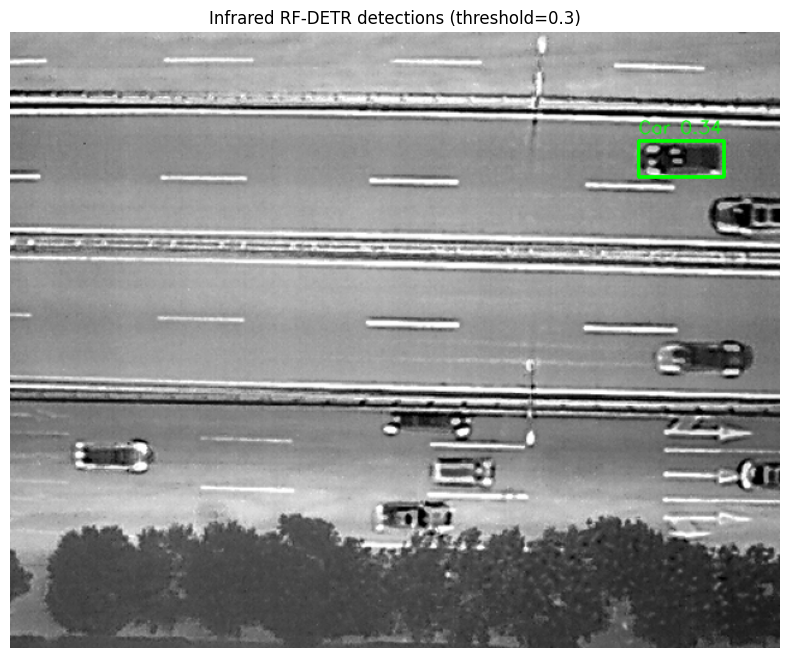

In [2]:
# ============================================================
# Cell 2: Load infrared-trained RF-DETR + visualize detections
# ============================================================

from pathlib import Path
import random
import torch
import cv2
import matplotlib.pyplot as plt
from rfdetr import RFDETRNano

# -----------------------------
# 1) Paths + config
# -----------------------------
PHASE_ROOT = Path.cwd().parent.parent
RFDETR_MODELS_DIR = PHASE_ROOT / "rfdetr" / "models"
INFRARED_RFDETR_MODELS_DIR = RFDETR_MODELS_DIR / "infrared-training"

CKPT_PATH = INFRARED_RFDETR_MODELS_DIR / "dronevehicle_rfdetr_nano_best_ema.pth"
FALLBACK_CKPT_PATH = INFRARED_RFDETR_MODELS_DIR / "dronevehicle_rfdetr_nano_latest_resume.pth"

VAL_IMG_DIR = PHASE_ROOT / "visdrone-dataset-infrared" / "val" / "valimgr"
THRESHOLD = 0.30

# DroneVehicle border crop policy used during training
REMOVE_WHITE_BORDER = True
BORDER_LEFT = 100
BORDER_RIGHT = 100
BORDER_TOP = 100
BORDER_BOTTOM = 100

# Phase class names
PHASE_CLASSES = {
    1: "Human",
    2: "Bicycle",
    3: "Car",
    4: "Truck",
    5: "Bus",
    6: "Other",
}

if CKPT_PATH.exists():
    RESOLVED_CKPT = CKPT_PATH
elif FALLBACK_CKPT_PATH.exists():
    RESOLVED_CKPT = FALLBACK_CKPT_PATH
else:
    raise FileNotFoundError(
        "No infrared-training checkpoint found.\n"
        f"Tried:\n- {CKPT_PATH}\n- {FALLBACK_CKPT_PATH}"
    )

assert VAL_IMG_DIR.exists(), f"Infrared val image dir not found: {VAL_IMG_DIR}"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
print("Checkpoint:", RESOLVED_CKPT)

# -----------------------------
# 2) Helpers
# -----------------------------
def collect_image_files(folder: Path):
    valid_suffixes = {".jpg", ".jpeg"}
    return sorted(
        [p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in valid_suffixes]
    )

def crop_white_border(img_bgr):
    if not REMOVE_WHITE_BORDER:
        return img_bgr

    h, w = img_bgr.shape[:2]
    cropped = img_bgr[BORDER_TOP:h-BORDER_BOTTOM, BORDER_LEFT:w-BORDER_RIGHT]

    expected_w = 840 - BORDER_LEFT - BORDER_RIGHT   # 640
    expected_h = 712 - BORDER_TOP - BORDER_BOTTOM   # 512

    assert cropped.shape[1] == expected_w, (
        f"Cropped width mismatch. Expected {expected_w}, got {cropped.shape[1]}"
    )
    assert cropped.shape[0] == expected_h, (
        f"Cropped height mismatch. Expected {expected_h}, got {cropped.shape[0]}"
    )

    return cropped

# -----------------------------
# 3) Load model
# -----------------------------
global DETECTOR, _DETECTOR_CKPT
if "DETECTOR" not in globals() or "_DETECTOR_CKPT" not in globals() or _DETECTOR_CKPT != str(RESOLVED_CKPT):
    print("Loading detector from checkpoint...")
    DETECTOR = RFDETRNano(num_classes=len(PHASE_CLASSES), pretrain_weights=str(RESOLVED_CKPT))
    _DETECTOR_CKPT = str(RESOLVED_CKPT)

DETECTOR.model.model.to(device)
DETECTOR.model.model.eval()
print("Detector loaded and ready.")

# -----------------------------
# 4) Pick a random infrared image and run prediction
# -----------------------------
imgs = collect_image_files(VAL_IMG_DIR)
assert imgs, f"No images found in: {VAL_IMG_DIR}"

image_path = str(random.choice(imgs))
print("Infrared sanity test image:", image_path)

img_bgr_original = cv2.imread(image_path)
if img_bgr_original is None:
    raise FileNotFoundError(f"Could not read image: {image_path}")

img_bgr_cropped = crop_white_border(img_bgr_original)

# Save temporary cropped file for prediction so inference matches training geometry
temp_infer_path = str(Path(image_path).with_name(Path(image_path).stem + "_cropped_for_inference.jpg"))
ok = cv2.imwrite(temp_infer_path, img_bgr_cropped)
assert ok, f"Failed to write temporary cropped inference image: {temp_infer_path}"

det = DETECTOR.predict(temp_infer_path, threshold=THRESHOLD)
print(f"Detections: {len(det.xyxy)} (threshold={THRESHOLD})")

# -----------------------------
# 5) Visualize boxes
# -----------------------------
img_rgb = cv2.cvtColor(img_bgr_cropped, cv2.COLOR_BGR2RGB)

for box, score, cls in zip(det.xyxy, det.confidence, det.class_id):
    x1, y1, x2, y2 = map(int, box.tolist())
    cls = int(cls)
    label = PHASE_CLASSES.get(cls, f"class_{cls}")
    text = f"{label} {float(score):.2f}"

    cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(
        img_rgb,
        text,
        (x1, max(0, y1 - 6)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (0, 255, 0),
        1,
        cv2.LINE_AA,
    )

plt.figure(figsize=(12, 8))
plt.imshow(img_rgb)
plt.axis("off")
plt.title(f"Infrared RF-DETR detections (threshold={THRESHOLD})")
plt.show()

In [3]:
# ============================================================
# Cell 3: Initialize ByteTrack
# ============================================================

import inspect
import numpy as np
import cv2

assert SUPERVISION_OK, "supervision is not installed/importable. Install with: pip install supervision"

# ---- Desired tracking settings (we'll tune later) ----
TRACK_THRESH = 0.30
TRACK_BUFFER = 30
MATCH_THRESH = 0.80
FRAME_RATE   = 30

# ---- Build kwargs based on what this supervision version supports ----
sig = inspect.signature(sv.ByteTrack.__init__)
params = set(sig.parameters.keys())

kwargs = {}

# Newer supervision naming
if "track_activation_threshold" in params:
    kwargs["track_activation_threshold"] = TRACK_THRESH
if "lost_track_buffer" in params:
    kwargs["lost_track_buffer"] = TRACK_BUFFER
if "minimum_matching_threshold" in params:
    kwargs["minimum_matching_threshold"] = MATCH_THRESH
if "frame_rate" in params:
    kwargs["frame_rate"] = FRAME_RATE

# Older naming (what we tried originally)
if "track_thresh" in params:
    kwargs["track_thresh"] = TRACK_THRESH
if "track_buffer" in params:
    kwargs["track_buffer"] = TRACK_BUFFER
if "match_thresh" in params:
    kwargs["match_thresh"] = MATCH_THRESH

# Fallback: if none of these are accepted, instantiate without args
try:
    TRACKER = sv.ByteTrack(**kwargs)
except TypeError:
    TRACKER = sv.ByteTrack()

print("ByteTrack initialized")
print("ByteTrack init kwargs used:", kwargs)

# -----------------------------
# Helper: RF-DETR detections -> supervision.Detections
# -----------------------------
def rfdetr_to_sv_detections(det, min_conf=0.30):
    xyxy = np.asarray(det.xyxy, dtype=np.float32)
    conf = np.asarray(det.confidence, dtype=np.float32)
    cls  = np.asarray(det.class_id, dtype=np.int32)

    keep = conf >= float(min_conf)
    return sv.Detections(
        xyxy=xyxy[keep],
        confidence=conf[keep],
        class_id=cls[keep]
    )

# -----------------------------
# Helper: Draw tracks
# -----------------------------
def draw_tracks(frame_bgr, detections: "sv.Detections", class_map: dict, show_conf=True):
    out = frame_bgr.copy()
    tracker_ids = getattr(detections, "tracker_id", None)

    for i, box in enumerate(detections.xyxy):
        x1, y1, x2, y2 = box.astype(int).tolist()
        cls = int(detections.class_id[i]) if detections.class_id is not None else -1
        conf = float(detections.confidence[i]) if detections.confidence is not None else 0.0

        tid = int(tracker_ids[i]) if tracker_ids is not None and tracker_ids[i] is not None else -1
        label = class_map.get(cls, f"class_{cls}")

        text = f"ID {tid}: {label}" if tid >= 0 else label
        if show_conf:
            text += f" {conf:.2f}"

        cv2.rectangle(out, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(out, text, (x1, max(0, y1 - 6)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1, cv2.LINE_AA)

    return out

def build_tensors_from_detections(detections: "sv.Detections") -> np.ndarray:
    if len(detections) == 0:
        return np.zeros((0, 5), dtype=np.float32)
    return np.hstack([
        detections.xyxy.astype(np.float32),
        detections.confidence.reshape(-1, 1).astype(np.float32),
    ])

print("Helpers ready: rfdetr_to_sv_detections(), draw_tracks()")

ByteTrack initialized
ByteTrack init kwargs used: {'track_activation_threshold': 0.3, 'lost_track_buffer': 30, 'minimum_matching_threshold': 0.8, 'frame_rate': 30}
Helpers ready: rfdetr_to_sv_detections(), draw_tracks()


In [4]:
# ============================================================
# Cell 4: Video paths, mandatory GT path, and experiment config
# ============================================================
Q
from pathlib import Path
import pandas as pd
import numpy as np

# -----------------------------
# Project paths
# -----------------------------
PHASE_ROOT = Path.cwd().parent.parent

VIDEO_PATH = PHASE_ROOT / "rfdetr" / "videos" / "personal_simulation" / "carla_rgb_speeds.mp4"
GT_CSV_PATH = PHASE_ROOT / "rfdetr" / "videos" / "personal_simulation" / "carla_rgb_speeds.csv"

OUTPUT_DIR = PHASE_ROOT / "rfdetr" / "videos" / "personal_simulation" / "speed_estimation_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_VIDEO_PATH = OUTPUT_DIR / "baseline_speed_estimation.mp4"
OUTPUT_OBS_CSV_PATH = OUTPUT_DIR / "baseline_speed_estimation_observations.csv"
OUTPUT_COMPARE_CSV_PATH = OUTPUT_DIR / "baseline_speed_estimation_vs_gt.csv"

CALIBRATION_JSON_PATH = OUTPUT_DIR / "reference_vehicle_image_points.json"

# -----------------------------
# Mandatory file checks
# -----------------------------
assert VIDEO_PATH.exists(), f"VIDEO_PATH does not exist: {VIDEO_PATH}"
assert GT_CSV_PATH.exists(), f"GT_CSV_PATH does not exist: {GT_CSV_PATH}"

# -----------------------------
# Class map
# -----------------------------
PHASE_CLASSES = {
    1: "Human",
    2: "Bicycle",
    3: "Car",
    4: "Truck",
    5: "Bus",
    6: "Other",
}

SPEED_ESTIMATION_CLASS_IDS = {3, 4, 5, 6}

# -----------------------------
# Detection / tracking config
# -----------------------------
DET_THRESHOLD = 0.30
MIN_BOX_AREA = 30 * 30
DETECT_EVERY_N = 1

TRACK_THRESH = 0.30
TRACK_BUFFER = 30
MATCH_THRESH = 0.80
DEFAULT_FPS = 30.0

# -----------------------------
# Representative point config
# -----------------------------
REPRESENTATIVE_POINT_MODE = "bottom_center"
BOTTOM_CENTER_Y_OFFSET_PX = 0.0
BORDER_MARGIN_PX = 20

# -----------------------------
# Smoothing / filtering config
# -----------------------------
DEFAULT_SPEED_WINDOW = 5
MIN_REASONABLE_SPEED_KMH = 0.0
MAX_REASONABLE_SPEED_KMH = 250.0

# -----------------------------
# Vehicle / camera priors
# -----------------------------
REFERENCE_VEHICLE_WIDTH_M = 2.16
REFERENCE_VEHICLE_LENGTH_M = 4.79
CAMERA_ALTITUDE_M = 25.0

# -----------------------------
# Geometry mode
# Current validated baseline:
#   vehicle_homography
# Future experiments can add:
#   altitude_scale_only
#   hybrid_homography_altitude
# -----------------------------
GEOMETRY_MODE = "vehicle_homography"

# -----------------------------
# Affine correction from old notebook
# -----------------------------
AFFINE_A = 0.375625
AFFINE_B = 5.341696

# -----------------------------
# GT comparison config
# -----------------------------
# This notebook always runs GT comparison.
GT_FRAME_COL_CANDIDATES = ["frame_idx", "frame"]
GT_SPEED_COL_CANDIDATES = [
    "speed_kmh",
    "gt_speed_kmh",
    "vehicle_speed_kmh",
    "speed",
]

# -----------------------------
# Calibration config
# -----------------------------
CALIBRATION_MODE = "json_if_available_else_manual"
CALIBRATION_FRAME_INDEX = 0

# If using hardcoded calibration, fill these in:
# order: front-left, front-right, rear-right, rear-left
HARDCODED_REFERENCE_VEHICLE_IMAGE_POINTS = None

CALIBRATION_DISPLAY_MAX_WIDTH = 1400
CALIBRATION_DISPLAY_MAX_HEIGHT = 900

print("=== Cell 4 Config Summary ===")
print("VIDEO_PATH              :", VIDEO_PATH)
print("GT_CSV_PATH             :", GT_CSV_PATH)
print("OUTPUT_VIDEO_PATH       :", OUTPUT_VIDEO_PATH)
print("OUTPUT_OBS_CSV_PATH     :", OUTPUT_OBS_CSV_PATH)
print("OUTPUT_COMPARE_CSV_PATH :", OUTPUT_COMPARE_CSV_PATH)
print("GEOMETRY_MODE           :", GEOMETRY_MODE)
print("REP_POINT_MODE          :", REPRESENTATIVE_POINT_MODE)
print("CAMERA_ALTITUDE_M       :", CAMERA_ALTITUDE_M)
print("============================")

=== Cell 4 Config Summary ===
VIDEO_PATH              : C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\carla_rgb_speeds.mp4
GT_CSV_PATH             : C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\carla_rgb_speeds.csv
OUTPUT_VIDEO_PATH       : C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\speed_estimation_outputs\baseline_speed_estimation.mp4
OUTPUT_OBS_CSV_PATH     : C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\speed_estimation_outputs\baseline_speed_estimation_observations.csv
OUTPUT_COMPARE_CSV_PATH : C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\speed_estimation_outputs\baseline_speed_estimation_vs_gt.csv
GEOMETRY_MODE           : vehicle_homography
REP_POINT_MODE          : bottom_center
CAMERA_ALTITUDE_M  

In [5]:
# ============================================================
# Cell 5: Geometry, speed, smoothing, GT, and metrics helpers
# ============================================================

import json
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Representative point helpers
# -----------------------------
def bbox_center_xyxy(box_xyxy):
    x1, y1, x2, y2 = map(float, box_xyxy)
    return np.array([(x1 + x2) / 2.0, (y1 + y2) / 2.0], dtype=np.float32)

def bbox_bottom_center_xyxy(box_xyxy, y_offset_px=0.0):
    x1, y1, x2, y2 = map(float, box_xyxy)
    cx = 0.5 * (x1 + x2)
    cy = y2 + float(y_offset_px)
    return np.array([cx, cy], dtype=np.float32)

def representative_point_xyxy(box_xyxy, mode="bottom_center", y_offset_px=0.0):
    if mode == "center":
        return bbox_center_xyxy(box_xyxy)
    elif mode == "bottom_center":
        return bbox_bottom_center_xyxy(box_xyxy, y_offset_px=y_offset_px)
    else:
        raise ValueError(f"Unsupported representative point mode: {mode}")

# -----------------------------
# Track / bbox helpers
# -----------------------------
def bbox_area_xyxy(box_xyxy):
    x1, y1, x2, y2 = map(float, box_xyxy)
    return max(0.0, x2 - x1) * max(0.0, y2 - y1)

def bbox_touches_border(box_xyxy, image_width, image_height, margin_px=20):
    x1, y1, x2, y2 = map(float, box_xyxy)
    return (
        x1 <= margin_px or
        y1 <= margin_px or
        x2 >= (image_width - margin_px) or
        y2 >= (image_height - margin_px)
    )

# -----------------------------
# Projection / speed helpers
# -----------------------------
def image_to_world_point_homography(point_xy, H_img_to_world):
    point_xy = np.asarray(point_xy, dtype=np.float32).reshape(1, 1, 2)
    world_xy = cv2.perspectiveTransform(point_xy, H_img_to_world).reshape(2)
    return world_xy.astype(np.float32)

def euclidean_distance_m(p1_world, p2_world):
    p1 = np.asarray(p1_world, dtype=np.float32)
    p2 = np.asarray(p2_world, dtype=np.float32)
    return float(np.linalg.norm(p2 - p1))

def speed_kmh_from_positions(p1_world, p2_world, frame_delta, fps):
    dt = float(frame_delta) / float(fps)
    if dt <= 0:
        return None
    dist_m = euclidean_distance_m(p1_world, p2_world)
    return float((dist_m / dt) * 3.6)

def is_reasonable_speed_kmh(speed_kmh, min_kmh=0.0, max_kmh=250.0):
    if speed_kmh is None:
        return False
    return float(min_kmh) <= float(speed_kmh) <= float(max_kmh)

def moving_average_ignore_none(values, window=5):
    recent = [float(v) for v in values if v is not None]
    if len(recent) == 0:
        return None
    recent = recent[-int(window):]
    return float(np.mean(recent))

def affine_correct_speed(speed_kmh, a=AFFINE_A, b=AFFINE_B):
    if speed_kmh is None:
        return None
    corrected = a * float(speed_kmh) + b
    return max(0.0, float(corrected))

# -----------------------------
# GT helpers
# -----------------------------
GT_FRAME_COL_CANDIDATES = [
    "frame_idx",
    "frame",
]

def resolve_first_existing_column(df, candidates, purpose="column"):
    for c in candidates:
        if c in df.columns:
            return c
    raise ValueError(
        f"Could not find {purpose}. Tried: {candidates}. "
        f"Available columns: {list(df.columns)}"
    )

def resolve_gt_speed_column(df, candidates):
    return resolve_first_existing_column(df, candidates, purpose="GT speed column")

def resolve_gt_frame_column(df, candidates):
    return resolve_first_existing_column(df, candidates, purpose="GT frame column")

def load_gt_csv(gt_csv_path):
    df = pd.read_csv(gt_csv_path)

    gt_frame_col = resolve_gt_frame_column(df, GT_FRAME_COL_CANDIDATES)
    gt_speed_col = resolve_gt_speed_column(df, GT_SPEED_COL_CANDIDATES)

    out = df[[gt_frame_col, gt_speed_col]].copy()
    out = out.rename(columns={
        gt_frame_col: "frame_idx",
        gt_speed_col: "gt_speed_kmh",
    })
    out = out.sort_values("frame_idx").reset_index(drop=True)
    return out

def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)

    keep = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[keep]
    y_pred = y_pred[keep]

    if len(y_true) == 0:
        return {
            "count": 0,
            "mae": np.nan,
            "rmse": np.nan,
            "bias": np.nan,
            "corr": np.nan,
        }

    err = y_pred - y_true
    mae = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err ** 2)))
    bias = float(np.mean(err))
    corr = float(np.corrcoef(y_true, y_pred)[0, 1]) if len(y_true) >= 2 else np.nan

    return {
        "count": int(len(y_true)),
        "mae": mae,
        "rmse": rmse,
        "bias": bias,
        "corr": corr,
    }

def summarize_metric_columns(compare_df, gt_col="gt_speed_kmh", pred_cols=None):
    if pred_cols is None:
        pred_cols = [
            "raw_speed_kmh",
            "smoothed_speed_kmh",
            "affine_corrected_speed_kmh",
        ]

    rows = []
    for c in pred_cols:
        if c in compare_df.columns:
            metrics = compute_metrics(compare_df[gt_col], compare_df[c])
            rows.append({
                "series": c,
                **metrics
            })
    return pd.DataFrame(rows).sort_values(["rmse", "mae"], na_position="last").reset_index(drop=True)

def plot_gt_vs_predictions(compare_df, frame_col="frame_idx"):
    plt.figure(figsize=(14, 6))
    plt.plot(compare_df[frame_col], compare_df["gt_speed_kmh"], label="GT speed", linewidth=2)

    for c in ["raw_speed_kmh", "smoothed_speed_kmh", "affine_corrected_speed_kmh"]:
        if c in compare_df.columns:
            plt.plot(compare_df[frame_col], compare_df[c], label=c)

    plt.xlabel("Frame")
    plt.ylabel("Speed (km/h)")
    plt.title("GT vs Predicted Speed")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

print("Helpers ready.")

Helpers ready.


In [6]:
# ============================================================
# Cell 6: Calibration + geometry initialization
# Baseline geometry mode: vehicle_homography
# ============================================================

import json
import cv2
import numpy as np

# -----------------------------
# Calibration I/O helpers
# -----------------------------
def save_reference_points_json(points, json_path):
    json_path = Path(json_path)
    json_path.parent.mkdir(parents=True, exist_ok=True)
    with open(json_path, "w") as f:
        json.dump({"reference_vehicle_image_points": np.asarray(points).tolist()}, f, indent=2)

def load_reference_points_json(json_path):
    json_path = Path(json_path)
    if not json_path.exists():
        return None
    with open(json_path, "r") as f:
        data = json.load(f)
    pts = data.get("reference_vehicle_image_points", None)
    if pts is None:
        return None
    pts = np.asarray(pts, dtype=np.float32)
    if pts.shape != (4, 2):
        raise ValueError(f"Expected (4,2) points in {json_path}, got {pts.shape}")
    return pts

def resize_for_display(image_bgr, max_width=1400, max_height=900):
    h, w = image_bgr.shape[:2]
    scale = min(max_width / w, max_height / h, 1.0)
    new_w = int(round(w * scale))
    new_h = int(round(h * scale))
    resized = cv2.resize(image_bgr, (new_w, new_h), interpolation=cv2.INTER_AREA)
    return resized, scale

def collect_manual_reference_points_from_video(
    video_path,
    frame_index=0,
    max_width=1400,
    max_height=900
):
    cap = cv2.VideoCapture(str(video_path))
    assert cap.isOpened(), f"Could not open video for calibration: {video_path}"

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frame_index = int(np.clip(frame_index, 0, max(0, total_frames - 1)))
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_index)

    ok, frame_bgr = cap.read()
    cap.release()
    assert ok, f"Could not read calibration frame {frame_index} from {video_path}"

    display_img, scale = resize_for_display(
        frame_bgr,
        max_width=max_width,
        max_height=max_height
    )

    clicked_points = []
    window_name = "Click 4 points: front-left, front-right, rear-right, rear-left"

    def mouse_cb(event, x, y, flags, param):
        if event == cv2.EVENT_LBUTTONDOWN and len(clicked_points) < 4:
            clicked_points.append([x / scale, y / scale])

    cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)
    cv2.setMouseCallback(window_name, mouse_cb)

    instruction_lines = [
        f"Frame {frame_index}",
        "Click in order:",
        "1) front-left",
        "2) front-right",
        "3) rear-right",
        "4) rear-left",
        "Press 'r' to reset, 'q' to cancel",
    ]

    while True:
        vis = display_img.copy()

        for i, pt in enumerate(clicked_points):
            dx = int(round(pt[0] * scale))
            dy = int(round(pt[1] * scale))
            cv2.circle(vis, (dx, dy), 6, (0, 0, 255), -1)
            cv2.putText(
                vis,
                str(i + 1),
                (dx + 8, dy - 8),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8,
                (0, 255, 255),
                2,
                cv2.LINE_AA
            )

        y0 = 30
        for idx, line in enumerate(instruction_lines):
            cv2.putText(
                vis,
                line,
                (20, y0 + idx * 28),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8,
                (255, 255, 255),
                2,
                cv2.LINE_AA
            )

        cv2.imshow(window_name, vis)
        key = cv2.waitKey(20) & 0xFF

        if key == ord("r"):
            clicked_points.clear()
        elif key == ord("q"):
            cv2.destroyWindow(window_name)
            raise RuntimeError("Calibration cancelled by user.")
        elif len(clicked_points) == 4:
            cv2.destroyWindow(window_name)
            break

    return np.asarray(clicked_points, dtype=np.float32)

def resolve_reference_vehicle_image_points():
    if CALIBRATION_MODE == "hardcoded":
        if HARDCODED_REFERENCE_VEHICLE_IMAGE_POINTS is None:
            raise ValueError(
                "CALIBRATION_MODE='hardcoded' but HARDCODED_REFERENCE_VEHICLE_IMAGE_POINTS is None."
            )
        pts = np.asarray(HARDCODED_REFERENCE_VEHICLE_IMAGE_POINTS, dtype=np.float32)
        if pts.shape != (4, 2):
            raise ValueError(f"Hardcoded calibration points must have shape (4,2), got {pts.shape}")
        return pts

    elif CALIBRATION_MODE == "manual_click":
        pts = collect_manual_reference_points_from_video(
            VIDEO_PATH,
            frame_index=CALIBRATION_FRAME_INDEX,
            max_width=CALIBRATION_DISPLAY_MAX_WIDTH,
            max_height=CALIBRATION_DISPLAY_MAX_HEIGHT,
        )
        save_reference_points_json(pts, CALIBRATION_JSON_PATH)
        return pts

    elif CALIBRATION_MODE == "json_if_available_else_manual":
        pts = load_reference_points_json(CALIBRATION_JSON_PATH)
        if pts is not None:
            print(f"Loaded calibration points from: {CALIBRATION_JSON_PATH}")
            return pts

        print("No saved calibration JSON found. Launching manual click calibration...")
        pts = collect_manual_reference_points_from_video(
            VIDEO_PATH,
            frame_index=CALIBRATION_FRAME_INDEX,
            max_width=CALIBRATION_DISPLAY_MAX_WIDTH,
            max_height=CALIBRATION_DISPLAY_MAX_HEIGHT,
        )
        save_reference_points_json(pts, CALIBRATION_JSON_PATH)
        print(f"Saved calibration points to: {CALIBRATION_JSON_PATH}")
        return pts

    else:
        raise ValueError(f"Unsupported CALIBRATION_MODE: {CALIBRATION_MODE}")

# -----------------------------
# Geometry initialization
# -----------------------------
def initialize_geometry():
    if GEOMETRY_MODE != "vehicle_homography":
        raise NotImplementedError(
            f"Only GEOMETRY_MODE='vehicle_homography' is implemented right now. "
            f"Got: {GEOMETRY_MODE}"
        )

    reference_world_points = np.array([
        [0.0,                       REFERENCE_VEHICLE_LENGTH_M],  # front-left
        [REFERENCE_VEHICLE_WIDTH_M, REFERENCE_VEHICLE_LENGTH_M],  # front-right
        [REFERENCE_VEHICLE_WIDTH_M, 0.0],                         # rear-right
        [0.0,                       0.0],                         # rear-left
    ], dtype=np.float32)

    reference_image_points = resolve_reference_vehicle_image_points()
    assert reference_image_points.shape == (4, 2), (
        f"Expected 4 image points, got shape {reference_image_points.shape}"
    )

    H_img_to_world = cv2.getPerspectiveTransform(
        reference_image_points.astype(np.float32),
        reference_world_points.astype(np.float32),
    )
    H_world_to_img = np.linalg.inv(H_img_to_world)

    geometry = {
        "mode": "vehicle_homography",
        "reference_image_points": reference_image_points,
        "reference_world_points": reference_world_points,
        "H_img_to_world": H_img_to_world,
        "H_world_to_img": H_world_to_img,
        "camera_altitude_m": CAMERA_ALTITUDE_M,
        "reference_vehicle_width_m": REFERENCE_VEHICLE_WIDTH_M,
        "reference_vehicle_length_m": REFERENCE_VEHICLE_LENGTH_M,
    }
    return geometry

GEOMETRY = initialize_geometry()

print("=== Geometry Initialized ===")
print("Mode:", GEOMETRY["mode"])
print("Reference image points:")
print(GEOMETRY["reference_image_points"])
print("Camera altitude (m):", GEOMETRY["camera_altitude_m"])
print("============================")

Loaded calibration points from: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\speed_estimation_outputs\reference_vehicle_image_points.json
=== Geometry Initialized ===
Mode: vehicle_homography
Reference image points:
[[431. 286.]
 [428. 316.]
 [371. 312.]
 [373. 285.]]
Camera altitude (m): 25.0


In [7]:
# ============================================================
# Cell 7: Track-history bookkeeping
# ============================================================

import numpy as np

def make_empty_track_history(speed_window=5):
    return {
        "frames": [],
        "boxes": [],
        "image_points": [],
        "world_points": [],
        "raw_speeds_kmh": [],
        "smoothed_speeds_kmh": [],
        "affine_corrected_speeds_kmh": [],
        "class_id": None,
        "confidence": None,
        "speed_window": int(speed_window),
    }

def get_or_create_track_history(track_histories, track_id, speed_window=5):
    track_id = int(track_id)
    if track_id not in track_histories:
        track_histories[track_id] = make_empty_track_history(speed_window=speed_window)
    return track_histories[track_id]

def append_track_observation(
    track_history,
    frame_idx,
    box_xyxy,
    class_id,
    confidence,
    fps,
    geometry,
    rep_point_mode="bottom_center",
    rep_y_offset_px=0.0,
):
    img_pt = representative_point_xyxy(
        box_xyxy,
        mode=rep_point_mode,
        y_offset_px=rep_y_offset_px
    )

    if geometry["mode"] == "vehicle_homography":
        world_pt = image_to_world_point_homography(
            img_pt,
            H_img_to_world=geometry["H_img_to_world"]
        )
    else:
        raise NotImplementedError(f"Unsupported geometry mode: {geometry['mode']}")

    track_history["frames"].append(int(frame_idx))
    track_history["boxes"].append(np.asarray(box_xyxy, dtype=np.float32))
    track_history["image_points"].append(img_pt)
    track_history["world_points"].append(world_pt)
    track_history["class_id"] = int(class_id) if class_id is not None else None
    track_history["confidence"] = float(confidence) if confidence is not None else None

    raw_speed_kmh = None
    if len(track_history["world_points"]) >= 2:
        p1 = track_history["world_points"][-2]
        p2 = track_history["world_points"][-1]
        f1 = track_history["frames"][-2]
        f2 = track_history["frames"][-1]

        raw_speed_kmh = speed_kmh_from_positions(p1, p2, f2 - f1, fps)
        if raw_speed_kmh is not None and not is_reasonable_speed_kmh(
            raw_speed_kmh,
            min_kmh=MIN_REASONABLE_SPEED_KMH,
            max_kmh=MAX_REASONABLE_SPEED_KMH,
        ):
            raw_speed_kmh = None

    track_history["raw_speeds_kmh"].append(raw_speed_kmh)

    smoothed_speed_kmh = moving_average_ignore_none(
        track_history["raw_speeds_kmh"],
        window=track_history["speed_window"]
    )
    track_history["smoothed_speeds_kmh"].append(smoothed_speed_kmh)

    affine_corrected_speed_kmh = affine_correct_speed(
        smoothed_speed_kmh,
        a=AFFINE_A,
        b=AFFINE_B,
    )
    track_history["affine_corrected_speeds_kmh"].append(affine_corrected_speed_kmh)

    return track_history

def active_tracks_to_boxes_and_ids(tracker):
    tracks = getattr(tracker, "tracked_tracks", [])
    boxes, ids = [], []
    for t in tracks:
        boxes.append(np.array(t.tlbr, dtype=np.float32))
        ids.append(int(t.external_track_id))
    return boxes, ids

print("Track-history helpers ready.")

Track-history helpers ready.


=== Running baseline pipeline ===
Video      : C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\carla_rgb_speeds.mp4
GT CSV     : C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\carla_rgb_speeds.csv
FPS        : 20.0
Frame size : 800x600
Frames     : 521


Baseline speed pipeline:   0%|          | 0/521 [00:00<?, ?it/s]


=== Baseline Run Complete ===
Dominant track ID        : 1
Saved annotated video    : C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\speed_estimation_outputs\baseline_speed_estimation.mp4
Saved observations CSV   : C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\speed_estimation_outputs\baseline_speed_estimation_observations.csv
Saved comparison CSV     : C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\speed_estimation_outputs\baseline_speed_estimation_vs_gt.csv
Observation rows         : 486
GT comparison rows       : 486



,series,count,mae,rmse,bias,corr
0,smoothed_speed_kmh,485,6.995457,10.820124,3.000802,0.848227
1,raw_speed_kmh,485,7.308447,11.028200,3.100407,0.846470
2,affine_corrected_speed_kmh,485,9.458065,11.849299,-6.766384,0.848227


,frame_idx,gt_speed_kmh,raw_speed_kmh,smoothed_speed_kmh,affine_corrected_speed_kmh
0,4,6.92,NaN,NaN,NaN
1,5,3.04,0.415493,0.415493,5.497766
2,6,1.17,0.125692,0.270593,5.443337
3,7,0.26,0.196296,0.245827,5.434035
4,8,0.14,0.139446,0.219232,5.424045


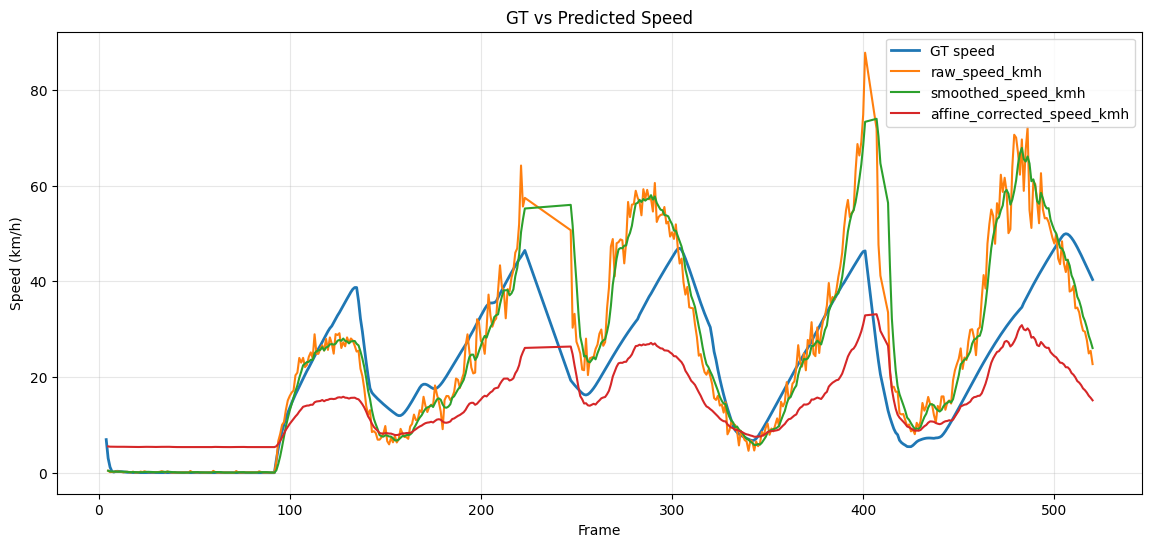

In [8]:
# ============================================================
# Cell 8: Full baseline pipeline + mandatory GT comparison
# ============================================================

import inspect
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

assert "DETECTOR" in globals(), "DETECTOR is not loaded. Run Cell 2 first."
assert "TRACKER" in globals(), "TRACKER is not initialized. Run Cell 3 first."
assert GEOMETRY_MODE == "vehicle_homography", "Baseline Cell 8 currently expects vehicle_homography."

# -----------------------------
# Reinitialize tracker with current settings if needed
# -----------------------------
sig = inspect.signature(sv.ByteTrack.__init__)
params = set(sig.parameters.keys())
kwargs = {}

if "track_activation_threshold" in params:
    kwargs["track_activation_threshold"] = TRACK_THRESH
if "lost_track_buffer" in params:
    kwargs["lost_track_buffer"] = TRACK_BUFFER
if "minimum_matching_threshold" in params:
    kwargs["minimum_matching_threshold"] = MATCH_THRESH
if "frame_rate" in params:
    kwargs["frame_rate"] = int(DEFAULT_FPS)

if "track_thresh" in params:
    kwargs["track_thresh"] = TRACK_THRESH
if "track_buffer" in params:
    kwargs["track_buffer"] = TRACK_BUFFER
if "match_thresh" in params:
    kwargs["match_thresh"] = MATCH_THRESH

try:
    TRACKER = sv.ByteTrack(**kwargs)
except TypeError:
    TRACKER = sv.ByteTrack()

# -----------------------------
# Open video
# -----------------------------
cap = cv2.VideoCapture(str(VIDEO_PATH))
assert cap.isOpened(), f"Could not open video: {VIDEO_PATH}"

fps = cap.get(cv2.CAP_PROP_FPS)
if fps is None or fps <= 1:
    fps = DEFAULT_FPS

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(str(OUTPUT_VIDEO_PATH), fourcc, fps, (width, height))
assert writer.isOpened(), f"Could not open video writer: {OUTPUT_VIDEO_PATH}"

try:
    if hasattr(TRACKER, "frame_rate"):
        TRACKER.frame_rate = int(round(fps))
except Exception:
    pass

if hasattr(TRACKER, "reset"):
    TRACKER.reset()

# -----------------------------
# Runtime state
# -----------------------------
track_histories = {}
track_meta = {}
output_rows = []

temp_infer_path = OUTPUT_DIR / "_temp_frame_for_inference.jpg"

print("=== Running baseline pipeline ===")
print("Video      :", VIDEO_PATH)
print("GT CSV     :", GT_CSV_PATH)
print("FPS        :", fps)
print("Frame size :", f"{width}x{height}")
print("Frames     :", total_frames)
print("=================================")

pbar = tqdm(total=total_frames, desc="Baseline speed pipeline")

for frame_idx in range(total_frames):
    ok, frame_bgr = cap.read()
    if not ok:
        break

    # -------------------------
    # Detection
    # -------------------------
    if frame_idx % DETECT_EVERY_N == 0:
        ok_write = cv2.imwrite(str(temp_infer_path), frame_bgr)
        assert ok_write, f"Failed to write temp frame for inference: {temp_infer_path}"

        det = DETECTOR.predict(str(temp_infer_path), threshold=DET_THRESHOLD)
        detections = rfdetr_to_sv_detections(det, min_conf=DET_THRESHOLD)

        if len(detections) > 0:
            xyxy = detections.xyxy
            areas = (xyxy[:, 2] - xyxy[:, 0]) * (xyxy[:, 3] - xyxy[:, 1])
            keep = areas >= MIN_BOX_AREA
            detections = detections[keep]

        tensors = build_tensors_from_detections(detections)

        det_with_ids = TRACKER.update_with_detections(detections)

        if len(det_with_ids) > 0 and getattr(det_with_ids, "tracker_id", None) is not None:
            for i in range(len(det_with_ids)):
                tid = int(det_with_ids.tracker_id[i])
                cls = int(det_with_ids.class_id[i])
                conf = float(det_with_ids.confidence[i])
                track_meta[tid] = (cls, conf)

    else:
        _ = TRACKER.update_with_tensors(np.zeros((0, 5), dtype=np.float32))

    # -------------------------
    # Draw / estimate speed
    # -------------------------
    boxes, ids = active_tracks_to_boxes_and_ids(TRACKER)
    out = frame_bgr.copy()

    for box, tid in zip(boxes, ids):
        cls, conf = track_meta.get(tid, (-1, 0.0))
        label = PHASE_CLASSES.get(cls, f"class_{cls}") if cls != -1 else "unknown"

        x1, y1, x2, y2 = box.astype(int).tolist()
        cv2.rectangle(out, (x1, y1), (x2, y2), (0, 255, 0), 2)

        rep_pt = representative_point_xyxy(
            box,
            mode=REPRESENTATIVE_POINT_MODE,
            y_offset_px=BOTTOM_CENTER_Y_OFFSET_PX
        )
        rep_x, rep_y = map(int, np.round(rep_pt))
        cv2.circle(out, (rep_x, rep_y), 4, (0, 0, 255), -1)

        display_speed = None
        raw_speed = None
        smooth_speed = None
        world_pt = None

        if cls in SPEED_ESTIMATION_CLASS_IDS:
            touches_border = bbox_touches_border(
                box,
                image_width=width,
                image_height=height,
                margin_px=BORDER_MARGIN_PX
            )

            if not touches_border:
                hist = get_or_create_track_history(
                    track_histories,
                    tid,
                    speed_window=DEFAULT_SPEED_WINDOW
                )

                append_track_observation(
                    track_history=hist,
                    frame_idx=frame_idx,
                    box_xyxy=box,
                    class_id=cls,
                    confidence=conf,
                    fps=fps,
                    geometry=GEOMETRY,
                    rep_point_mode=REPRESENTATIVE_POINT_MODE,
                    rep_y_offset_px=BOTTOM_CENTER_Y_OFFSET_PX,
                )

                raw_speed = hist["raw_speeds_kmh"][-1]
                smooth_speed = hist["smoothed_speeds_kmh"][-1]
                display_speed = hist["affine_corrected_speeds_kmh"][-1]
                world_pt = hist["world_points"][-1]

                output_rows.append({
                    "track_id": int(tid),
                    "frame_idx": int(frame_idx),
                    "class_id": int(cls),
                    "label": label,
                    "confidence": float(conf),

                    "bbox_x1": float(box[0]),
                    "bbox_y1": float(box[1]),
                    "bbox_x2": float(box[2]),
                    "bbox_y2": float(box[3]),

                    "rep_image_x": float(rep_pt[0]),
                    "rep_image_y": float(rep_pt[1]),

                    "world_x": float(world_pt[0]),
                    "world_y": float(world_pt[1]),

                    "raw_speed_kmh": raw_speed,
                    "smoothed_speed_kmh": smooth_speed,
                    "affine_corrected_speed_kmh": display_speed,
                })

        # Draw short trail
        if tid in track_histories and len(track_histories[tid]["image_points"]) >= 2:
            pts = np.array(track_histories[tid]["image_points"][-20:], dtype=np.float32)
            pts = np.round(pts).astype(int)
            for j in range(1, len(pts)):
                cv2.line(out, tuple(pts[j - 1]), tuple(pts[j]), (255, 0, 0), 2, cv2.LINE_AA)

        text = f"ID {tid}: {label} {conf:.2f}"
        if display_speed is not None:
            text += f" | {display_speed:.2f} km/h"

        cv2.putText(
            out,
            text,
            (x1, max(0, y1 - 6)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 255, 0),
            1,
            cv2.LINE_AA,
        )

    writer.write(out)
    pbar.update(1)

pbar.close()
cap.release()
writer.release()

if temp_infer_path.exists():
    try:
        temp_infer_path.unlink()
    except Exception:
        pass

# -----------------------------
# Save observations
# -----------------------------
obs_df = pd.DataFrame(output_rows)
assert len(obs_df) > 0, "No observations were collected."

obs_df.to_csv(OUTPUT_OBS_CSV_PATH, index=False)

# -----------------------------
# Mandatory GT comparison
# -----------------------------
gt_df = load_gt_csv(GT_CSV_PATH)

# Choose dominant track for evaluation
track_counts = obs_df["track_id"].value_counts().sort_values(ascending=False)
assert len(track_counts) > 0, "No track IDs found in observations."

dominant_track_id = int(track_counts.index[0])
eval_df = obs_df[obs_df["track_id"] == dominant_track_id].copy()
eval_df = eval_df.sort_values("frame_idx").reset_index(drop=True)

compare_df = gt_df.merge(
    eval_df[[
        "frame_idx",
        "raw_speed_kmh",
        "smoothed_speed_kmh",
        "affine_corrected_speed_kmh"
    ]],
    on="frame_idx",
    how="inner"
)

assert len(compare_df) > 0, (
    "GT comparison merge produced 0 rows. "
    f"GT frames: {len(gt_df)}, prediction rows for dominant track: {len(eval_df)}"
)

compare_df.to_csv(OUTPUT_COMPARE_CSV_PATH, index=False)

metrics_df = summarize_metric_columns(
    compare_df,
    gt_col="gt_speed_kmh",
    pred_cols=[
        "raw_speed_kmh",
        "smoothed_speed_kmh",
        "affine_corrected_speed_kmh",
    ]
)

print("\n=== Baseline Run Complete ===")
print("Dominant track ID        :", dominant_track_id)
print("Saved annotated video    :", OUTPUT_VIDEO_PATH)
print("Saved observations CSV   :", OUTPUT_OBS_CSV_PATH)
print("Saved comparison CSV     :", OUTPUT_COMPARE_CSV_PATH)
print("Observation rows         :", len(obs_df))
print("GT comparison rows       :", len(compare_df))
print("=============================\n")

display(metrics_df)
display(compare_df.head())

plot_gt_vs_predictions(compare_df, frame_col="frame_idx")

=== Baseline Diagnostic Summary ===
Current dominant track ID : 1
Old dominant track ID     : 1
Current compare rows      : 486
Old compare rows          : 486
Current observations path : C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\speed_estimation_outputs\baseline_speed_estimation_observations.csv
Old observations path     : C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\final_best_pipeline_observations.csv


count                           mae  \
source                     current_notebook old_notebook current_notebook   
series                                                                      
affine_corrected_speed_kmh            485.0        485.0         9.458065   
raw_speed_kmh                         485.0        485.0         7.308447   
smoothed_speed_kmh                    485.0        485.0         6.995457   

                                                    rmse               \
source                     old_notebook current_notebook old_notebook   
series                                                                  
affine_corrected_speed_kmh     6.092186        11.849299     7.410849   
raw_speed_kmh                 20.894170        11.028200    30.642866   
smoothed_speed_kmh            20.533845        10.820124    30.149496   

                                       bias                          corr  \
source                     current_notebook old_notebook current_notebook   
series                                                                      
affine_corrected_speed_kmh        -6.766384    -0.164230         0.848227   
raw_speed_kmh                      3.100407    20.636972         0.846470   
smoothed_speed_kmh                 3.000802    20.442115         0.848227   

                                         
source                     old_notebook  
series                                   
affine_corrected_speed_kmh     0.871566  
raw_speed_kmh                  0.870005  
smoothed_speed_kmh             0.871566

,series,delta_mae_current_minus_old,delta_rmse_current_minus_old,delta_bias_current_minus_old,delta_corr_current_minus_old,current_count,old_count
0,raw_speed_kmh,-13.585723,-19.614667,-17.536565,-0.023535,485.0,485.0
1,smoothed_speed_kmh,-13.538388,-19.329373,-17.441313,-0.023338,485.0,485.0
2,affine_corrected_speed_kmh,3.365880,4.438450,-6.602154,-0.023338,485.0,485.0


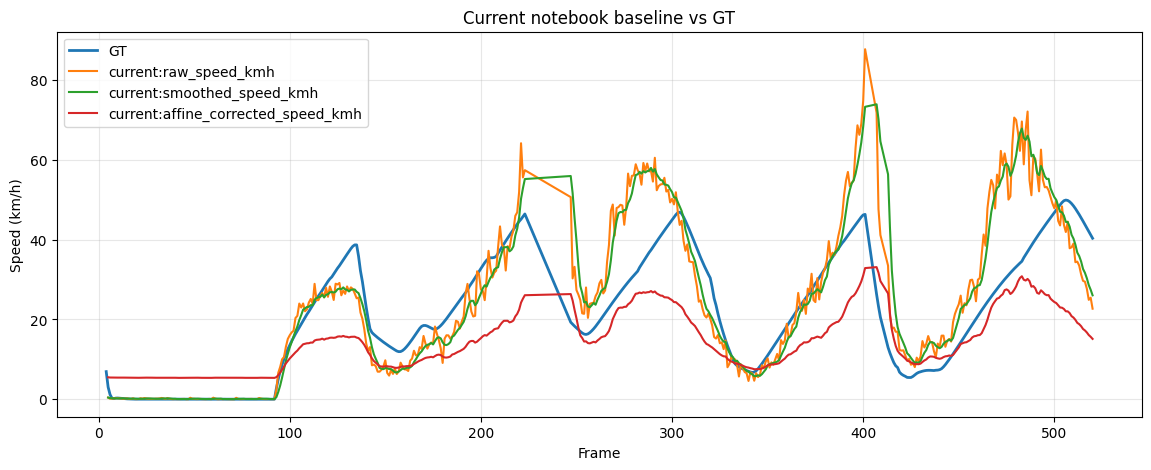

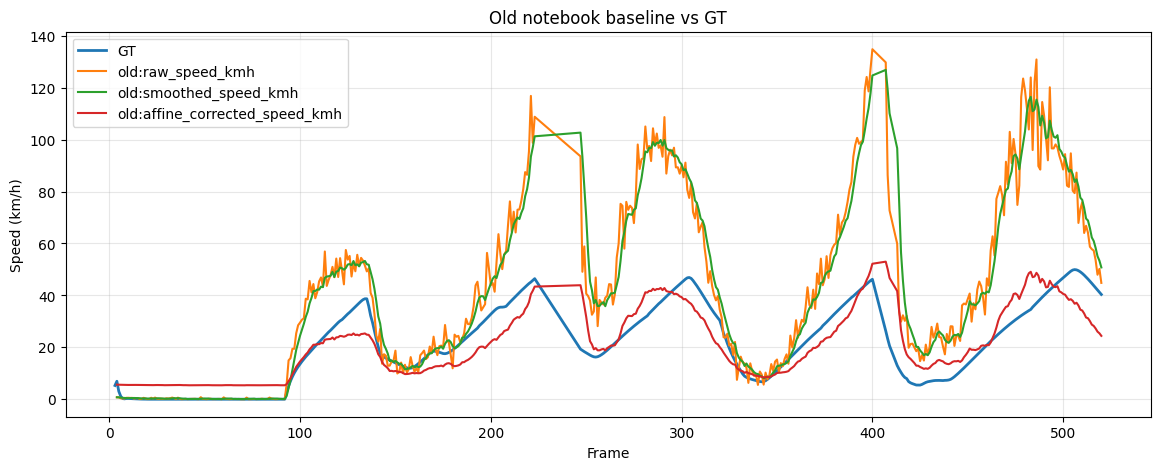

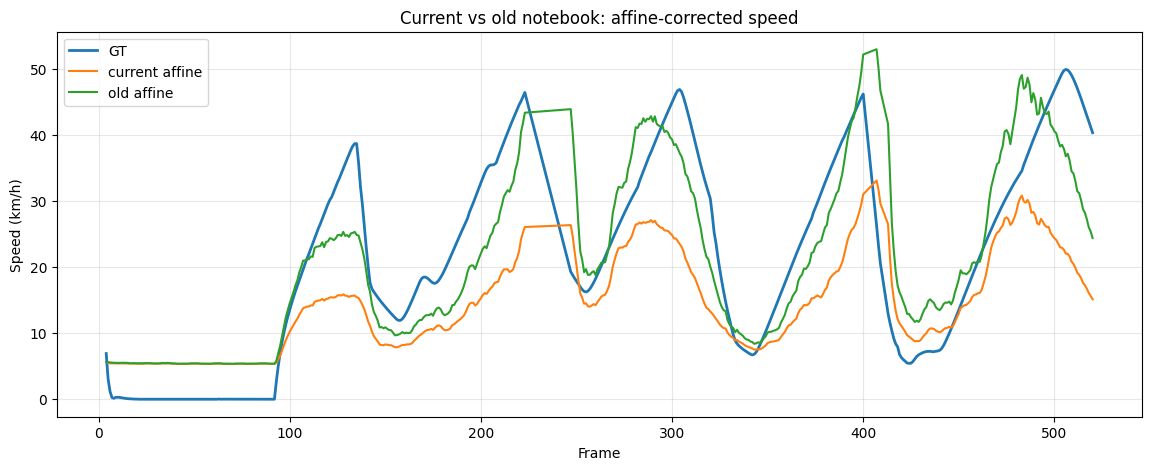

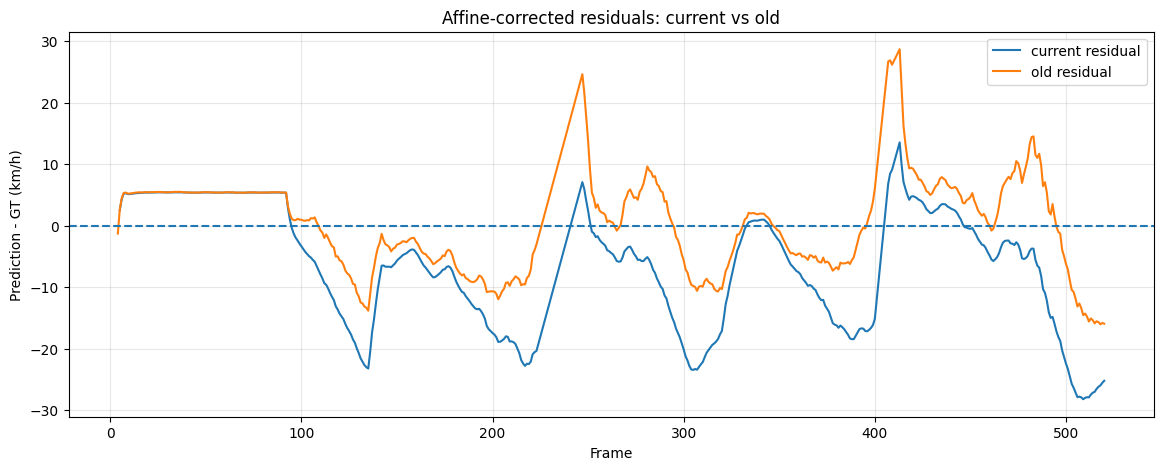

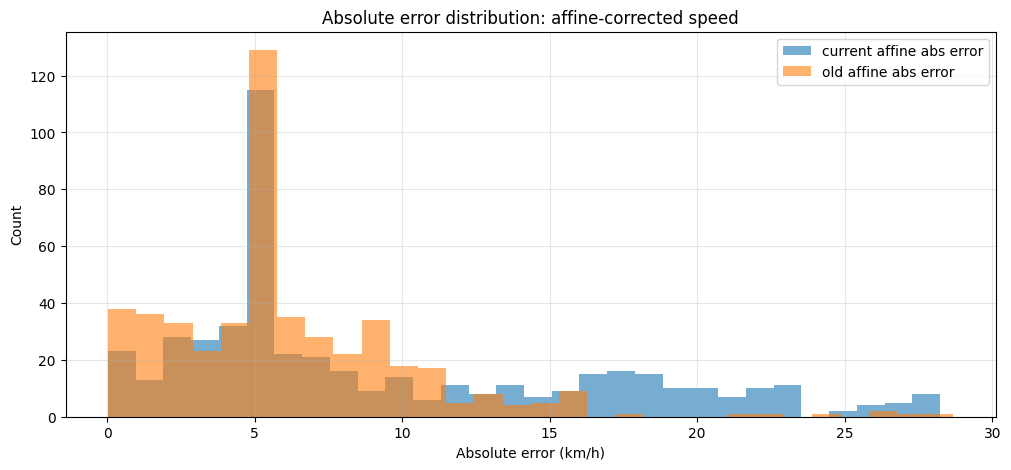

=== Affine-Corrected Headline Check ===
MAE  : 3.3659 -> worse
RMSE : 4.4385 -> worse
Corr : -0.0233 -> worse


In [9]:
# ============================================================
# Cell 9: Baseline diagnostics + comparison vs old notebook
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# -----------------------------
# 1) Paths
# -----------------------------
OLD_OBS_CSV_PATH = PHASE_ROOT / "rfdetr" / "videos" / "personal_simulation" / "final_best_pipeline_observations.csv"

assert OUTPUT_OBS_CSV_PATH.exists(), f"Current observations CSV not found: {OUTPUT_OBS_CSV_PATH}"
assert OUTPUT_COMPARE_CSV_PATH.exists(), f"Current comparison CSV not found: {OUTPUT_COMPARE_CSV_PATH}"
assert GT_CSV_PATH.exists(), f"GT CSV not found: {GT_CSV_PATH}"
assert OLD_OBS_CSV_PATH.exists(), f"Old notebook observations CSV not found: {OLD_OBS_CSV_PATH}"

# -----------------------------
# 2) Load current run outputs
# -----------------------------
current_obs_df = pd.read_csv(OUTPUT_OBS_CSV_PATH)
current_compare_df = pd.read_csv(OUTPUT_COMPARE_CSV_PATH)
gt_df = load_gt_csv(GT_CSV_PATH)

assert len(current_obs_df) > 0, "Current observations CSV is empty."
assert len(current_compare_df) > 0, "Current comparison CSV is empty."

# -----------------------------
# 3) Load old notebook observations and rebuild comparison
# -----------------------------
old_obs_df = pd.read_csv(OLD_OBS_CSV_PATH)
assert len(old_obs_df) > 0, "Old notebook observations CSV is empty."

required_old_cols = {
    "track_id",
    "frame_idx",
    "raw_speed_kmh",
    "smoothed_speed_kmh",
    "affine_corrected_speed_kmh",
}
missing_old = required_old_cols - set(old_obs_df.columns)
assert not missing_old, (
    f"Old observations CSV is missing required columns: {missing_old}. "
    f"Available columns: {list(old_obs_df.columns)}"
)

old_track_counts = old_obs_df["track_id"].value_counts().sort_values(ascending=False)
assert len(old_track_counts) > 0, "No track_id values found in old observations CSV."

old_dominant_track_id = int(old_track_counts.index[0])

old_eval_df = (
    old_obs_df[old_obs_df["track_id"] == old_dominant_track_id]
    .sort_values("frame_idx")
    .reset_index(drop=True)
)

old_compare_df = gt_df.merge(
    old_eval_df[
        [
            "frame_idx",
            "raw_speed_kmh",
            "smoothed_speed_kmh",
            "affine_corrected_speed_kmh",
        ]
    ],
    on="frame_idx",
    how="inner",
)

assert len(old_compare_df) > 0, (
    "Old GT comparison merge produced 0 rows. "
    f"GT rows: {len(gt_df)}, old dominant-track rows: {len(old_eval_df)}"
)

# -----------------------------
# 4) Metrics tables
# -----------------------------
current_metrics_df = summarize_metric_columns(
    current_compare_df,
    gt_col="gt_speed_kmh",
    pred_cols=[
        "raw_speed_kmh",
        "smoothed_speed_kmh",
        "affine_corrected_speed_kmh",
    ]
).copy()
current_metrics_df["source"] = "current_notebook"

old_metrics_df = summarize_metric_columns(
    old_compare_df,
    gt_col="gt_speed_kmh",
    pred_cols=[
        "raw_speed_kmh",
        "smoothed_speed_kmh",
        "affine_corrected_speed_kmh",
    ]
).copy()
old_metrics_df["source"] = "old_notebook"

combined_metrics_df = pd.concat([current_metrics_df, old_metrics_df], ignore_index=True)

metric_pivot_df = (
    combined_metrics_df
    .pivot(index="series", columns="source", values=["count", "mae", "rmse", "bias", "corr"])
    .sort_index()
)

# -----------------------------
# 5) Delta table: current - old
# Negative MAE/RMSE is better
# Bias delta closer to 0 is better, but we show raw difference
# Positive corr delta is better
# -----------------------------
def _metric_lookup(df, series, metric):
    row = df[df["series"] == series]
    if len(row) == 0:
        return np.nan
    return float(row.iloc[0][metric])

delta_rows = []
for series in ["raw_speed_kmh", "smoothed_speed_kmh", "affine_corrected_speed_kmh"]:
    delta_rows.append({
        "series": series,
        "delta_mae_current_minus_old": _metric_lookup(current_metrics_df, series, "mae") - _metric_lookup(old_metrics_df, series, "mae"),
        "delta_rmse_current_minus_old": _metric_lookup(current_metrics_df, series, "rmse") - _metric_lookup(old_metrics_df, series, "rmse"),
        "delta_bias_current_minus_old": _metric_lookup(current_metrics_df, series, "bias") - _metric_lookup(old_metrics_df, series, "bias"),
        "delta_corr_current_minus_old": _metric_lookup(current_metrics_df, series, "corr") - _metric_lookup(old_metrics_df, series, "corr"),
        "current_count": _metric_lookup(current_metrics_df, series, "count"),
        "old_count": _metric_lookup(old_metrics_df, series, "count"),
    })

delta_df = pd.DataFrame(delta_rows)

# -----------------------------
# 6) Residual helpers
# -----------------------------
def add_residual_columns(df, pred_cols):
    out = df.copy()
    for c in pred_cols:
        if c in out.columns:
            out[f"{c}_residual"] = out[c] - out["gt_speed_kmh"]
            out[f"{c}_abs_error"] = np.abs(out[c] - out["gt_speed_kmh"])
    return out

current_compare_diag_df = add_residual_columns(
    current_compare_df,
    ["raw_speed_kmh", "smoothed_speed_kmh", "affine_corrected_speed_kmh"]
)

old_compare_diag_df = add_residual_columns(
    old_compare_df,
    ["raw_speed_kmh", "smoothed_speed_kmh", "affine_corrected_speed_kmh"]
)

# -----------------------------
# 7) Console summary
# -----------------------------
print("=== Baseline Diagnostic Summary ===")
print("Current dominant track ID :", int(current_obs_df['track_id'].value_counts().index[0]))
print("Old dominant track ID     :", old_dominant_track_id)
print("Current compare rows      :", len(current_compare_df))
print("Old compare rows          :", len(old_compare_df))
print("Current observations path :", OUTPUT_OBS_CSV_PATH)
print("Old observations path     :", OLD_OBS_CSV_PATH)
print("===================================")

display(metric_pivot_df)
display(delta_df)

# -----------------------------
# 8) Plot 1: Current GT vs current predictions
# -----------------------------
plt.figure(figsize=(14, 5))
plt.plot(current_compare_df["frame_idx"], current_compare_df["gt_speed_kmh"], label="GT", linewidth=2)
for c in ["raw_speed_kmh", "smoothed_speed_kmh", "affine_corrected_speed_kmh"]:
    if c in current_compare_df.columns:
        plt.plot(current_compare_df["frame_idx"], current_compare_df[c], label=f"current:{c}")
plt.title("Current notebook baseline vs GT")
plt.xlabel("Frame")
plt.ylabel("Speed (km/h)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# -----------------------------
# 9) Plot 2: Old GT vs old predictions
# -----------------------------
plt.figure(figsize=(14, 5))
plt.plot(old_compare_df["frame_idx"], old_compare_df["gt_speed_kmh"], label="GT", linewidth=2)
for c in ["raw_speed_kmh", "smoothed_speed_kmh", "affine_corrected_speed_kmh"]:
    if c in old_compare_df.columns:
        plt.plot(old_compare_df["frame_idx"], old_compare_df[c], label=f"old:{c}")
plt.title("Old notebook baseline vs GT")
plt.xlabel("Frame")
plt.ylabel("Speed (km/h)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# -----------------------------
# 10) Plot 3: Current vs old affine-corrected prediction
# -----------------------------
merged_affine_df = (
    current_compare_df[["frame_idx", "gt_speed_kmh", "affine_corrected_speed_kmh"]]
    .rename(columns={"affine_corrected_speed_kmh": "current_affine_corrected_speed_kmh"})
    .merge(
        old_compare_df[["frame_idx", "affine_corrected_speed_kmh"]].rename(
            columns={"affine_corrected_speed_kmh": "old_affine_corrected_speed_kmh"}
        ),
        on="frame_idx",
        how="inner"
    )
)

plt.figure(figsize=(14, 5))
plt.plot(merged_affine_df["frame_idx"], merged_affine_df["gt_speed_kmh"], label="GT", linewidth=2)
plt.plot(merged_affine_df["frame_idx"], merged_affine_df["current_affine_corrected_speed_kmh"], label="current affine")
plt.plot(merged_affine_df["frame_idx"], merged_affine_df["old_affine_corrected_speed_kmh"], label="old affine")
plt.title("Current vs old notebook: affine-corrected speed")
plt.xlabel("Frame")
plt.ylabel("Speed (km/h)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# -----------------------------
# 11) Plot 4: Residual comparison for affine-corrected speed
# -----------------------------
merged_resid_df = (
    current_compare_diag_df[["frame_idx", "affine_corrected_speed_kmh_residual"]]
    .rename(columns={"affine_corrected_speed_kmh_residual": "current_residual"})
    .merge(
        old_compare_diag_df[["frame_idx", "affine_corrected_speed_kmh_residual"]].rename(
            columns={"affine_corrected_speed_kmh_residual": "old_residual"}
        ),
        on="frame_idx",
        how="inner"
    )
)

plt.figure(figsize=(14, 5))
plt.plot(merged_resid_df["frame_idx"], merged_resid_df["current_residual"], label="current residual")
plt.plot(merged_resid_df["frame_idx"], merged_resid_df["old_residual"], label="old residual")
plt.axhline(0.0, linestyle="--")
plt.title("Affine-corrected residuals: current vs old")
plt.xlabel("Frame")
plt.ylabel("Prediction - GT (km/h)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# -----------------------------
# 12) Plot 5: Absolute error histograms for affine-corrected speed
# -----------------------------
plt.figure(figsize=(12, 5))
plt.hist(
    current_compare_diag_df["affine_corrected_speed_kmh_abs_error"].dropna(),
    bins=30,
    alpha=0.6,
    label="current affine abs error"
)
plt.hist(
    old_compare_diag_df["affine_corrected_speed_kmh_abs_error"].dropna(),
    bins=30,
    alpha=0.6,
    label="old affine abs error"
)
plt.title("Absolute error distribution: affine-corrected speed")
plt.xlabel("Absolute error (km/h)")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# -----------------------------
# 13) Quick interpretation
# -----------------------------
def verdict_from_delta(delta_value, metric_name):
    if np.isnan(delta_value):
        return "n/a"
    if metric_name in {"mae", "rmse"}:
        if delta_value < 0:
            return "better"
        elif delta_value > 0:
            return "worse"
        return "same"
    if metric_name == "corr":
        if delta_value > 0:
            return "better"
        elif delta_value < 0:
            return "worse"
        return "same"
    return "changed"

affine_row = delta_df[delta_df["series"] == "affine_corrected_speed_kmh"].iloc[0]

print("=== Affine-Corrected Headline Check ===")
print(f"MAE  : {affine_row['delta_mae_current_minus_old']:.4f} -> {verdict_from_delta(affine_row['delta_mae_current_minus_old'], 'mae')}")
print(f"RMSE : {affine_row['delta_rmse_current_minus_old']:.4f} -> {verdict_from_delta(affine_row['delta_rmse_current_minus_old'], 'rmse')}")
print(f"Corr : {affine_row['delta_corr_current_minus_old']:.4f} -> {verdict_from_delta(affine_row['delta_corr_current_minus_old'], 'corr')}")
print("=======================================")

=== Old Notebook Baseline to Beat ===
Old raw     : {'count': 485, 'mae': 20.89417027763185, 'rmse': 30.642866167190785, 'bias': 20.636971977286194, 'corr': 0.87000476194718}
Old smoothed: {'count': 485, 'mae': 20.533845383947817, 'rmse': 30.149496195538287, 'bias': 20.442114699859598, 'corr': 0.8715656724407124}


Experiment: bottom_center_w5:   0%|          | 0/521 [00:00<?, ?it/s]

Experiment: bottom_center_plus2_w5:   0%|          | 0/521 [00:00<?, ?it/s]

Experiment: bottom_center_plus4_w5:   0%|          | 0/521 [00:00<?, ?it/s]

Experiment: center_w5:   0%|          | 0/521 [00:00<?, ?it/s]

...


=== Raw-speed experiments ranked ===


,experiment,series,dominant_track_id,rep_point_mode,rep_y_offset_px,speed_window,use_border_filter,count,mae,rmse,bias,corr,old_mae,old_rmse,old_bias,old_corr,delta_mae_vs_old,delta_rmse_vs_old,delta_bias_vs_old,delta_corr_vs_old
0,bottom_center_plus4_w5,raw_speed_kmh,1,bottom_center,4.0,5,True,485,7.312165,11.024999,3.101612,0.846148,20.89417,30.642866,20.636972,0.870005,-13.582006,-19.617867,-17.535360,-0.023857
1,bottom_center_plus2_w5,raw_speed_kmh,1,bottom_center,2.0,5,True,485,7.310288,11.026532,3.100946,0.846309,20.89417,30.642866,20.636972,0.870005,-13.583882,-19.616334,-17.536026,-0.023696
2,bottom_center_w5,raw_speed_kmh,1,bottom_center,0.0,5,True,485,7.308447,11.028200,3.100407,0.846470,20.89417,30.642866,20.636972,0.870005,-13.585723,-19.614667,-17.536565,-0.023535
3,bottom_center_w3,raw_speed_kmh,1,bottom_center,0.0,3,True,485,7.308447,11.028200,3.100407,0.846470,20.89417,30.642866,20.636972,0.870005,-13.585723,-19.614667,-17.536565,-0.023535
4,bottom_center_w7,raw_speed_kmh,1,bottom_center,0.0,7,True,485,7.308447,11.028200,3.100407,0.846470,20.89417,30.642866,20.636972,0.870005,-13.585723,-19.614667,-17.536565,-0.023535
5,center_w5,raw_speed_kmh,1,center,0.0,5,True,485,7.201469,11.284482,3.108911,0.846290,20.89417,30.642866,20.636972,0.870005,-13.692701,-19.358384,-17.528061,-0.023715



=== Smoothed-speed experiments ranked ===


,experiment,series,dominant_track_id,rep_point_mode,rep_y_offset_px,speed_window,use_border_filter,count,mae,rmse,bias,corr,old_mae,old_rmse,old_bias,old_corr,delta_mae_vs_old,delta_rmse_vs_old,delta_bias_vs_old,delta_corr_vs_old
0,bottom_center_plus4_w5,smoothed_speed_kmh,1,bottom_center,4.0,5,True,485,7.002395,10.818123,3.002062,0.847892,20.533845,30.149496,20.442115,0.871566,-13.531451,-19.331374,-17.440052,-0.023674
1,bottom_center_plus2_w5,smoothed_speed_kmh,1,bottom_center,2.0,5,True,485,6.998910,10.819057,3.001369,0.848060,20.533845,30.149496,20.442115,0.871566,-13.534935,-19.330439,-17.440745,-0.023506
2,bottom_center_w5,smoothed_speed_kmh,1,bottom_center,0.0,5,True,485,6.995457,10.820124,3.000802,0.848227,20.533845,30.149496,20.442115,0.871566,-13.538388,-19.329373,-17.441313,-0.023338
3,bottom_center_w7,smoothed_speed_kmh,1,bottom_center,0.0,7,True,485,6.962948,10.824701,2.944665,0.845307,20.533845,30.149496,20.442115,0.871566,-13.570897,-19.324795,-17.497450,-0.026259
4,bottom_center_w3,smoothed_speed_kmh,1,bottom_center,0.0,3,True,485,7.104767,10.852601,3.052466,0.849656,20.533845,30.149496,20.442115,0.871566,-13.429079,-19.296895,-17.389648,-0.021910
5,center_w5,smoothed_speed_kmh,1,center,0.0,5,True,485,7.007867,11.154740,3.007671,0.845962,20.533845,30.149496,20.442115,0.871566,-13.525978,-18.994757,-17.434444,-0.025603



Best raw experiment     : bottom_center_plus4_w5
Best smoothed experiment: bottom_center_plus4_w5


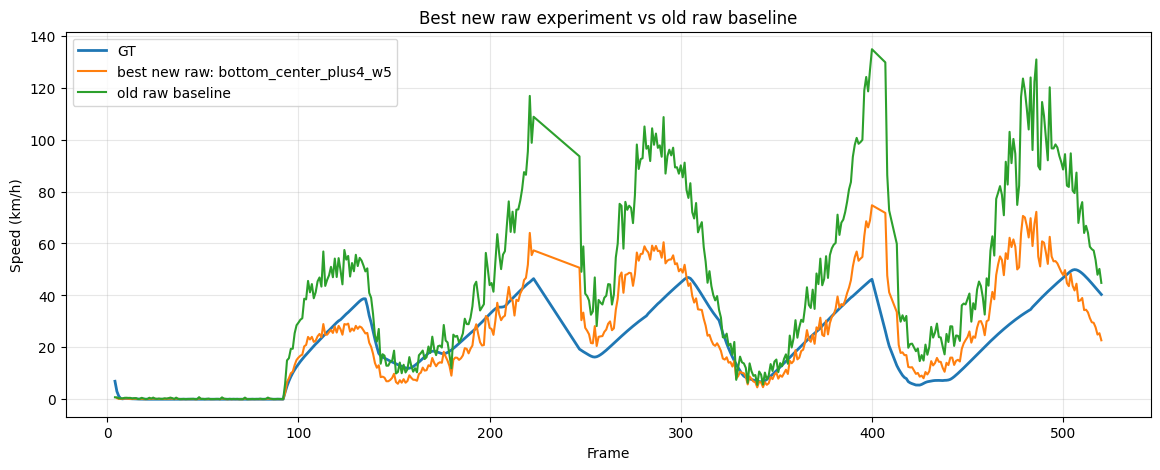

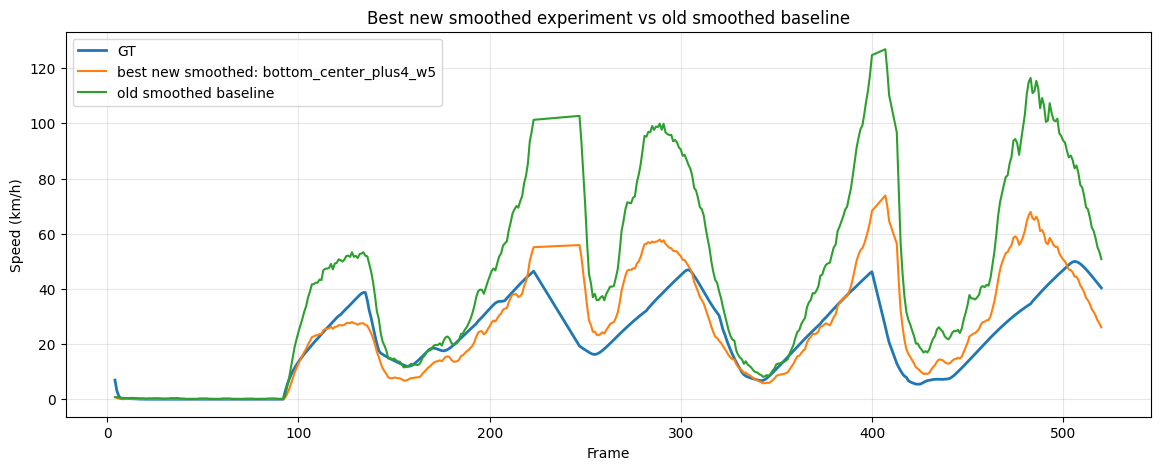


=== Headline Verdict ===
Best RAW experiment:
experiment           bottom_center_plus4_w5
mae                                7.312165
rmse                              11.024999
bias                               3.101612
corr                               0.846148
old_mae                            20.89417
old_rmse                          30.642866
old_bias                          20.636972
old_corr                           0.870005
delta_mae_vs_old                 -13.582006
delta_rmse_vs_old                -19.617867
delta_corr_vs_old                 -0.023857
Name: 0, dtype: object

Best SMOOTHED experiment:
experiment           bottom_center_plus4_w5
mae                                7.002395
rmse                              10.818123
bias                               3.002062
corr                               0.847892
old_mae                           20.533845
old_rmse                          30.149496
old_bias                          20.442115
old_corr               

In [10]:
# ============================================================
# Cell 10: Raw-estimation experiment grid
# Goal:
# - compare raw / smoothed speed quality only
# - do NOT optimize on affine correction yet
# - identify whether any upstream variant beats old notebook raw/smoothed
# ============================================================

import numpy as np
import pandas as pd
import cv2
import inspect
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

assert "DETECTOR" in globals(), "Run Cell 2 first."
assert SUPERVISION_OK, "supervision is required."
assert GEOMETRY_MODE == "vehicle_homography", "Cell 10 currently expects vehicle_homography."

# ------------------------------------------------------------
# 1) Load old notebook baseline numbers for comparison
# ------------------------------------------------------------
OLD_OBS_CSV_PATH = PHASE_ROOT / "rfdetr" / "videos" / "personal_simulation" / "final_best_pipeline_observations.csv"
assert OLD_OBS_CSV_PATH.exists(), f"Old notebook observations CSV not found: {OLD_OBS_CSV_PATH}"

old_obs_df = pd.read_csv(OLD_OBS_CSV_PATH)
gt_df = load_gt_csv(GT_CSV_PATH)

old_track_counts = old_obs_df["track_id"].value_counts().sort_values(ascending=False)
assert len(old_track_counts) > 0, "No track_id values found in old observations CSV."

old_dominant_track_id = int(old_track_counts.index[0])
old_eval_df = (
    old_obs_df[old_obs_df["track_id"] == old_dominant_track_id]
    .sort_values("frame_idx")
    .reset_index(drop=True)
)

old_compare_df = gt_df.merge(
    old_eval_df[[
        "frame_idx",
        "raw_speed_kmh",
        "smoothed_speed_kmh",
    ]],
    on="frame_idx",
    how="inner"
)

old_raw_metrics = compute_metrics(old_compare_df["gt_speed_kmh"], old_compare_df["raw_speed_kmh"])
old_smooth_metrics = compute_metrics(old_compare_df["gt_speed_kmh"], old_compare_df["smoothed_speed_kmh"])

print("=== Old Notebook Baseline to Beat ===")
print("Old raw     :", old_raw_metrics)
print("Old smoothed:", old_smooth_metrics)
print("=====================================")

# ------------------------------------------------------------
# 2) Helpers for experiment runner
# ------------------------------------------------------------
def make_tracker_with_current_settings(frame_rate):
    sig = inspect.signature(sv.ByteTrack.__init__)
    params = set(sig.parameters.keys())
    kwargs = {}

    if "track_activation_threshold" in params:
        kwargs["track_activation_threshold"] = TRACK_THRESH
    if "lost_track_buffer" in params:
        kwargs["lost_track_buffer"] = TRACK_BUFFER
    if "minimum_matching_threshold" in params:
        kwargs["minimum_matching_threshold"] = MATCH_THRESH
    if "frame_rate" in params:
        kwargs["frame_rate"] = int(round(frame_rate))

    if "track_thresh" in params:
        kwargs["track_thresh"] = TRACK_THRESH
    if "track_buffer" in params:
        kwargs["track_buffer"] = TRACK_BUFFER
    if "match_thresh" in params:
        kwargs["match_thresh"] = MATCH_THRESH

    try:
        tracker = sv.ByteTrack(**kwargs)
    except TypeError:
        tracker = sv.ByteTrack()

    if hasattr(tracker, "reset"):
        tracker.reset()

    return tracker

def run_speed_pipeline_experiment(
    experiment_name,
    rep_point_mode="bottom_center",
    rep_y_offset_px=0.0,
    speed_window=5,
    use_border_filter=True,
    min_box_area=MIN_BOX_AREA,
):
    """
    Runs one end-to-end experiment and returns:
      - obs_df
      - compare_df
      - metrics rows
    """
    cap = cv2.VideoCapture(str(VIDEO_PATH))
    assert cap.isOpened(), f"Could not open video: {VIDEO_PATH}"

    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps is None or fps <= 1:
        fps = DEFAULT_FPS

    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    tracker = make_tracker_with_current_settings(frame_rate=fps)

    track_histories = {}
    track_meta = {}
    output_rows = []

    temp_infer_path = OUTPUT_DIR / f"_temp_{experiment_name}.jpg"

    pbar = tqdm(total=total_frames, desc=f"Experiment: {experiment_name}", leave=False)

    for frame_idx in range(total_frames):
        ok, frame_bgr = cap.read()
        if not ok:
            break

        if frame_idx % DETECT_EVERY_N == 0:
            ok_write = cv2.imwrite(str(temp_infer_path), frame_bgr)
            assert ok_write, f"Failed to write temp inference image: {temp_infer_path}"

            det = DETECTOR.predict(str(temp_infer_path), threshold=DET_THRESHOLD)
            detections = rfdetr_to_sv_detections(det, min_conf=DET_THRESHOLD)

            if len(detections) > 0:
                xyxy = detections.xyxy
                areas = (xyxy[:, 2] - xyxy[:, 0]) * (xyxy[:, 3] - xyxy[:, 1])
                keep = areas >= min_box_area
                detections = detections[keep]

            # Single update path only
            det_with_ids = tracker.update_with_detections(detections)

            if len(det_with_ids) > 0 and getattr(det_with_ids, "tracker_id", None) is not None:
                for i in range(len(det_with_ids)):
                    tid = int(det_with_ids.tracker_id[i])
                    cls = int(det_with_ids.class_id[i])
                    conf = float(det_with_ids.confidence[i])
                    track_meta[tid] = (cls, conf)

        else:
            _ = tracker.update_with_detections(
                sv.Detections(
                    xyxy=np.zeros((0, 4), dtype=np.float32),
                    confidence=np.zeros((0,), dtype=np.float32),
                    class_id=np.zeros((0,), dtype=np.int32),
                )
            )

        boxes, ids = active_tracks_to_boxes_and_ids(tracker)

        for box, tid in zip(boxes, ids):
            cls, conf = track_meta.get(tid, (-1, 0.0))
            if cls not in SPEED_ESTIMATION_CLASS_IDS:
                continue

            if use_border_filter:
                touches_border = bbox_touches_border(
                    box,
                    image_width=width,
                    image_height=height,
                    margin_px=BORDER_MARGIN_PX
                )
                if touches_border:
                    continue

            hist = get_or_create_track_history(
                track_histories,
                tid,
                speed_window=speed_window
            )

            append_track_observation(
                track_history=hist,
                frame_idx=frame_idx,
                box_xyxy=box,
                class_id=cls,
                confidence=conf,
                fps=fps,
                geometry=GEOMETRY,
                rep_point_mode=rep_point_mode,
                rep_y_offset_px=rep_y_offset_px,
            )

            raw_speed = hist["raw_speeds_kmh"][-1]
            smooth_speed = hist["smoothed_speeds_kmh"][-1]
            world_pt = hist["world_points"][-1]
            rep_pt = hist["image_points"][-1]

            output_rows.append({
                "experiment": experiment_name,
                "track_id": int(tid),
                "frame_idx": int(frame_idx),
                "class_id": int(cls),
                "confidence": float(conf),
                "bbox_x1": float(box[0]),
                "bbox_y1": float(box[1]),
                "bbox_x2": float(box[2]),
                "bbox_y2": float(box[3]),
                "rep_image_x": float(rep_pt[0]),
                "rep_image_y": float(rep_pt[1]),
                "world_x": float(world_pt[0]),
                "world_y": float(world_pt[1]),
                "raw_speed_kmh": raw_speed,
                "smoothed_speed_kmh": smooth_speed,
            })

        pbar.update(1)

    pbar.close()
    cap.release()

    if temp_infer_path.exists():
        try:
            temp_infer_path.unlink()
        except Exception:
            pass

    obs_df = pd.DataFrame(output_rows)
    assert len(obs_df) > 0, f"No observations collected for experiment: {experiment_name}"

    track_counts = obs_df["track_id"].value_counts().sort_values(ascending=False)
    dominant_track_id = int(track_counts.index[0])

    eval_df = (
        obs_df[obs_df["track_id"] == dominant_track_id]
        .sort_values("frame_idx")
        .reset_index(drop=True)
    )

    compare_df = gt_df.merge(
        eval_df[[
            "frame_idx",
            "raw_speed_kmh",
            "smoothed_speed_kmh",
        ]],
        on="frame_idx",
        how="inner"
    )

    raw_metrics = compute_metrics(compare_df["gt_speed_kmh"], compare_df["raw_speed_kmh"])
    smooth_metrics = compute_metrics(compare_df["gt_speed_kmh"], compare_df["smoothed_speed_kmh"])

    metrics_rows = [
        {
            "experiment": experiment_name,
            "series": "raw_speed_kmh",
            "dominant_track_id": dominant_track_id,
            "rep_point_mode": rep_point_mode,
            "rep_y_offset_px": rep_y_offset_px,
            "speed_window": speed_window,
            "use_border_filter": use_border_filter,
            **raw_metrics
        },
        {
            "experiment": experiment_name,
            "series": "smoothed_speed_kmh",
            "dominant_track_id": dominant_track_id,
            "rep_point_mode": rep_point_mode,
            "rep_y_offset_px": rep_y_offset_px,
            "speed_window": speed_window,
            "use_border_filter": use_border_filter,
            **smooth_metrics
        }
    ]

    return obs_df, compare_df, metrics_rows

# ------------------------------------------------------------
# 3) Experiment grid
# Keep this tight and physically reasonable
# ------------------------------------------------------------
EXPERIMENTS = [
    {
        "experiment_name": "bottom_center_w5",
        "rep_point_mode": "bottom_center",
        "rep_y_offset_px": 0.0,
        "speed_window": 5,
        "use_border_filter": True,
    },
    {
        "experiment_name": "bottom_center_plus2_w5",
        "rep_point_mode": "bottom_center",
        "rep_y_offset_px": 2.0,
        "speed_window": 5,
        "use_border_filter": True,
    },
    {
        "experiment_name": "bottom_center_plus4_w5",
        "rep_point_mode": "bottom_center",
        "rep_y_offset_px": 4.0,
        "speed_window": 5,
        "use_border_filter": True,
    },
    {
        "experiment_name": "center_w5",
        "rep_point_mode": "center",
        "rep_y_offset_px": 0.0,
        "speed_window": 5,
        "use_border_filter": True,
    },
    {
        "experiment_name": "bottom_center_w3",
        "rep_point_mode": "bottom_center",
        "rep_y_offset_px": 0.0,
        "speed_window": 3,
        "use_border_filter": True,
    },
    {
        "experiment_name": "bottom_center_w7",
        "rep_point_mode": "bottom_center",
        "rep_y_offset_px": 0.0,
        "speed_window": 7,
        "use_border_filter": True,
    },
]

# ------------------------------------------------------------
# 4) Run experiments
# ------------------------------------------------------------
all_obs = {}
all_compare = {}
all_metric_rows = []

for exp_cfg in EXPERIMENTS:
    obs_df_exp, compare_df_exp, metric_rows_exp = run_speed_pipeline_experiment(**exp_cfg)
    all_obs[exp_cfg["experiment_name"]] = obs_df_exp
    all_compare[exp_cfg["experiment_name"]] = compare_df_exp
    all_metric_rows.extend(metric_rows_exp)

experiment_metrics_df = pd.DataFrame(all_metric_rows)

# ------------------------------------------------------------
# 5) Add old-baseline deltas
# We care most about raw first, then smoothed
# ------------------------------------------------------------
def get_old_metric_for_series(series, metric_name):
    if series == "raw_speed_kmh":
        return old_raw_metrics[metric_name]
    elif series == "smoothed_speed_kmh":
        return old_smooth_metrics[metric_name]
    else:
        return np.nan

experiment_metrics_df["old_mae"] = experiment_metrics_df["series"].apply(lambda s: get_old_metric_for_series(s, "mae"))
experiment_metrics_df["old_rmse"] = experiment_metrics_df["series"].apply(lambda s: get_old_metric_for_series(s, "rmse"))
experiment_metrics_df["old_bias"] = experiment_metrics_df["series"].apply(lambda s: get_old_metric_for_series(s, "bias"))
experiment_metrics_df["old_corr"] = experiment_metrics_df["series"].apply(lambda s: get_old_metric_for_series(s, "corr"))

experiment_metrics_df["delta_mae_vs_old"] = experiment_metrics_df["mae"] - experiment_metrics_df["old_mae"]
experiment_metrics_df["delta_rmse_vs_old"] = experiment_metrics_df["rmse"] - experiment_metrics_df["old_rmse"]
experiment_metrics_df["delta_bias_vs_old"] = experiment_metrics_df["bias"] - experiment_metrics_df["old_bias"]
experiment_metrics_df["delta_corr_vs_old"] = experiment_metrics_df["corr"] - experiment_metrics_df["old_corr"]

# ------------------------------------------------------------
# 6) Ranked summaries
# ------------------------------------------------------------
raw_rank_df = (
    experiment_metrics_df[experiment_metrics_df["series"] == "raw_speed_kmh"]
    .sort_values(["rmse", "mae", "corr"], ascending=[True, True, False])
    .reset_index(drop=True)
)

smooth_rank_df = (
    experiment_metrics_df[experiment_metrics_df["series"] == "smoothed_speed_kmh"]
    .sort_values(["rmse", "mae", "corr"], ascending=[True, True, False])
    .reset_index(drop=True)
)

print("\n=== Raw-speed experiments ranked ===")
display(raw_rank_df)

print("\n=== Smoothed-speed experiments ranked ===")
display(smooth_rank_df)

best_raw_exp = raw_rank_df.iloc[0]["experiment"]
best_smooth_exp = smooth_rank_df.iloc[0]["experiment"]

print("\nBest raw experiment     :", best_raw_exp)
print("Best smoothed experiment:", best_smooth_exp)

# ------------------------------------------------------------
# 7) Plot best raw experiment vs old raw baseline
# ------------------------------------------------------------
best_raw_compare_df = all_compare[best_raw_exp].copy()

old_raw_plot_df = old_compare_df[["frame_idx", "gt_speed_kmh", "raw_speed_kmh"]].rename(
    columns={"raw_speed_kmh": "old_raw_speed_kmh"}
)

best_raw_plot_df = best_raw_compare_df[["frame_idx", "gt_speed_kmh", "raw_speed_kmh"]].rename(
    columns={"raw_speed_kmh": "best_new_raw_speed_kmh"}
)

merged_raw_plot_df = best_raw_plot_df.merge(
    old_raw_plot_df[["frame_idx", "old_raw_speed_kmh"]],
    on="frame_idx",
    how="inner"
)

plt.figure(figsize=(14, 5))
plt.plot(merged_raw_plot_df["frame_idx"], merged_raw_plot_df["gt_speed_kmh"], label="GT", linewidth=2)
plt.plot(merged_raw_plot_df["frame_idx"], merged_raw_plot_df["best_new_raw_speed_kmh"], label=f"best new raw: {best_raw_exp}")
plt.plot(merged_raw_plot_df["frame_idx"], merged_raw_plot_df["old_raw_speed_kmh"], label="old raw baseline")
plt.title("Best new raw experiment vs old raw baseline")
plt.xlabel("Frame")
plt.ylabel("Speed (km/h)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# ------------------------------------------------------------
# 8) Plot best smoothed experiment vs old smoothed baseline
# ------------------------------------------------------------
best_smooth_compare_df = all_compare[best_smooth_exp].copy()

old_smooth_plot_df = old_compare_df[["frame_idx", "gt_speed_kmh", "smoothed_speed_kmh"]].rename(
    columns={"smoothed_speed_kmh": "old_smoothed_speed_kmh"}
)

best_smooth_plot_df = best_smooth_compare_df[["frame_idx", "gt_speed_kmh", "smoothed_speed_kmh"]].rename(
    columns={"smoothed_speed_kmh": "best_new_smoothed_speed_kmh"}
)

merged_smooth_plot_df = best_smooth_plot_df.merge(
    old_smooth_plot_df[["frame_idx", "old_smoothed_speed_kmh"]],
    on="frame_idx",
    how="inner"
)

plt.figure(figsize=(14, 5))
plt.plot(merged_smooth_plot_df["frame_idx"], merged_smooth_plot_df["gt_speed_kmh"], label="GT", linewidth=2)
plt.plot(merged_smooth_plot_df["frame_idx"], merged_smooth_plot_df["best_new_smoothed_speed_kmh"], label=f"best new smoothed: {best_smooth_exp}")
plt.plot(merged_smooth_plot_df["frame_idx"], merged_smooth_plot_df["old_smoothed_speed_kmh"], label="old smoothed baseline")
plt.title("Best new smoothed experiment vs old smoothed baseline")
plt.xlabel("Frame")
plt.ylabel("Speed (km/h)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# ------------------------------------------------------------
# 9) Headline verdict
# ------------------------------------------------------------
best_raw_row = raw_rank_df.iloc[0]
best_smooth_row = smooth_rank_df.iloc[0]

print("\n=== Headline Verdict ===")
print("Best RAW experiment:")
print(best_raw_row[[
    "experiment", "mae", "rmse", "bias", "corr",
    "old_mae", "old_rmse", "old_bias", "old_corr",
    "delta_mae_vs_old", "delta_rmse_vs_old", "delta_corr_vs_old"
]])

print("\nBest SMOOTHED experiment:")
print(best_smooth_row[[
    "experiment", "mae", "rmse", "bias", "corr",
    "old_mae", "old_rmse", "old_bias", "old_corr",
    "delta_mae_vs_old", "delta_rmse_vs_old", "delta_corr_vs_old"
]])
print("========================")

# Results so far: new speed estimator is clearly better than the old notebook

We now have a reliable comparison between:

- the **old notebook final pipeline observations**
- the **new notebook baseline / experiment runs**
- the same simulation video
- the same GT CSV (`carla_rgb_speeds.csv`)

## What we observed

### Old notebook upstream behavior
The old notebook's raw and smoothed speed estimates were very large relative to ground truth:

- **Old raw**
  - MAE ≈ **20.89**
  - RMSE ≈ **30.64**
  - Bias ≈ **+20.64**
  - Corr ≈ **0.870**

- **Old smoothed**
  - MAE ≈ **20.53**
  - RMSE ≈ **30.15**
  - Bias ≈ **+20.44**
  - Corr ≈ **0.872**

This matches the old notebook plots where raw/smoothed predictions often rose far above the ground truth and reached very high peaks.

### New notebook upstream behavior
The new notebook's best raw/smoothed candidates are much closer to GT:

- **Best new raw**
  - experiment: `bottom_center_plus4_w5`
  - MAE ≈ **7.31**
  - RMSE ≈ **11.02**
  - Bias ≈ **+3.10**
  - Corr ≈ **0.846**

- **Best new smoothed**
  - experiment: `bottom_center_plus4_w5`
  - MAE ≈ **7.00**
  - RMSE ≈ **10.82**
  - Bias ≈ **+3.00**
  - Corr ≈ **0.848**

## Why the new notebook has better raw estimations

The new notebook is producing better upstream estimates mainly because the **geometry stage is much less over-scaled** than before.

### 1. Lower systematic bias
The old notebook had a very large positive bias:
- old raw bias ≈ **+20.64 km/h**
- old smoothed bias ≈ **+20.44 km/h**

The new notebook reduced that drastically:
- new raw bias ≈ **+3.10 km/h**
- new smoothed bias ≈ **+3.00 km/h**

So even before affine correction, the new pipeline is already much closer in magnitude to the ground truth.

### 2. Better representative-point behavior
The new notebook is using a cleaner and more controlled representative-point setup, and the sweep so far suggests that using the **bottom-center with a small positive vertical offset** works best.

That means the point being projected into world space is likely a better proxy for where the vehicle touches the ground plane.

### 3. Better upstream calibration quality
The current homography / projection pipeline is still imperfect, but it is clearly producing a **less exaggerated world-motion estimate** than the old notebook. That is why the raw and smoothed curves are much more realistic in amplitude.

=== Old Notebook Baseline ===
Old raw     : {'count': 485, 'mae': 20.89417027763185, 'rmse': 30.642866167190785, 'bias': 20.636971977286194, 'corr': 0.87000476194718}
Old smoothed: {'count': 485, 'mae': 20.533845383947817, 'rmse': 30.149496195538287, 'bias': 20.442114699859598, 'corr': 0.8715656724407124}
Local refinement experiments: 15


Experiment: bc_plus0_w3:   0%|          | 0/521 [00:00<?, ?it/s]

Experiment: bc_plus0_w5:   0%|          | 0/521 [00:00<?, ?it/s]

Experiment: bc_plus0_w7:   0%|          | 0/521 [00:00<?, ?it/s]

Experiment: bc_plus2_w3:   0%|          | 0/521 [00:00<?, ?it/s]

...

,experiment,series,dominant_track_id,rep_point_mode,rep_y_offset_px,speed_window,use_border_filter,count,mae,rmse,bias,corr,old_mae,old_rmse,old_bias,old_corr,delta_mae_vs_old,delta_rmse_vs_old,delta_bias_vs_old,delta_corr_vs_old
0,bc_plus8_w5,smoothed_speed_kmh,1,bottom_center,8.0,5,True,485,7.009462,10.816655,3.003827,0.847553,20.533845,30.149496,20.442115,0.871566,-13.524383,-19.332841,-17.438288,-0.024012
1,bc_plus6_w5,smoothed_speed_kmh,1,bottom_center,6.0,5,True,485,7.005912,10.817321,3.002881,0.847723,20.533845,30.149496,20.442115,0.871566,-13.527933,-19.332175,-17.439234,-0.023842
2,bc_plus4_w5,smoothed_speed_kmh,1,bottom_center,4.0,5,True,485,7.002395,10.818123,3.002062,0.847892,20.533845,30.149496,20.442115,0.871566,-13.531451,-19.331374,-17.440052,-0.023674
3,bc_plus2_w5,smoothed_speed_kmh,1,bottom_center,2.0,5,True,485,6.998910,10.819057,3.001369,0.848060,20.533845,30.149496,20.442115,0.871566,-13.534935,-19.330439,-17.440745,-0.023506
4,bc_plus0_w5,smoothed_speed_kmh,1,bottom_center,0.0,5,True,485,6.995457,10.820124,3.000802,0.848227,20.533845,30.149496,20.442115,0.871566,-13.538388,-19.329373,-17.441313,-0.023338
5,bc_plus8_w7,smoothed_speed_kmh,1,bottom_center,8.0,7,True,485,6.978864,10.822297,2.947782,0.844625,20.533845,30.149496,20.442115,0.871566,-13.554982,-19.327199,-17.494332,-0.026941
6,bc_plus6_w7,smoothed_speed_kmh,1,bottom_center,6.0,7,True,485,6.974812,10.822701,2.946814,0.844796,20.533845,30.149496,20.442115,0.871566,-13.559034,-19.326795,-17.495300,-0.026769
7,bc_plus4_w7,smoothed_speed_kmh,1,bottom_center,4.0,7,True,485,6.970802,10.823237,2.945973,0.844967,20.533845,30.149496,20.442115,0.871566,-13.563044,-19.326259,-17.496142,-0.026598
8,bc_plus2_w7,smoothed_speed_kmh,1,bottom_center,2.0,7,True,485,6.966819,10.823904,2.945257,0.845137,20.533845,30.149496,20.442115,0.871566,-13.567026,-19.325592,-17.496858,-0.026428
9,bc_plus0_w7,smoothed_speed_kmh,1,bottom_center,0.0,7,True,485,6.962948,10.824701,2.944665,0.845307,20.533845,30.149496,20.442115,0.871566,-13.570897,-19.324795,-17.497450,-0.026259



Best local raw experiment     : bc_plus8_w3
Best local smoothed experiment: bc_plus8_w5

=== Raw RMSE pivot (rows=offset px, cols=window) ===


window,3,5,7
offset_px,,,
0,11.028200,11.028200,11.028200
2,11.026532,11.026532,11.026532
4,11.024999,11.024999,11.024999
6,11.023601,11.023601,11.023601
8,11.022339,11.022339,11.022339



=== Smoothed RMSE pivot (rows=offset px, cols=window) ===


window,3,5,7
offset_px,,,
0,10.852601,10.820124,10.824701
2,10.851242,10.819057,10.823904
4,10.850016,10.818123,10.823237
6,10.848926,10.817321,10.822701
8,10.847971,10.816655,10.822297


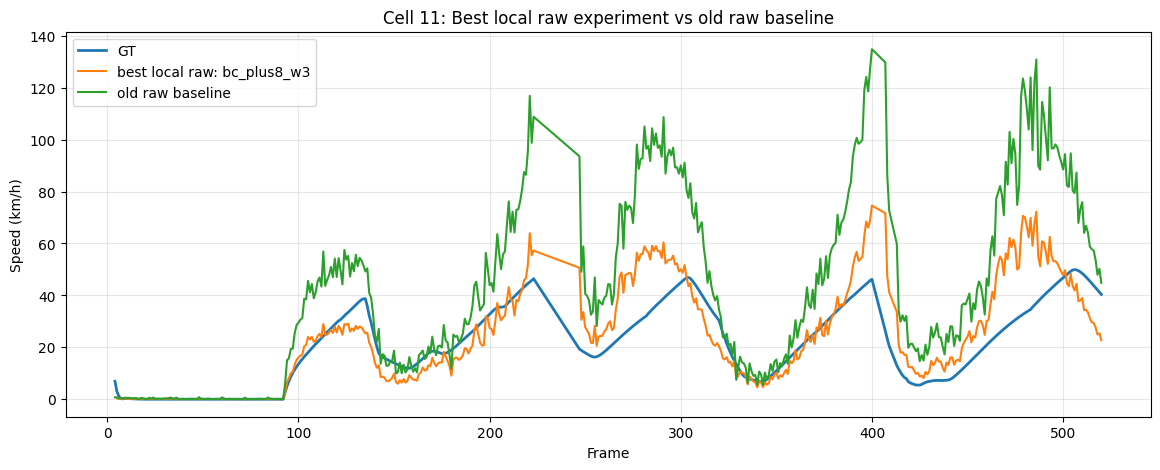

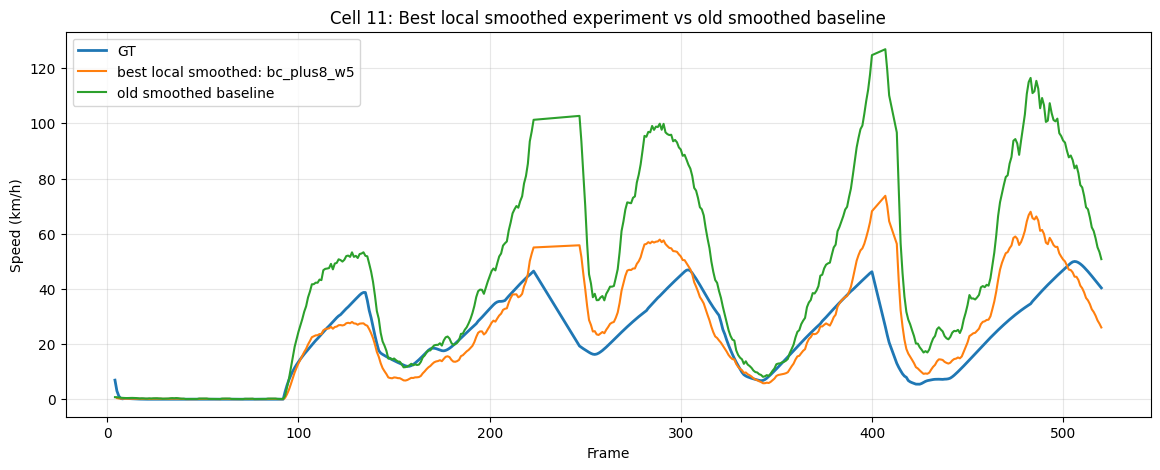


=== Saved upstream winners ===


,role,experiment,mae,rmse,bias,corr
0,best_raw,bc_plus8_w3,7.316032,11.022339,3.103325,0.845823
1,best_smoothed,bc_plus8_w5,7.009462,10.816655,3.003827,0.847553


In [12]:
# ============================================================
# Cell 11: Local refinement around the current winner
# Goal:
# - refine the best representative-point offset and smoothing window
# - keep focus on raw/smoothed only
# - choose the final upstream candidate before affine fitting
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

assert "DETECTOR" in globals(), "Run Cell 2 first."
assert SUPERVISION_OK, "supervision is required."
assert GEOMETRY_MODE == "vehicle_homography", "Cell 11 currently expects vehicle_homography."

# ------------------------------------------------------------
# 1) Reuse old notebook baseline from Cell 10 logic
# ------------------------------------------------------------
OLD_OBS_CSV_PATH = PHASE_ROOT / "rfdetr" / "videos" / "personal_simulation" / "final_best_pipeline_observations.csv"
assert OLD_OBS_CSV_PATH.exists(), f"Old notebook observations CSV not found: {OLD_OBS_CSV_PATH}"

old_obs_df = pd.read_csv(OLD_OBS_CSV_PATH)
gt_df = load_gt_csv(GT_CSV_PATH)

old_track_counts = old_obs_df["track_id"].value_counts().sort_values(ascending=False)
assert len(old_track_counts) > 0, "No track_id values found in old observations CSV."
old_dominant_track_id = int(old_track_counts.index[0])

old_eval_df = (
    old_obs_df[old_obs_df["track_id"] == old_dominant_track_id]
    .sort_values("frame_idx")
    .reset_index(drop=True)
)

old_compare_df = gt_df.merge(
    old_eval_df[[
        "frame_idx",
        "raw_speed_kmh",
        "smoothed_speed_kmh",
    ]],
    on="frame_idx",
    how="inner"
)

old_raw_metrics = compute_metrics(old_compare_df["gt_speed_kmh"], old_compare_df["raw_speed_kmh"])
old_smooth_metrics = compute_metrics(old_compare_df["gt_speed_kmh"], old_compare_df["smoothed_speed_kmh"])

print("=== Old Notebook Baseline ===")
print("Old raw     :", old_raw_metrics)
print("Old smoothed:", old_smooth_metrics)
print("=============================")

# ------------------------------------------------------------
# 2) Local refinement grid around current winner
# Current winner from Cell 10:
#   bottom_center + 4 px, w=5
# ------------------------------------------------------------
LOCAL_REFINEMENT_EXPERIMENTS = []
for y_offset in [0.0, 2.0, 4.0, 6.0, 8.0]:
    for speed_window in [3, 5, 7]:
        LOCAL_REFINEMENT_EXPERIMENTS.append({
            "experiment_name": f"bc_plus{int(y_offset)}_w{speed_window}",
            "rep_point_mode": "bottom_center",
            "rep_y_offset_px": float(y_offset),
            "speed_window": int(speed_window),
            "use_border_filter": True,
        })

print("Local refinement experiments:", len(LOCAL_REFINEMENT_EXPERIMENTS))

# ------------------------------------------------------------
# 3) Run local refinement grid
# Reuses run_speed_pipeline_experiment from Cell 10
# ------------------------------------------------------------
local_all_obs = {}
local_all_compare = {}
local_metric_rows = []

for exp_cfg in LOCAL_REFINEMENT_EXPERIMENTS:
    obs_df_exp, compare_df_exp, metric_rows_exp = run_speed_pipeline_experiment(**exp_cfg)
    local_all_obs[exp_cfg["experiment_name"]] = obs_df_exp
    local_all_compare[exp_cfg["experiment_name"]] = compare_df_exp
    local_metric_rows.extend(metric_rows_exp)

local_metrics_df = pd.DataFrame(local_metric_rows)

# ------------------------------------------------------------
# 4) Add old-baseline deltas
# ------------------------------------------------------------
def get_old_metric_for_series_local(series, metric_name):
    if series == "raw_speed_kmh":
        return old_raw_metrics[metric_name]
    elif series == "smoothed_speed_kmh":
        return old_smooth_metrics[metric_name]
    else:
        return np.nan

local_metrics_df["old_mae"] = local_metrics_df["series"].apply(lambda s: get_old_metric_for_series_local(s, "mae"))
local_metrics_df["old_rmse"] = local_metrics_df["series"].apply(lambda s: get_old_metric_for_series_local(s, "rmse"))
local_metrics_df["old_bias"] = local_metrics_df["series"].apply(lambda s: get_old_metric_for_series_local(s, "bias"))
local_metrics_df["old_corr"] = local_metrics_df["series"].apply(lambda s: get_old_metric_for_series_local(s, "corr"))

local_metrics_df["delta_mae_vs_old"] = local_metrics_df["mae"] - local_metrics_df["old_mae"]
local_metrics_df["delta_rmse_vs_old"] = local_metrics_df["rmse"] - local_metrics_df["old_rmse"]
local_metrics_df["delta_bias_vs_old"] = local_metrics_df["bias"] - local_metrics_df["old_bias"]
local_metrics_df["delta_corr_vs_old"] = local_metrics_df["corr"] - local_metrics_df["old_corr"]

# ------------------------------------------------------------
# 5) Ranking tables
# ------------------------------------------------------------
local_raw_rank_df = (
    local_metrics_df[local_metrics_df["series"] == "raw_speed_kmh"]
    .sort_values(["rmse", "mae", "corr"], ascending=[True, True, False])
    .reset_index(drop=True)
)

local_smooth_rank_df = (
    local_metrics_df[local_metrics_df["series"] == "smoothed_speed_kmh"]
    .sort_values(["rmse", "mae", "corr"], ascending=[True, True, False])
    .reset_index(drop=True)
)

print("\n=== Local refinement: RAW ranked ===")
display(local_raw_rank_df)

print("\n=== Local refinement: SMOOTHED ranked ===")
display(local_smooth_rank_df)

best_local_raw_exp = local_raw_rank_df.iloc[0]["experiment"]
best_local_smooth_exp = local_smooth_rank_df.iloc[0]["experiment"]

print("\nBest local raw experiment     :", best_local_raw_exp)
print("Best local smoothed experiment:", best_local_smooth_exp)

# ------------------------------------------------------------
# 6) Pivot views to inspect offset/window trends
# ------------------------------------------------------------
def parse_exp_name(exp_name):
    # exp_name like: bc_plus4_w5
    offset_str = exp_name.split("_")[1].replace("plus", "")
    window_str = exp_name.split("_")[2].replace("w", "")
    return int(offset_str), int(window_str)

local_metrics_with_params_df = local_metrics_df.copy()
local_metrics_with_params_df[["offset_px", "window"]] = local_metrics_with_params_df["experiment"].apply(
    lambda x: pd.Series(parse_exp_name(x))
)

raw_rmse_pivot = (
    local_metrics_with_params_df[local_metrics_with_params_df["series"] == "raw_speed_kmh"]
    .pivot(index="offset_px", columns="window", values="rmse")
    .sort_index()
)

smooth_rmse_pivot = (
    local_metrics_with_params_df[local_metrics_with_params_df["series"] == "smoothed_speed_kmh"]
    .pivot(index="offset_px", columns="window", values="rmse")
    .sort_index()
)

print("\n=== Raw RMSE pivot (rows=offset px, cols=window) ===")
display(raw_rmse_pivot)

print("\n=== Smoothed RMSE pivot (rows=offset px, cols=window) ===")
display(smooth_rmse_pivot)

# ------------------------------------------------------------
# 7) Plot best local raw vs old raw
# ------------------------------------------------------------
best_local_raw_compare_df = local_all_compare[best_local_raw_exp].copy()

best_local_raw_plot_df = best_local_raw_compare_df[["frame_idx", "gt_speed_kmh", "raw_speed_kmh"]].rename(
    columns={"raw_speed_kmh": "best_local_raw_speed_kmh"}
)

old_raw_plot_df = old_compare_df[["frame_idx", "raw_speed_kmh"]].rename(
    columns={"raw_speed_kmh": "old_raw_speed_kmh"}
)

merged_local_raw_plot_df = best_local_raw_plot_df.merge(
    old_raw_plot_df,
    on="frame_idx",
    how="inner"
)

plt.figure(figsize=(14, 5))
plt.plot(merged_local_raw_plot_df["frame_idx"], merged_local_raw_plot_df["gt_speed_kmh"], label="GT", linewidth=2)
plt.plot(merged_local_raw_plot_df["frame_idx"], merged_local_raw_plot_df["best_local_raw_speed_kmh"], label=f"best local raw: {best_local_raw_exp}")
plt.plot(merged_local_raw_plot_df["frame_idx"], merged_local_raw_plot_df["old_raw_speed_kmh"], label="old raw baseline")
plt.title("Cell 11: Best local raw experiment vs old raw baseline")
plt.xlabel("Frame")
plt.ylabel("Speed (km/h)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# ------------------------------------------------------------
# 8) Plot best local smoothed vs old smoothed
# ------------------------------------------------------------
best_local_smooth_compare_df = local_all_compare[best_local_smooth_exp].copy()

best_local_smooth_plot_df = best_local_smooth_compare_df[["frame_idx", "gt_speed_kmh", "smoothed_speed_kmh"]].rename(
    columns={"smoothed_speed_kmh": "best_local_smoothed_speed_kmh"}
)

old_smooth_plot_df = old_compare_df[["frame_idx", "smoothed_speed_kmh"]].rename(
    columns={"smoothed_speed_kmh": "old_smoothed_speed_kmh"}
)

merged_local_smooth_plot_df = best_local_smooth_plot_df.merge(
    old_smooth_plot_df,
    on="frame_idx",
    how="inner"
)

plt.figure(figsize=(14, 5))
plt.plot(merged_local_smooth_plot_df["frame_idx"], merged_local_smooth_plot_df["gt_speed_kmh"], label="GT", linewidth=2)
plt.plot(merged_local_smooth_plot_df["frame_idx"], merged_local_smooth_plot_df["best_local_smoothed_speed_kmh"], label=f"best local smoothed: {best_local_smooth_exp}")
plt.plot(merged_local_smooth_plot_df["frame_idx"], merged_local_smooth_plot_df["old_smoothed_speed_kmh"], label="old smoothed baseline")
plt.title("Cell 11: Best local smoothed experiment vs old smoothed baseline")
plt.xlabel("Frame")
plt.ylabel("Speed (km/h)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# ------------------------------------------------------------
# 9) Save the selected upstream winners for later cells
# ------------------------------------------------------------
BEST_UPSTREAM_RAW_EXPERIMENT = best_local_raw_exp
BEST_UPSTREAM_SMOOTHED_EXPERIMENT = best_local_smooth_exp

BEST_UPSTREAM_RAW_COMPARE_DF = best_local_raw_compare_df.copy()
BEST_UPSTREAM_SMOOTHED_COMPARE_DF = best_local_smooth_compare_df.copy()

BEST_UPSTREAM_SELECTION_SUMMARY_DF = pd.DataFrame([
    {
        "role": "best_raw",
        "experiment": best_local_raw_exp,
        **local_raw_rank_df.iloc[0][["mae", "rmse", "bias", "corr"]].to_dict()
    },
    {
        "role": "best_smoothed",
        "experiment": best_local_smooth_exp,
        **local_smooth_rank_df.iloc[0][["mae", "rmse", "bias", "corr"]].to_dict()
    }
])

print("\n=== Saved upstream winners ===")
display(BEST_UPSTREAM_SELECTION_SUMMARY_DF)

Source experiment : bc_plus8_w5
Dominant track ID : 1
Trajectory rows   : 486
FPS               : 20.0

=== Pre-affine temporal-dynamics metrics ===


,series,count,mae,rmse,bias,corr
0,baseline_smoothed_speed_kmh,485,7.009462,10.816655,3.003827,0.847553
1,baseline_raw_speed_kmh,485,7.316032,11.022339,3.103325,0.845823
2,kalman_cv_speed_kmh,486,9.928650,14.886632,-0.878987,0.555907
3,central_diff_g1_speed_kmh,481,7.810213,14.948279,3.596958,0.752966
4,kalman_cv_ma5_speed_kmh,486,10.580938,15.377038,-1.042857,0.523134
5,central_diff_g2_speed_kmh,478,8.116452,15.533781,3.983159,0.755743
6,local_linear_w5_speed_kmh,478,8.129608,15.589513,3.993899,0.755050
7,central_diff_g1_ma5_speed_kmh,481,8.287308,17.508223,4.222190,0.705774
8,local_linear_w7_speed_kmh,477,8.985466,19.545972,4.929858,0.679822
9,central_diff_g2_ma5_speed_kmh,482,9.271855,21.566029,5.200041,0.627482


Best pre-affine dynamics series: baseline_smoothed_speed_kmh

=== Headline comparison ===
Current baseline smoothed:
mae      7.009462
rmse    10.816655
bias     3.003827
corr     0.847553
Name: 0, dtype: object

Best dynamics candidate:
series    baseline_smoothed_speed_kmh
mae                          7.009462
rmse                        10.816655
bias                         3.003827
corr                         0.847553
Name: 0, dtype: object


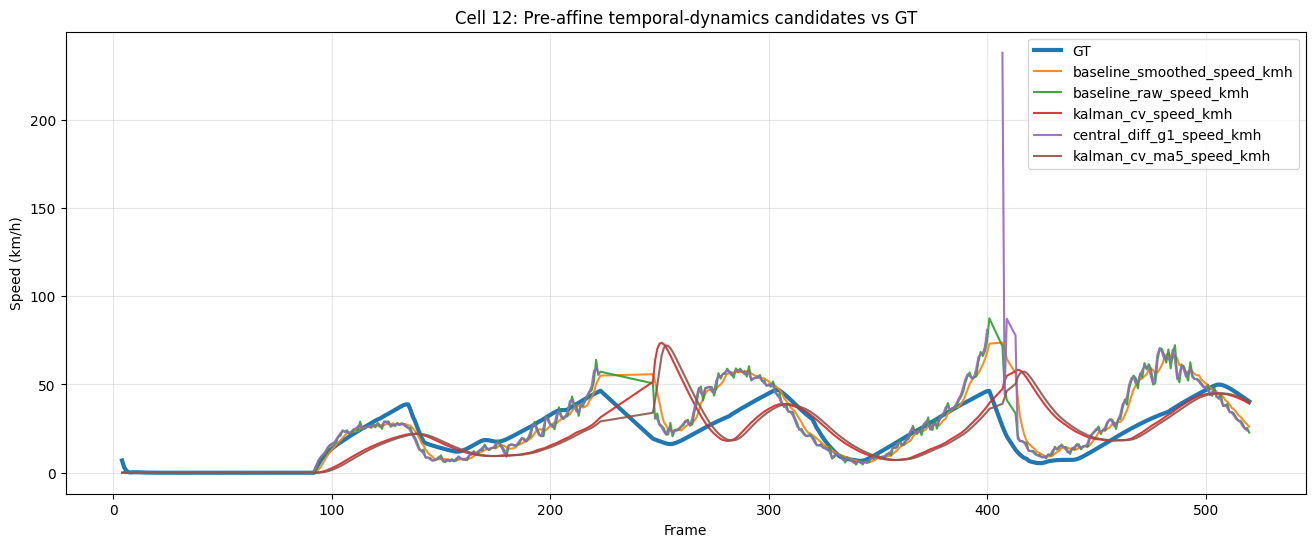

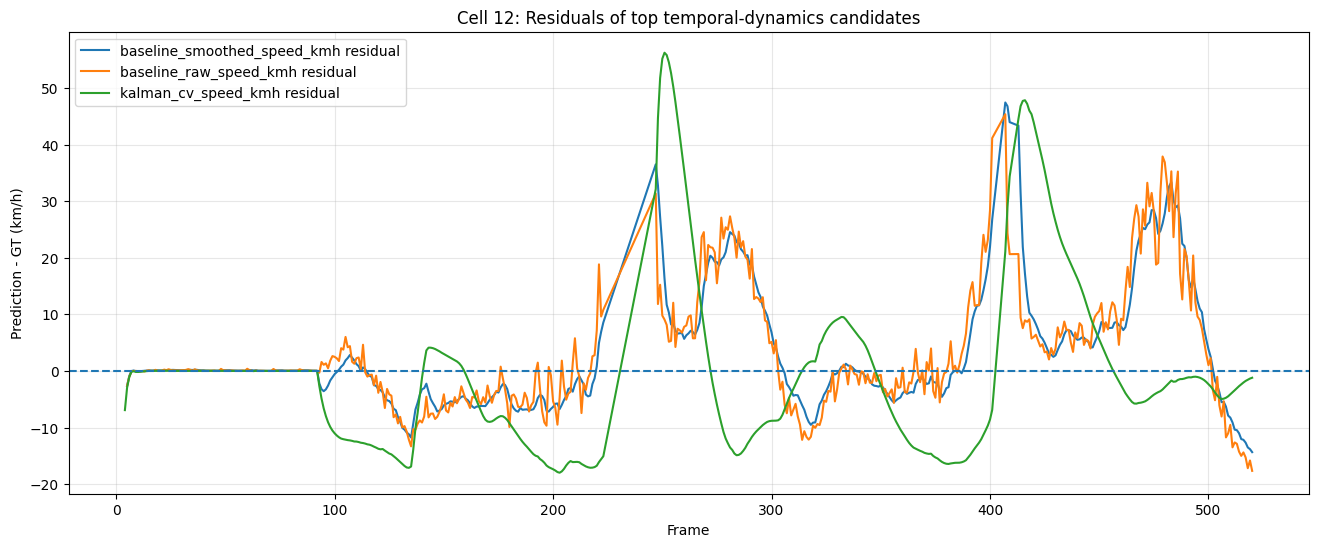


Saved for later cells:
BEST_PRE_AFFINE_DYNAMICS_SERIES = baseline_smoothed_speed_kmh


In [13]:
# ============================================================
# Cell 12: Pre-affine temporal-dynamics experiments
# Goal:
# - keep the winning upstream geometry (bottom-center + 8 px)
# - test alternative velocity-estimation / motion-dynamics methods
# - do NOT fit affine yet
# - compare shape and metrics against GT
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

assert "BEST_UPSTREAM_SMOOTHED_EXPERIMENT" in globals(), "Run Cell 11 first."
assert "local_all_obs" in globals(), "Cell 11 must have run successfully."
assert BEST_UPSTREAM_SMOOTHED_EXPERIMENT in local_all_obs, "Best smoothed experiment observations not found."

# ------------------------------------------------------------
# 1) Get the winning upstream observation track
# We'll use the best smoothed experiment as the source trajectory
# because it has the best current upstream performance.
# ------------------------------------------------------------
source_experiment = BEST_UPSTREAM_SMOOTHED_EXPERIMENT
source_obs_df = local_all_obs[source_experiment].copy()

track_counts = source_obs_df["track_id"].value_counts().sort_values(ascending=False)
assert len(track_counts) > 0, "No track IDs found in source observations."

dominant_track_id = int(track_counts.index[0])

traj_df = (
    source_obs_df[source_obs_df["track_id"] == dominant_track_id]
    .sort_values("frame_idx")
    .reset_index(drop=True)
)

assert len(traj_df) > 5, "Not enough trajectory points for temporal-dynamics experiments."

# Load GT and align later
gt_df = load_gt_csv(GT_CSV_PATH)

# Get FPS from video
cap = cv2.VideoCapture(str(VIDEO_PATH))
assert cap.isOpened(), f"Could not open video: {VIDEO_PATH}"
fps = cap.get(cv2.CAP_PROP_FPS)
cap.release()
if fps is None or fps <= 1:
    fps = DEFAULT_FPS

print("Source experiment :", source_experiment)
print("Dominant track ID :", dominant_track_id)
print("Trajectory rows   :", len(traj_df))
print("FPS               :", fps)

# ------------------------------------------------------------
# 2) Helpers: speed from world trajectory using different methods
# ------------------------------------------------------------
def speed_from_world_positions_adjacent(world_xy, fps):
    n = len(world_xy)
    out = [np.nan] * n
    for i in range(1, n):
        p1 = world_xy[i - 1]
        p2 = world_xy[i]
        dt = 1.0 / fps
        v = np.linalg.norm(p2 - p1) / dt * 3.6
        out[i] = float(v)
    return np.asarray(out, dtype=np.float64)

def speed_from_world_positions_central_difference(world_xy, fps, gap=1):
    n = len(world_xy)
    out = [np.nan] * n
    for i in range(gap, n - gap):
        p_prev = world_xy[i - gap]
        p_next = world_xy[i + gap]
        dt = (2 * gap) / fps
        v = np.linalg.norm(p_next - p_prev) / dt * 3.6
        out[i] = float(v)
    return np.asarray(out, dtype=np.float64)

def speed_from_world_positions_local_linear(world_xy, fps, window=5):
    """
    Fit x(t), y(t) with a local linear model over a centered window.
    Speed is ||[dx/dt, dy/dt]|| * 3.6
    """
    assert window % 2 == 1, "window must be odd"
    n = len(world_xy)
    half = window // 2
    out = [np.nan] * n

    for i in range(half, n - half):
        idx = np.arange(i - half, i + half + 1)
        t = (idx - i) / fps  # centered around current frame
        x = world_xy[idx, 0]
        y = world_xy[idx, 1]

        # degree-1 fit
        ax, bx = np.polyfit(t, x, 1)
        ay, by = np.polyfit(t, y, 1)

        speed_kmh = np.sqrt(ax**2 + ay**2) * 3.6
        out[i] = float(speed_kmh)

    return np.asarray(out, dtype=np.float64)

def speed_from_world_positions_kalman_cv(world_xy, fps):
    """
    Constant-velocity Kalman filter on 2D world positions.
    State: [x, y, vx, vy]
    Measurement: [x, y]
    Output speed = sqrt(vx^2 + vy^2) * 3.6
    """
    dt = 1.0 / fps
    n = len(world_xy)
    out = [np.nan] * n

    kf = cv2.KalmanFilter(4, 2)
    kf.transitionMatrix = np.array([
        [1, 0, dt, 0 ],
        [0, 1, 0,  dt],
        [0, 0, 1,  0 ],
        [0, 0, 0,  1 ],
    ], dtype=np.float32)

    kf.measurementMatrix = np.array([
        [1, 0, 0, 0],
        [0, 1, 0, 0],
    ], dtype=np.float32)

    # Mild default noise settings; can be tuned later if this branch is promising
    kf.processNoiseCov = np.eye(4, dtype=np.float32) * 1e-3
    kf.measurementNoiseCov = np.eye(2, dtype=np.float32) * 5e-3
    kf.errorCovPost = np.eye(4, dtype=np.float32)

    # initialize with first measurement
    first_x, first_y = world_xy[0]
    kf.statePost = np.array([[first_x], [first_y], [0.0], [0.0]], dtype=np.float32)

    for i in range(n):
        measurement = np.array([[world_xy[i, 0]], [world_xy[i, 1]]], dtype=np.float32)
        _ = kf.predict()
        est = kf.correct(measurement)

        vx = float(est[2, 0])
        vy = float(est[3, 0])
        speed_kmh = np.sqrt(vx**2 + vy**2) * 3.6
        out[i] = speed_kmh

    return np.asarray(out, dtype=np.float64)

def moving_average_nan(values, window=5):
    out = np.full(len(values), np.nan, dtype=np.float64)
    for i in range(len(values)):
        lo = max(0, i - window + 1)
        vals = values[lo:i+1]
        vals = vals[np.isfinite(vals)]
        if len(vals) > 0:
            out[i] = np.mean(vals)
    return out

# ------------------------------------------------------------
# 3) Build candidate series
# ------------------------------------------------------------
world_xy = traj_df[["world_x", "world_y"]].to_numpy(dtype=np.float64)

candidate_df = traj_df[["frame_idx"]].copy()
candidate_df["baseline_raw_speed_kmh"] = traj_df["raw_speed_kmh"].to_numpy(dtype=np.float64)
candidate_df["baseline_smoothed_speed_kmh"] = traj_df["smoothed_speed_kmh"].to_numpy(dtype=np.float64)

# Central differences
candidate_df["central_diff_g1_speed_kmh"] = speed_from_world_positions_central_difference(world_xy, fps=fps, gap=1)
candidate_df["central_diff_g2_speed_kmh"] = speed_from_world_positions_central_difference(world_xy, fps=fps, gap=2)

# Local linear fits
candidate_df["local_linear_w5_speed_kmh"] = speed_from_world_positions_local_linear(world_xy, fps=fps, window=5)
candidate_df["local_linear_w7_speed_kmh"] = speed_from_world_positions_local_linear(world_xy, fps=fps, window=7)

# Kalman CV
candidate_df["kalman_cv_speed_kmh"] = speed_from_world_positions_kalman_cv(world_xy, fps=fps)

# Light smoothing on the derived branches so we compare fairly
candidate_df["central_diff_g1_ma5_speed_kmh"] = moving_average_nan(candidate_df["central_diff_g1_speed_kmh"].to_numpy(), window=5)
candidate_df["central_diff_g2_ma5_speed_kmh"] = moving_average_nan(candidate_df["central_diff_g2_speed_kmh"].to_numpy(), window=5)
candidate_df["local_linear_w5_ma5_speed_kmh"] = moving_average_nan(candidate_df["local_linear_w5_speed_kmh"].to_numpy(), window=5)
candidate_df["local_linear_w7_ma5_speed_kmh"] = moving_average_nan(candidate_df["local_linear_w7_speed_kmh"].to_numpy(), window=5)
candidate_df["kalman_cv_ma5_speed_kmh"] = moving_average_nan(candidate_df["kalman_cv_speed_kmh"].to_numpy(), window=5)

# Reasonable-speed cleanup
for col in candidate_df.columns:
    if col.endswith("_speed_kmh") and col != "frame_idx":
        vals = candidate_df[col].to_numpy(dtype=np.float64)
        vals[(vals < MIN_REASONABLE_SPEED_KMH) | (vals > MAX_REASONABLE_SPEED_KMH)] = np.nan
        candidate_df[col] = vals

# ------------------------------------------------------------
# 4) Merge with GT
# ------------------------------------------------------------
compare_dyn_df = gt_df.merge(candidate_df, on="frame_idx", how="inner")
assert len(compare_dyn_df) > 0, "GT merge produced 0 rows."

# ------------------------------------------------------------
# 5) Metrics table
# ------------------------------------------------------------
candidate_cols = [
    "baseline_raw_speed_kmh",
    "baseline_smoothed_speed_kmh",
    "central_diff_g1_speed_kmh",
    "central_diff_g2_speed_kmh",
    "central_diff_g1_ma5_speed_kmh",
    "central_diff_g2_ma5_speed_kmh",
    "local_linear_w5_speed_kmh",
    "local_linear_w7_speed_kmh",
    "local_linear_w5_ma5_speed_kmh",
    "local_linear_w7_ma5_speed_kmh",
    "kalman_cv_speed_kmh",
    "kalman_cv_ma5_speed_kmh",
]

dyn_metric_rows = []
for col in candidate_cols:
    if col in compare_dyn_df.columns:
        metrics = compute_metrics(compare_dyn_df["gt_speed_kmh"], compare_dyn_df[col])
        dyn_metric_rows.append({
            "series": col,
            **metrics
        })

DYNAMICS_METRICS_DF = (
    pd.DataFrame(dyn_metric_rows)
    .sort_values(["rmse", "mae", "corr"], ascending=[True, True, False])
    .reset_index(drop=True)
)

print("\n=== Pre-affine temporal-dynamics metrics ===")
display(DYNAMICS_METRICS_DF)

best_dyn_series = DYNAMICS_METRICS_DF.iloc[0]["series"]
print("Best pre-affine dynamics series:", best_dyn_series)

# ------------------------------------------------------------
# 6) Compare against the current winning baseline smoothed branch
# ------------------------------------------------------------
baseline_smoothed_metrics = DYNAMICS_METRICS_DF[DYNAMICS_METRICS_DF["series"] == "baseline_smoothed_speed_kmh"].iloc[0]
best_dyn_metrics = DYNAMICS_METRICS_DF.iloc[0]

print("\n=== Headline comparison ===")
print("Current baseline smoothed:")
print(baseline_smoothed_metrics[["mae", "rmse", "bias", "corr"]])
print("\nBest dynamics candidate:")
print(best_dyn_metrics[["series", "mae", "rmse", "bias", "corr"]])

# ------------------------------------------------------------
# 7) Plot top candidates
# ------------------------------------------------------------
top_plot_cols = ["gt_speed_kmh"] + DYNAMICS_METRICS_DF["series"].head(5).tolist()

plt.figure(figsize=(16, 6))
plt.plot(compare_dyn_df["frame_idx"], compare_dyn_df["gt_speed_kmh"], label="GT", linewidth=3)

for col in DYNAMICS_METRICS_DF["series"].head(5):
    plt.plot(compare_dyn_df["frame_idx"], compare_dyn_df[col], label=col, alpha=0.9)

plt.xlabel("Frame")
plt.ylabel("Speed (km/h)")
plt.title("Cell 12: Pre-affine temporal-dynamics candidates vs GT")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# ------------------------------------------------------------
# 8) Residual plot for top 3
# ------------------------------------------------------------
plt.figure(figsize=(16, 6))
for col in DYNAMICS_METRICS_DF["series"].head(3):
    resid = compare_dyn_df[col] - compare_dyn_df["gt_speed_kmh"]
    plt.plot(compare_dyn_df["frame_idx"], resid, label=f"{col} residual")
plt.axhline(0.0, linestyle="--")
plt.xlabel("Frame")
plt.ylabel("Prediction - GT (km/h)")
plt.title("Cell 12: Residuals of top temporal-dynamics candidates")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# ------------------------------------------------------------
# 9) Save winner for later affine-fitting cells
# ------------------------------------------------------------
BEST_PRE_AFFINE_DYNAMICS_SERIES = best_dyn_series
BEST_PRE_AFFINE_DYNAMICS_COMPARE_DF = compare_dyn_df.copy()

print("\nSaved for later cells:")
print("BEST_PRE_AFFINE_DYNAMICS_SERIES =", BEST_PRE_AFFINE_DYNAMICS_SERIES)

Affine-fit candidate sources:
 - bc_plus8_w3::raw_speed_kmh
 - bc_plus8_w5::smoothed_speed_kmh
 - Cell12::baseline_smoothed_speed_kmh

=== Affine fit results ===


,source,kind,series,count,mae,rmse,bias,corr,affine_a,affine_b
0,bc_plus8_w5::smoothed_speed_kmh,affine_corrected,smoothed_speed_kmh__affine_corrected,485,6.627044,8.025815,-1.019665e-14,0.847553,0.660090,5.222492
1,Cell12::baseline_smoothed_speed_kmh,affine_corrected,baseline_smoothed_speed_kmh__affine_corrected,485,6.627044,8.025815,-1.019665e-14,0.847553,0.660090,5.222492
2,bc_plus8_w3::raw_speed_kmh,affine_corrected,raw_speed_kmh__affine_corrected,485,6.715144,8.067461,-6.328958e-15,0.845823,0.651595,5.363243
3,bc_plus8_w5::smoothed_speed_kmh,uncorrected,smoothed_speed_kmh,485,7.009462,10.816655,3.003827e+00,0.847553,NaN,NaN
4,Cell12::baseline_smoothed_speed_kmh,uncorrected,baseline_smoothed_speed_kmh,485,7.009462,10.816655,3.003827e+00,0.847553,NaN,NaN
5,bc_plus8_w3::raw_speed_kmh,uncorrected,raw_speed_kmh,485,7.316032,11.022339,3.103325e+00,0.845823,NaN,NaN



=== Best affine-corrected candidate ===
Source      : bc_plus8_w5::smoothed_speed_kmh
Pred column : smoothed_speed_kmh
Corrected   : smoothed_speed_kmh__affine_corrected
Affine a    : 0.6600896137382298
Affine b    : 5.2224924960805374


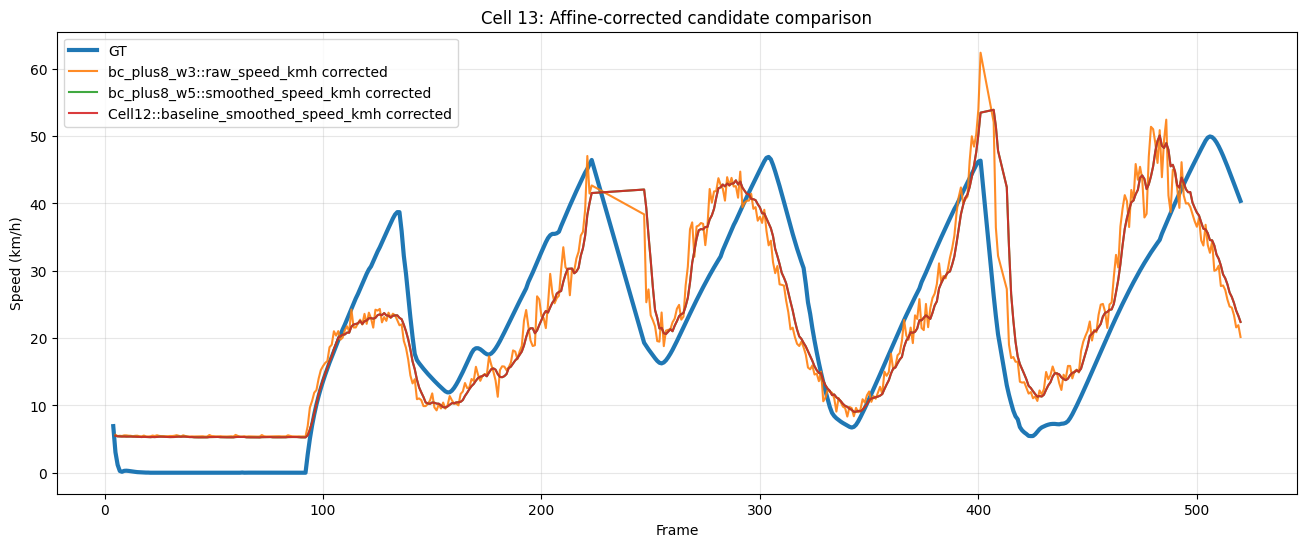

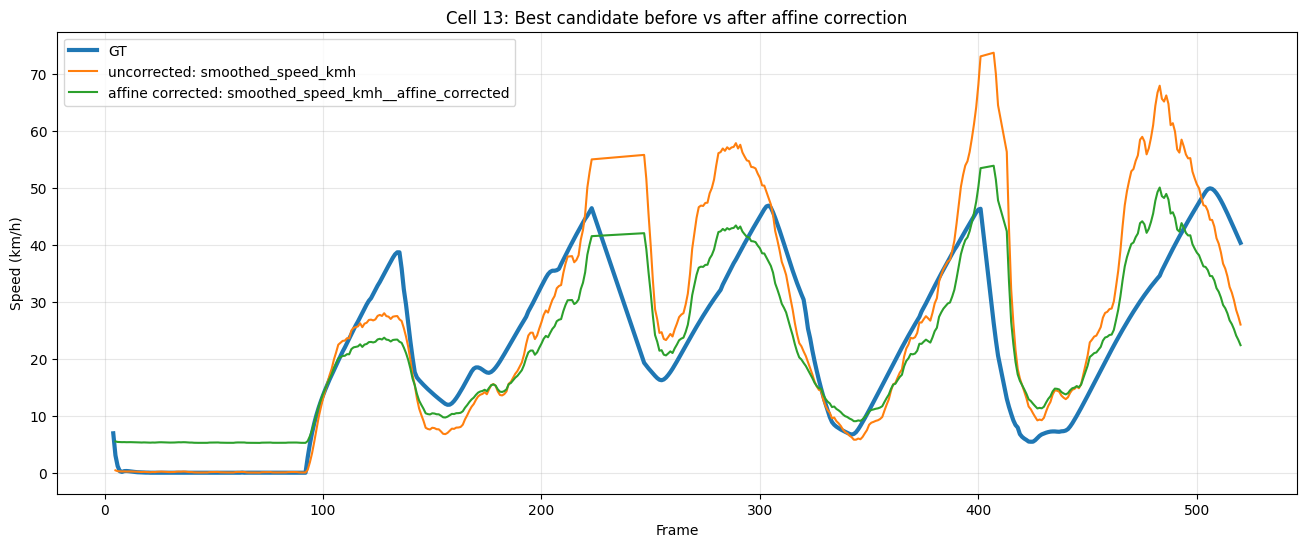

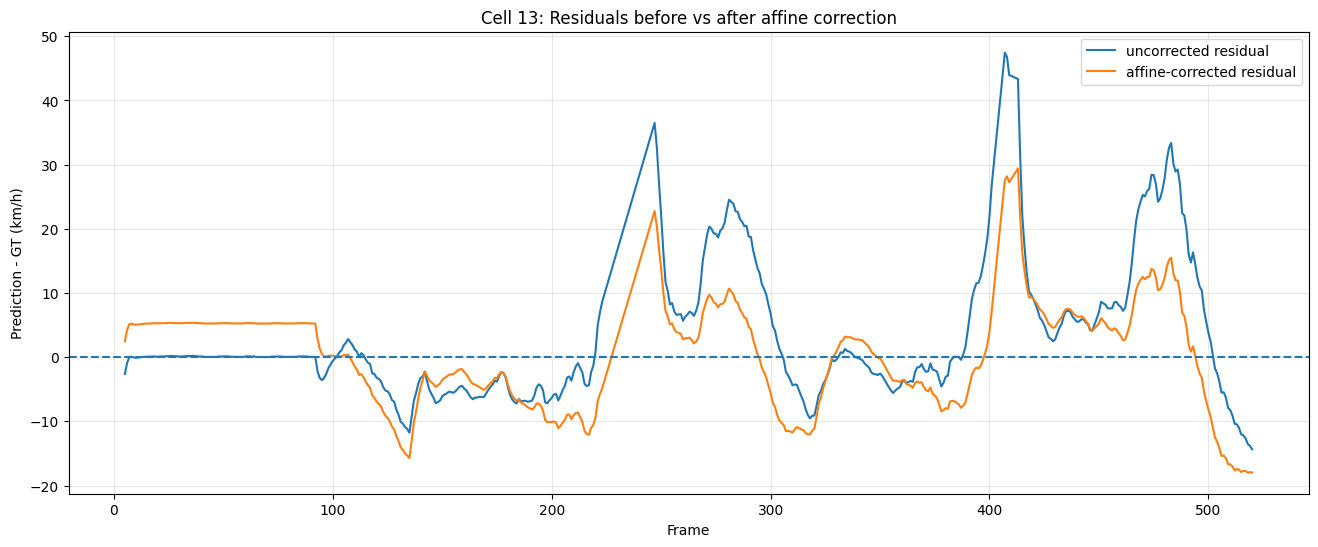


=== Saved best affine selection ===


,best_source,best_pred_col,best_corrected_col,affine_a,affine_b,mae,rmse,bias,corr
0,bc_plus8_w5::smoothed_speed_kmh,smoothed_speed_kmh,smoothed_speed_kmh__affine_corrected,0.66009,5.222492,6.627044,8.025815,-1.019665e-14,0.847553


In [14]:
# ============================================================
# Cell 13: Fit new affine coefficients on the winning upstream candidates
# Goal:
# - fit gt ≈ a * pred + b
# - compare affine fits for:
#     1) best raw upstream candidate
#     2) best smoothed upstream candidate
#     3) best pre-affine dynamics candidate
# - select the best corrected series for the final pipeline
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

assert "BEST_UPSTREAM_RAW_EXPERIMENT" in globals(), "Run Cell 11 first."
assert "BEST_UPSTREAM_SMOOTHED_EXPERIMENT" in globals(), "Run Cell 11 first."
assert "BEST_UPSTREAM_RAW_COMPARE_DF" in globals(), "Run Cell 11 first."
assert "BEST_UPSTREAM_SMOOTHED_COMPARE_DF" in globals(), "Run Cell 11 first."
assert "BEST_PRE_AFFINE_DYNAMICS_SERIES" in globals(), "Run Cell 12 first."
assert "BEST_PRE_AFFINE_DYNAMICS_COMPARE_DF" in globals(), "Run Cell 12 first."

# ------------------------------------------------------------
# 1) Helpers
# ------------------------------------------------------------
def fit_affine_coefficients(gt_series, pred_series):
    df = pd.DataFrame({
        "gt": pd.to_numeric(gt_series, errors="coerce"),
        "pred": pd.to_numeric(pred_series, errors="coerce"),
    }).dropna()

    assert len(df) >= 2, "Need at least 2 valid points to fit affine coefficients."

    x = df["pred"].to_numpy(dtype=np.float64)
    y = df["gt"].to_numpy(dtype=np.float64)

    a, b = np.polyfit(x, y, 1)
    return float(a), float(b), df

def apply_affine_to_series(pred_series, a, b, clamp_min=0.0):
    pred = pd.to_numeric(pred_series, errors="coerce").to_numpy(dtype=np.float64)
    out = a * pred + b
    out[~np.isfinite(pred)] = np.nan
    if clamp_min is not None:
        out = np.where(np.isfinite(out), np.maximum(clamp_min, out), np.nan)
    return out

def metrics_row_from_series(compare_df, gt_col, pred_col, label, a=None, b=None):
    metrics = compute_metrics(compare_df[gt_col], compare_df[pred_col])
    row = {
        "series": label,
        **metrics,
    }
    if a is not None:
        row["affine_a"] = float(a)
    if b is not None:
        row["affine_b"] = float(b)
    return row

# ------------------------------------------------------------
# 2) Candidate upstream sources
# ------------------------------------------------------------
# Best raw from Cell 11
raw_source_df = BEST_UPSTREAM_RAW_COMPARE_DF.copy()
raw_source_name = f"{BEST_UPSTREAM_RAW_EXPERIMENT}::raw_speed_kmh"
raw_source_col = "raw_speed_kmh"

# Best smoothed from Cell 11
smooth_source_df = BEST_UPSTREAM_SMOOTHED_COMPARE_DF.copy()
smooth_source_name = f"{BEST_UPSTREAM_SMOOTHED_EXPERIMENT}::smoothed_speed_kmh"
smooth_source_col = "smoothed_speed_kmh"

# Best pre-affine dynamics winner from Cell 12
dyn_source_df = BEST_PRE_AFFINE_DYNAMICS_COMPARE_DF.copy()
dyn_source_name = f"Cell12::{BEST_PRE_AFFINE_DYNAMICS_SERIES}"
dyn_source_col = BEST_PRE_AFFINE_DYNAMICS_SERIES

candidate_sources = [
    {
        "name": raw_source_name,
        "df": raw_source_df,
        "pred_col": raw_source_col,
    },
    {
        "name": smooth_source_name,
        "df": smooth_source_df,
        "pred_col": smooth_source_col,
    },
]

# Avoid duplicate entry if best dynamics winner is already the best smoothed branch
already_in_sources = any(
    (src["pred_col"] == dyn_source_col) and src["df"].equals(dyn_source_df)
    for src in candidate_sources
)

if not already_in_sources:
    candidate_sources.append({
        "name": dyn_source_name,
        "df": dyn_source_df,
        "pred_col": dyn_source_col,
    })

print("Affine-fit candidate sources:")
for src in candidate_sources:
    print(" -", src["name"])

# ------------------------------------------------------------
# 3) Fit affine coefficients and evaluate corrected series
# ------------------------------------------------------------
affine_compare_frames = []
affine_metric_rows = []

for src in candidate_sources:
    src_name = src["name"]
    compare_df_src = src["df"].copy()
    pred_col = src["pred_col"]

    assert "gt_speed_kmh" in compare_df_src.columns, f"{src_name} missing gt_speed_kmh"
    assert pred_col in compare_df_src.columns, f"{src_name} missing {pred_col}"

    # Fit
    a, b, fit_df = fit_affine_coefficients(
        compare_df_src["gt_speed_kmh"],
        compare_df_src[pred_col]
    )

    corrected_col = f"{pred_col}__affine_corrected"
    compare_df_src[corrected_col] = apply_affine_to_series(compare_df_src[pred_col], a, b, clamp_min=0.0)

    # Uncorrected metrics
    affine_metric_rows.append({
        "source": src_name,
        "kind": "uncorrected",
        **metrics_row_from_series(compare_df_src, "gt_speed_kmh", pred_col, pred_col)
    })

    # Corrected metrics
    affine_metric_rows.append({
        "source": src_name,
        "kind": "affine_corrected",
        **metrics_row_from_series(compare_df_src, "gt_speed_kmh", corrected_col, corrected_col, a=a, b=b)
    })

    affine_compare_frames.append({
        "source": src_name,
        "pred_col": pred_col,
        "corrected_col": corrected_col,
        "affine_a": a,
        "affine_b": b,
        "compare_df": compare_df_src,
    })

AFFINE_FIT_RESULTS_DF = (
    pd.DataFrame(affine_metric_rows)
    .sort_values(["kind", "rmse", "mae"], ascending=[True, True, True])
    .reset_index(drop=True)
)

print("\n=== Affine fit results ===")
display(AFFINE_FIT_RESULTS_DF)

# ------------------------------------------------------------
# 4) Pick best affine-corrected candidate
# ------------------------------------------------------------
AFFINE_CORRECTED_ONLY_DF = (
    AFFINE_FIT_RESULTS_DF[AFFINE_FIT_RESULTS_DF["kind"] == "affine_corrected"]
    .sort_values(["rmse", "mae", "corr"], ascending=[True, True, False])
    .reset_index(drop=True)
)

BEST_AFFINE_RESULT_ROW = AFFINE_CORRECTED_ONLY_DF.iloc[0].copy()
BEST_AFFINE_SOURCE_NAME = BEST_AFFINE_RESULT_ROW["source"]

best_affine_record = None
for rec in affine_compare_frames:
    if rec["source"] == BEST_AFFINE_SOURCE_NAME:
        best_affine_record = rec
        break

assert best_affine_record is not None, "Could not resolve best affine record."

BEST_AFFINE_COMPARE_DF = best_affine_record["compare_df"].copy()
BEST_AFFINE_PRED_COL = best_affine_record["pred_col"]
BEST_AFFINE_CORRECTED_COL = best_affine_record["corrected_col"]
BEST_AFFINE_A = float(best_affine_record["affine_a"])
BEST_AFFINE_B = float(best_affine_record["affine_b"])

print("\n=== Best affine-corrected candidate ===")
print("Source      :", BEST_AFFINE_SOURCE_NAME)
print("Pred column :", BEST_AFFINE_PRED_COL)
print("Corrected   :", BEST_AFFINE_CORRECTED_COL)
print("Affine a    :", BEST_AFFINE_A)
print("Affine b    :", BEST_AFFINE_B)

# ------------------------------------------------------------
# 5) Compare corrected candidates visually
# ------------------------------------------------------------
plt.figure(figsize=(16, 6))
plt.plot(BEST_AFFINE_COMPARE_DF["frame_idx"], BEST_AFFINE_COMPARE_DF["gt_speed_kmh"], label="GT", linewidth=3)

for rec in affine_compare_frames:
    dfp = rec["compare_df"]
    plt.plot(
        dfp["frame_idx"],
        dfp[rec["corrected_col"]],
        label=f"{rec['source']} corrected",
        alpha=0.9
    )

plt.xlabel("Frame")
plt.ylabel("Speed (km/h)")
plt.title("Cell 13: Affine-corrected candidate comparison")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# ------------------------------------------------------------
# 6) Best candidate: before vs after affine correction
# ------------------------------------------------------------
plt.figure(figsize=(16, 6))
plt.plot(BEST_AFFINE_COMPARE_DF["frame_idx"], BEST_AFFINE_COMPARE_DF["gt_speed_kmh"], label="GT", linewidth=3)
plt.plot(BEST_AFFINE_COMPARE_DF["frame_idx"], BEST_AFFINE_COMPARE_DF[BEST_AFFINE_PRED_COL], label=f"uncorrected: {BEST_AFFINE_PRED_COL}")
plt.plot(BEST_AFFINE_COMPARE_DF["frame_idx"], BEST_AFFINE_COMPARE_DF[BEST_AFFINE_CORRECTED_COL], label=f"affine corrected: {BEST_AFFINE_CORRECTED_COL}")
plt.xlabel("Frame")
plt.ylabel("Speed (km/h)")
plt.title("Cell 13: Best candidate before vs after affine correction")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# ------------------------------------------------------------
# 7) Residual plot for the best corrected candidate
# ------------------------------------------------------------
best_uncorrected_resid = BEST_AFFINE_COMPARE_DF[BEST_AFFINE_PRED_COL] - BEST_AFFINE_COMPARE_DF["gt_speed_kmh"]
best_corrected_resid = BEST_AFFINE_COMPARE_DF[BEST_AFFINE_CORRECTED_COL] - BEST_AFFINE_COMPARE_DF["gt_speed_kmh"]

plt.figure(figsize=(16, 6))
plt.plot(BEST_AFFINE_COMPARE_DF["frame_idx"], best_uncorrected_resid, label="uncorrected residual")
plt.plot(BEST_AFFINE_COMPARE_DF["frame_idx"], best_corrected_resid, label="affine-corrected residual")
plt.axhline(0.0, linestyle="--")
plt.xlabel("Frame")
plt.ylabel("Prediction - GT (km/h)")
plt.title("Cell 13: Residuals before vs after affine correction")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# ------------------------------------------------------------
# 8) Save concise summary for later cells
# ------------------------------------------------------------
BEST_AFFINE_SELECTION_SUMMARY_DF = pd.DataFrame([{
    "best_source": BEST_AFFINE_SOURCE_NAME,
    "best_pred_col": BEST_AFFINE_PRED_COL,
    "best_corrected_col": BEST_AFFINE_CORRECTED_COL,
    "affine_a": BEST_AFFINE_A,
    "affine_b": BEST_AFFINE_B,
    "mae": float(BEST_AFFINE_RESULT_ROW["mae"]),
    "rmse": float(BEST_AFFINE_RESULT_ROW["rmse"]),
    "bias": float(BEST_AFFINE_RESULT_ROW["bias"]),
    "corr": float(BEST_AFFINE_RESULT_ROW["corr"]),
}])

print("\n=== Saved best affine selection ===")
display(BEST_AFFINE_SELECTION_SUMMARY_DF)

=== Zero-motion gate estimation ===
Dominant track ID           : 1
Low-step quantile cutoff    : 0.090030 m
Low-step median             : 0.001077 m
Low-step MAD                : 0.000684 m
Motion noise floor (meters) : 0.003131 m

=== Before vs after zero-motion gating ===


,series,count,mae,rmse,bias,corr
0,smoothed_speed_kmh__affine_corrected__zero_gated,485,5.710508,7.717663,-9.277936e-01,0.864644
1,smoothed_speed_kmh__affine_corrected,485,6.627044,8.025815,-1.019665e-14,0.847553



=== Subset metrics (for diagnosis only) ===


,subset,series,count,mae,rmse,bias,corr
0,gt_stationary,smoothed_speed_kmh__affine_corrected,86,5.269456,5.269725,5.269456,0.610742
1,gt_stationary,smoothed_speed_kmh__affine_corrected__zero_gated,86,0.136223,0.776380,0.099944,0.608882
2,gt_moving,smoothed_speed_kmh__affine_corrected,399,6.919656,8.503638,-1.135772,0.761654
3,gt_moving,smoothed_speed_kmh__affine_corrected__zero_gated,399,6.911982,8.501200,-1.149311,0.762235


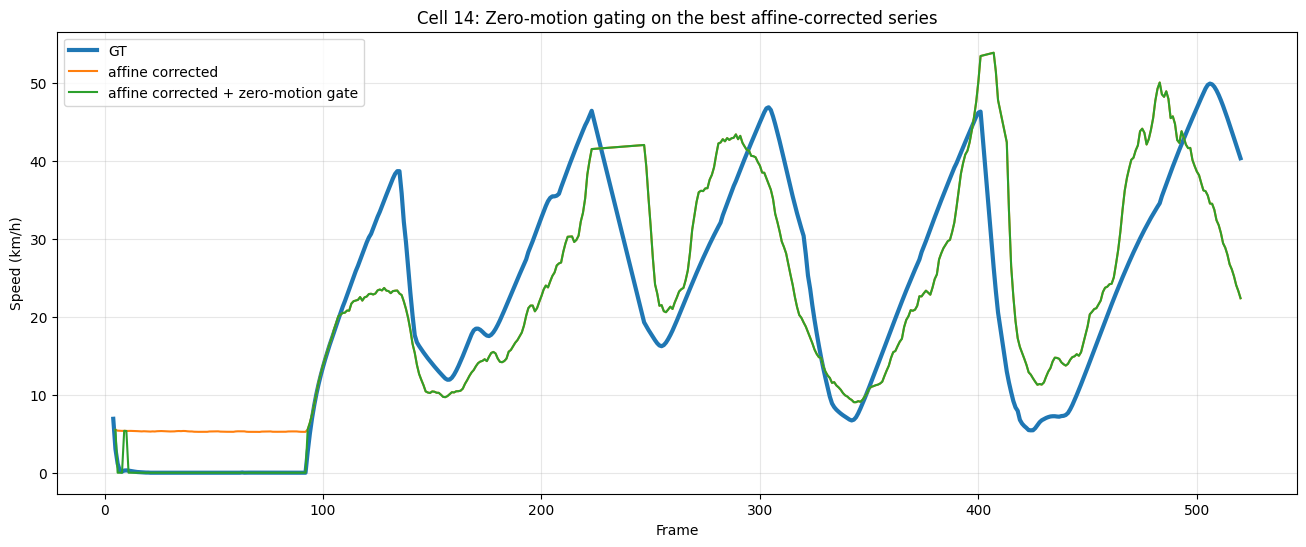

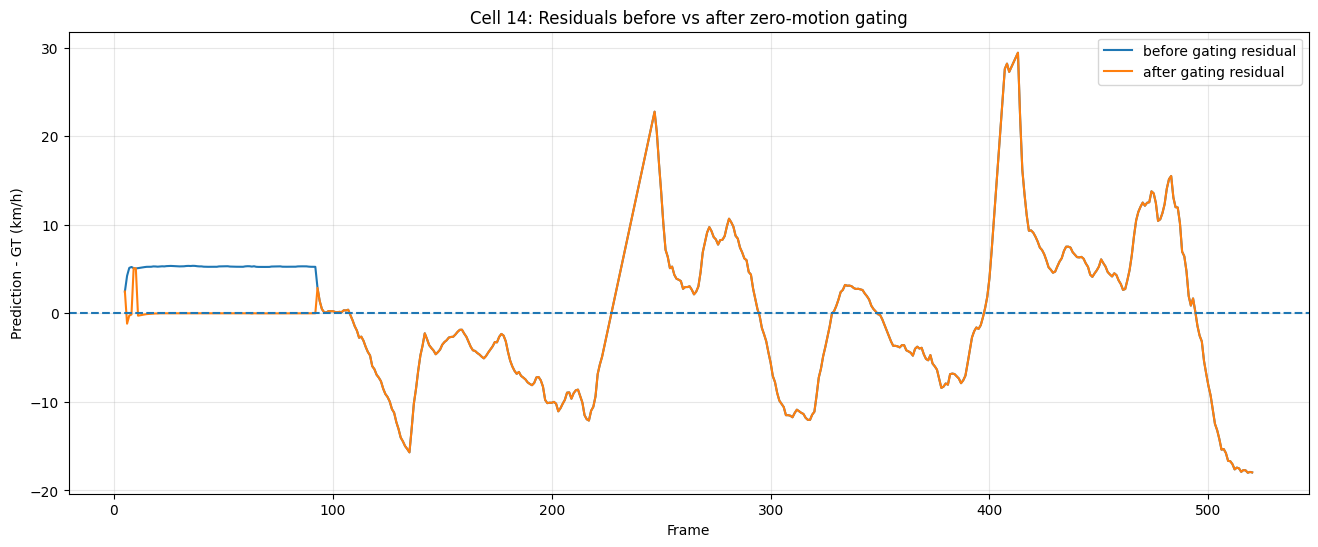

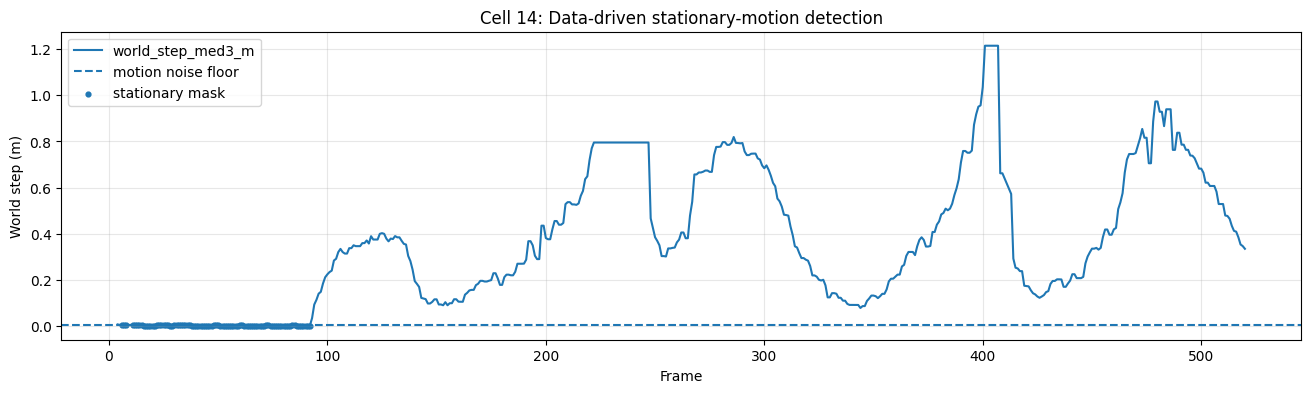


=== Saved zero-gated result ===


,base_source,base_corrected_col,zero_gated_col,motion_noise_floor_m,mae,rmse,bias,corr
0,bc_plus8_w5::smoothed_speed_kmh,smoothed_speed_kmh__affine_corrected,smoothed_speed_kmh__affine_corrected__zero_gated,0.003131,5.710508,7.717663,-0.927794,0.864644


In [15]:
# ============================================================
# Cell 14: Zero-motion gating on the best affine-corrected series
# Goal:
# - force speed to 0 km/h when measured motion is indistinguishable from jitter
# - do this using a data-driven motion-noise floor, not a hand-picked speed threshold
# - compare before vs after gating
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

assert "BEST_AFFINE_SOURCE_NAME" in globals(), "Run Cell 13 first."
assert "BEST_AFFINE_COMPARE_DF" in globals(), "Run Cell 13 first."
assert "BEST_AFFINE_PRED_COL" in globals(), "Run Cell 13 first."
assert "BEST_AFFINE_CORRECTED_COL" in globals(), "Run Cell 13 first."
assert "BEST_UPSTREAM_SMOOTHED_EXPERIMENT" in globals(), "Run Cell 11 first."
assert "local_all_obs" in globals(), "Run Cell 11 first."

# ------------------------------------------------------------
# 1) Recover the underlying trajectory for the best source
# Current best source should be the smoothed bc_plus8_w5 branch,
# but this logic is written to resolve it explicitly.
# ------------------------------------------------------------
if BEST_AFFINE_SOURCE_NAME.startswith("bc_plus"):
    best_source_experiment = BEST_AFFINE_SOURCE_NAME.split("::")[0]
elif BEST_AFFINE_SOURCE_NAME.startswith("Cell12::"):
    # Cell 12 winner ultimately came from the same source experiment
    best_source_experiment = BEST_UPSTREAM_SMOOTHED_EXPERIMENT
else:
    raise ValueError(f"Could not resolve source experiment from: {BEST_AFFINE_SOURCE_NAME}")

source_obs_df = local_all_obs[best_source_experiment].copy()

track_counts = source_obs_df["track_id"].value_counts().sort_values(ascending=False)
assert len(track_counts) > 0, "No track IDs found in source observations."
dominant_track_id = int(track_counts.index[0])

traj_df = (
    source_obs_df[source_obs_df["track_id"] == dominant_track_id]
    .sort_values("frame_idx")
    .reset_index(drop=True)
)

assert len(traj_df) > 5, "Not enough trajectory points for zero-motion gating."

# ------------------------------------------------------------
# 2) Compute frame-to-frame world displacement
# ------------------------------------------------------------
world_xy = traj_df[["world_x", "world_y"]].to_numpy(dtype=np.float64)

step_m = np.full(len(traj_df), np.nan, dtype=np.float64)
for i in range(1, len(traj_df)):
    step_m[i] = np.linalg.norm(world_xy[i] - world_xy[i - 1])

traj_df["world_step_m"] = step_m

# rolling median of displacement for a slightly more stable motion proxy
traj_df["world_step_med3_m"] = (
    traj_df["world_step_m"]
    .rolling(window=3, min_periods=1, center=True)
    .median()
)

# ------------------------------------------------------------
# 3) Estimate a motion-noise floor from the smallest observed steps
# This is data-driven:
# - take the lowest 20% of step sizes
# - estimate median + 3*MAD as the jitter floor
# ------------------------------------------------------------
finite_steps = traj_df["world_step_m"].to_numpy(dtype=np.float64)
finite_steps = finite_steps[np.isfinite(finite_steps)]

assert len(finite_steps) > 0, "No finite world-step values found."

low_q = np.quantile(finite_steps, 0.20)
low_steps = finite_steps[finite_steps <= low_q]

low_med = float(np.median(low_steps))
low_mad = float(np.median(np.abs(low_steps - low_med)))

# robust noise floor
motion_noise_floor_m = low_med + 3.0 * low_mad

# fallback in case MAD is effectively zero
if not np.isfinite(motion_noise_floor_m) or motion_noise_floor_m <= 0:
    motion_noise_floor_m = float(np.quantile(low_steps, 0.90))

print("=== Zero-motion gate estimation ===")
print(f"Dominant track ID           : {dominant_track_id}")
print(f"Low-step quantile cutoff    : {low_q:.6f} m")
print(f"Low-step median             : {low_med:.6f} m")
print(f"Low-step MAD                : {low_mad:.6f} m")
print(f"Motion noise floor (meters) : {motion_noise_floor_m:.6f} m")
print("===================================")

# ------------------------------------------------------------
# 4) Build stationary mask
# We say "stationary" when the local world-step median is below the noise floor.
# ------------------------------------------------------------
traj_df["stationary_motion_mask"] = traj_df["world_step_med3_m"] <= motion_noise_floor_m

# Optional cleanup: require at least 2 of 3 neighboring frames to look stationary
# This reduces one-frame flicker without hand-picking speed thresholds.
stationary_int = traj_df["stationary_motion_mask"].astype(np.int32)
traj_df["stationary_votes_3"] = (
    stationary_int.rolling(window=3, min_periods=1, center=True).sum()
)
traj_df["stationary_motion_mask_clean"] = traj_df["stationary_votes_3"] >= 2

# ------------------------------------------------------------
# 5) Merge stationary mask onto the best affine compare dataframe
# ------------------------------------------------------------
gated_df = BEST_AFFINE_COMPARE_DF.copy()

mask_df = traj_df[[
    "frame_idx",
    "world_step_m",
    "world_step_med3_m",
    "stationary_motion_mask",
    "stationary_motion_mask_clean",
]].copy()

gated_df = gated_df.merge(mask_df, on="frame_idx", how="left")

# fill missing masks safely
gated_df["stationary_motion_mask"] = gated_df["stationary_motion_mask"].fillna(False)
gated_df["stationary_motion_mask_clean"] = gated_df["stationary_motion_mask_clean"].fillna(False)

# ------------------------------------------------------------
# 6) Apply zero-motion gating to the best affine-corrected series
# ------------------------------------------------------------
gated_col = f"{BEST_AFFINE_CORRECTED_COL}__zero_gated"

gated_df[gated_col] = gated_df[BEST_AFFINE_CORRECTED_COL].copy()
gated_df.loc[gated_df["stationary_motion_mask_clean"], gated_col] = 0.0

# ------------------------------------------------------------
# 7) Metrics: before vs after gating
# ------------------------------------------------------------
before_metrics = compute_metrics(gated_df["gt_speed_kmh"], gated_df[BEST_AFFINE_CORRECTED_COL])
after_metrics = compute_metrics(gated_df["gt_speed_kmh"], gated_df[gated_col])

metrics_compare_df = pd.DataFrame([
    {"series": BEST_AFFINE_CORRECTED_COL, **before_metrics},
    {"series": gated_col, **after_metrics},
]).sort_values(["rmse", "mae"], ascending=[True, True]).reset_index(drop=True)

print("\n=== Before vs after zero-motion gating ===")
display(metrics_compare_df)

# ------------------------------------------------------------
# 8) Additional evaluation on truly stationary GT frames only
# This is only for analysis, not used in the gating logic itself.
# ------------------------------------------------------------
stationary_gt_eval_threshold_kmh = 1.0

stationary_eval_df = gated_df[gated_df["gt_speed_kmh"] <= stationary_gt_eval_threshold_kmh].copy()
moving_eval_df = gated_df[gated_df["gt_speed_kmh"] > stationary_gt_eval_threshold_kmh].copy()

def eval_subset(df, pred_col, subset_name):
    m = compute_metrics(df["gt_speed_kmh"], df[pred_col])
    return {"subset": subset_name, "series": pred_col, **m}

subset_metrics_df = pd.DataFrame([
    eval_subset(stationary_eval_df, BEST_AFFINE_CORRECTED_COL, "gt_stationary"),
    eval_subset(stationary_eval_df, gated_col, "gt_stationary"),
    eval_subset(moving_eval_df, BEST_AFFINE_CORRECTED_COL, "gt_moving"),
    eval_subset(moving_eval_df, gated_col, "gt_moving"),
])

print("\n=== Subset metrics (for diagnosis only) ===")
display(subset_metrics_df)

# ------------------------------------------------------------
# 9) Plot: before vs after gating
# ------------------------------------------------------------
plt.figure(figsize=(16, 6))
plt.plot(gated_df["frame_idx"], gated_df["gt_speed_kmh"], label="GT", linewidth=3)
plt.plot(gated_df["frame_idx"], gated_df[BEST_AFFINE_CORRECTED_COL], label="affine corrected")
plt.plot(gated_df["frame_idx"], gated_df[gated_col], label="affine corrected + zero-motion gate")
plt.xlabel("Frame")
plt.ylabel("Speed (km/h)")
plt.title("Cell 14: Zero-motion gating on the best affine-corrected series")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# ------------------------------------------------------------
# 10) Plot residuals before vs after
# ------------------------------------------------------------
plt.figure(figsize=(16, 6))
plt.plot(
    gated_df["frame_idx"],
    gated_df[BEST_AFFINE_CORRECTED_COL] - gated_df["gt_speed_kmh"],
    label="before gating residual"
)
plt.plot(
    gated_df["frame_idx"],
    gated_df[gated_col] - gated_df["gt_speed_kmh"],
    label="after gating residual"
)
plt.axhline(0.0, linestyle="--")
plt.xlabel("Frame")
plt.ylabel("Prediction - GT (km/h)")
plt.title("Cell 14: Residuals before vs after zero-motion gating")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# ------------------------------------------------------------
# 11) Plot the detected stationary mask
# ------------------------------------------------------------
plt.figure(figsize=(16, 4))
plt.plot(gated_df["frame_idx"], gated_df["world_step_med3_m"], label="world_step_med3_m")
plt.axhline(motion_noise_floor_m, linestyle="--", label="motion noise floor")
plt.scatter(
    gated_df.loc[gated_df["stationary_motion_mask_clean"], "frame_idx"],
    gated_df.loc[gated_df["stationary_motion_mask_clean"], "world_step_med3_m"],
    s=12,
    label="stationary mask"
)
plt.xlabel("Frame")
plt.ylabel("World step (m)")
plt.title("Cell 14: Data-driven stationary-motion detection")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# ------------------------------------------------------------
# 12) Save best gated result for later cells
# ------------------------------------------------------------
BEST_ZERO_GATED_COMPARE_DF = gated_df.copy()
BEST_ZERO_GATED_COL = gated_col
ZERO_MOTION_NOISE_FLOOR_M = motion_noise_floor_m

BEST_ZERO_GATED_SELECTION_SUMMARY_DF = pd.DataFrame([{
    "base_source": BEST_AFFINE_SOURCE_NAME,
    "base_corrected_col": BEST_AFFINE_CORRECTED_COL,
    "zero_gated_col": BEST_ZERO_GATED_COL,
    "motion_noise_floor_m": ZERO_MOTION_NOISE_FLOOR_M,
    "mae": float(after_metrics["mae"]),
    "rmse": float(after_metrics["rmse"]),
    "bias": float(after_metrics["bias"]),
    "corr": float(after_metrics["corr"]),
}])

print("\n=== Saved zero-gated result ===")
display(BEST_ZERO_GATED_SELECTION_SUMMARY_DF)

In [17]:
# ============================================================
# Cell 15: Class-aware physical-dimension priors for live inference
# Purpose:
# - define class-specific size priors for tracked objects
# - provide safe lookup helpers for live inference
# - support future speed estimation without affine correction
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1) Canonical dimension priors (meters)
# Notes:
# - These are approximate deployment priors, not exact truths.
# - They are meant to be robust defaults for live inference.
# - "height_m" is included because it may help later for scale logic.
# ------------------------------------------------------------
CLASS_DIMENSION_PRIORS = {
    "Human": {
        "width_m": 0.50,
        "length_m": 0.50,
        "height_m": 1.70,
        "rep_point_mode": "bottom_center",
        "rep_y_offset_px": 8.0,
        "notes": "Average standing adult footprint prior",
    },
    "Bicycle": {
        "width_m": 0.60,
        "length_m": 1.80,
        "height_m": 1.10,
        "rep_point_mode": "bottom_center",
        "rep_y_offset_px": 8.0,
        "notes": "Average bicycle dimensions",
    },
    "Car": {
        "width_m": 1.85,
        "length_m": 4.50,
        "height_m": 1.50,
        "rep_point_mode": "bottom_center",
        "rep_y_offset_px": 8.0,
        "notes": "Average passenger-car prior",
    },
    "Truck": {
        "width_m": 2.50,
        "length_m": 7.00,
        "height_m": 3.20,
        "rep_point_mode": "bottom_center",
        "rep_y_offset_px": 8.0,
        "notes": "Medium truck prior",
    },
    "Bus": {
        "width_m": 2.55,
        "length_m": 12.00,
        "height_m": 3.20,
        "rep_point_mode": "bottom_center",
        "rep_y_offset_px": 8.0,
        "notes": "Standard transit-bus prior",
    },
    "Other": {
        "width_m": 2.00,
        "length_m": 4.50,
        "height_m": 1.80,
        "rep_point_mode": "bottom_center",
        "rep_y_offset_px": 8.0,
        "notes": "Fallback object prior",
    },
}

# ------------------------------------------------------------
# 2) Aliases for common alternative class names
# This helps if live inference returns slightly different labels later.
# ------------------------------------------------------------
CLASS_PRIOR_ALIASES = {
    "person": "Human",
    "pedestrian": "Human",
    "people": "Human",

    "bike": "Bicycle",
    "bicycle": "Bicycle",
    "cyclist": "Bicycle",

    "car": "Car",
    "sedan": "Car",
    "van": "Car",
    "suv": "Car",
    "pickup": "Car",

    "truck": "Truck",
    "lorry": "Truck",
    "semi": "Truck",

    "bus": "Bus",
    "coach": "Bus",

    "other": "Other",
    "motor": "Other",
    "vehicle": "Other",
}

# ------------------------------------------------------------
# 3) Helper functions
# ------------------------------------------------------------
def canonicalize_class_name(label: str) -> str:
    if label is None:
        return "Other"

    label = str(label).strip()
    if label in CLASS_DIMENSION_PRIORS:
        return label

    lowered = label.lower()
    if lowered in CLASS_PRIOR_ALIASES:
        return CLASS_PRIOR_ALIASES[lowered]

    return "Other"

def get_class_dimension_prior(label: str) -> dict:
    canonical = canonicalize_class_name(label)
    prior = CLASS_DIMENSION_PRIORS[canonical].copy()
    prior["canonical_label"] = canonical
    prior["requested_label"] = label
    return prior

def get_class_dimensions_m(label: str):
    prior = get_class_dimension_prior(label)
    return prior["width_m"], prior["length_m"], prior["height_m"]

def get_class_rep_point_settings(label: str):
    prior = get_class_dimension_prior(label)
    return prior["rep_point_mode"], prior["rep_y_offset_px"]

def summarize_class_dimension_priors():
    rows = []
    for label, prior in CLASS_DIMENSION_PRIORS.items():
        rows.append({
            "class_label": label,
            "width_m": prior["width_m"],
            "length_m": prior["length_m"],
            "height_m": prior["height_m"],
            "rep_point_mode": prior["rep_point_mode"],
            "rep_y_offset_px": prior["rep_y_offset_px"],
            "notes": prior["notes"],
        })
    return pd.DataFrame(rows)

# ------------------------------------------------------------
# 4) Preview
# ------------------------------------------------------------
CLASS_PRIORS_DF = summarize_class_dimension_priors()

print("=== Class-aware dimension priors ===")
display(CLASS_PRIORS_DF)

print("\n=== Example prior lookups ===")
for label in ["Car", "Truck", "person", "van", "bus", "unknown_label"]:
    print(label, "->", get_class_dimension_prior(label))

=== Class-aware dimension priors ===


,class_label,width_m,length_m,height_m,rep_point_mode,rep_y_offset_px,notes
0,Human,0.50,0.5,1.7,bottom_center,8.0,Average standing adult footprint prior
1,Bicycle,0.60,1.8,1.1,bottom_center,8.0,Average bicycle dimensions
2,Car,1.85,4.5,1.5,bottom_center,8.0,Average passenger-car prior
3,Truck,2.50,7.0,3.2,bottom_center,8.0,Medium truck prior
4,Bus,2.55,12.0,3.2,bottom_center,8.0,Standard transit-bus prior
5,Other,2.00,4.5,1.8,bottom_center,8.0,Fallback object prior



=== Example prior lookups ===
Car -> {'width_m': 1.85, 'length_m': 4.5, 'height_m': 1.5, 'rep_point_mode': 'bottom_center', 'rep_y_offset_px': 8.0, 'notes': 'Average passenger-car prior', 'canonical_label': 'Car', 'requested_label': 'Car'}
Truck -> {'width_m': 2.5, 'length_m': 7.0, 'height_m': 3.2, 'rep_point_mode': 'bottom_center', 'rep_y_offset_px': 8.0, 'notes': 'Medium truck prior', 'canonical_label': 'Truck', 'requested_label': 'Truck'}
person -> {'width_m': 0.5, 'length_m': 0.5, 'height_m': 1.7, 'rep_point_mode': 'bottom_center', 'rep_y_offset_px': 8.0, 'notes': 'Average standing adult footprint prior', 'canonical_label': 'Human', 'requested_label': 'person'}
van -> {'width_m': 1.85, 'length_m': 4.5, 'height_m': 1.5, 'rep_point_mode': 'bottom_center', 'rep_y_offset_px': 8.0, 'notes': 'Average passenger-car prior', 'canonical_label': 'Car', 'requested_label': 'van'}
bus -> {'width_m': 2.55, 'length_m': 12.0, 'height_m': 3.2, 'rep_point_mode': 'bottom_center', 'rep_y_offset_px': 8

Source experiment : bc_plus8_w5
Dominant track ID : 1
Trajectory rows   : 486
FPS               : 20.0
FPS source        : video metadata

=== Class-aware local-scale metrics ===


,series,count,mae,rmse,bias,corr
0,class_local_smoothed_speed_kmh,485,7.264887,9.254551,-6.206038,0.894443
1,class_local_raw_speed_kmh,484,6.918218,10.573405,-6.095869,0.826060
2,smoothed_speed_kmh,485,7.009462,10.816655,3.003827,0.847553
3,raw_speed_kmh,485,7.316032,11.022339,3.103325,0.845823


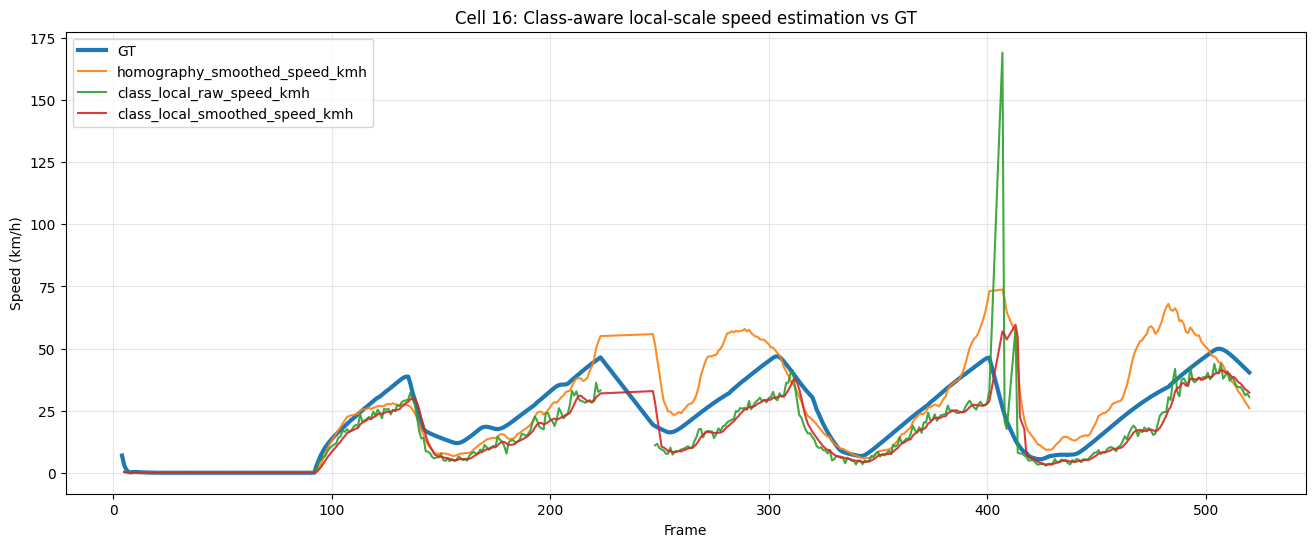

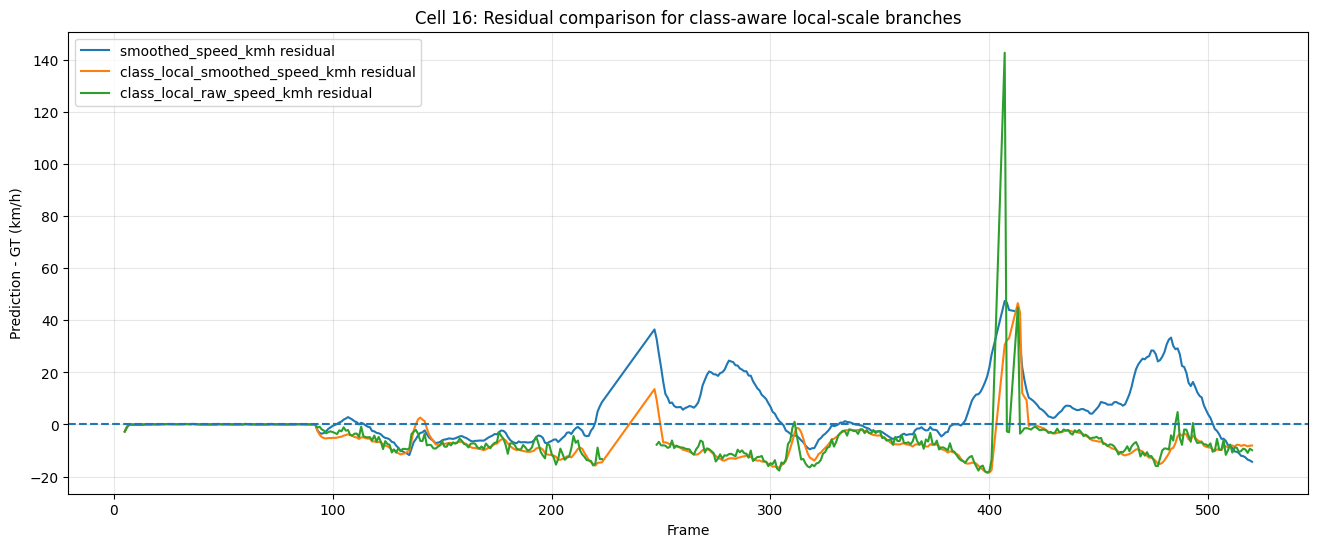


=== Local scale summary ===


,bbox_width_px,bbox_height_px,mpp_x,mpp_y,mpp_geom,class_local_mpp
count,486.000000,486.000000,486.000000,486.000000,486.000000,485.000000
mean,80.258088,62.072052,0.023701,0.081141,0.043039,0.043024
std,13.524383,19.932280,0.003961,0.027525,0.007832,0.007802
min,53.503723,36.496826,0.015565,0.048724,0.029962,0.029966
25%,70.200058,39.205475,0.021429,0.053908,0.037801,0.037499
50%,80.654999,62.075485,0.022937,0.072492,0.041715,0.041668
75%,86.330791,83.476301,0.026353,0.114788,0.052019,0.052016
max,118.855835,92.357754,0.034577,0.123298,0.060269,0.059800



Saved for later cells:
BEST_CLASS_LOCAL_SERIES = class_local_smoothed_speed_kmh


In [19]:
# ============================================================
# Cell 16: Class-aware local-scale speed estimation (no affine)
# Proper practice:
# - uses actual FPS from the current input video
# - falls back to DEFAULT_FPS only if metadata is unusable
# - derives class prior from label if present, else from class_id
# - compares class-aware local-scale speed vs current homography-based upstream
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

assert "BEST_UPSTREAM_SMOOTHED_EXPERIMENT" in globals(), "Run Cell 11 first."
assert "local_all_obs" in globals(), "Run Cell 11 first."
assert "CLASS_DIMENSION_PRIORS" in globals(), "Run Cell 15 first."
assert BEST_UPSTREAM_SMOOTHED_EXPERIMENT in local_all_obs, "Best upstream experiment observations not found."

# ------------------------------------------------------------
# 1) Load winning upstream trajectory
# ------------------------------------------------------------
source_experiment = BEST_UPSTREAM_SMOOTHED_EXPERIMENT
source_obs_df = local_all_obs[source_experiment].copy()

track_counts = source_obs_df["track_id"].value_counts().sort_values(ascending=False)
assert len(track_counts) > 0, "No track IDs found in source observations."

dominant_track_id = int(track_counts.index[0])

traj_df = (
    source_obs_df[source_obs_df["track_id"] == dominant_track_id]
    .sort_values("frame_idx")
    .reset_index(drop=True)
)

assert len(traj_df) > 5, "Not enough trajectory points."

gt_df = load_gt_csv(GT_CSV_PATH)

# ------------------------------------------------------------
# 2) FPS: use actual video FPS, fallback only if unusable
# ------------------------------------------------------------
cap = cv2.VideoCapture(str(VIDEO_PATH))
assert cap.isOpened(), f"Could not open video: {VIDEO_PATH}"
fps_from_video = cap.get(cv2.CAP_PROP_FPS)
cap.release()

if fps_from_video is None or not np.isfinite(fps_from_video) or fps_from_video <= 1:
    fps = DEFAULT_FPS
    fps_source = f"fallback DEFAULT_FPS={DEFAULT_FPS}"
else:
    fps = float(fps_from_video)
    fps_source = "video metadata"

print("Source experiment :", source_experiment)
print("Dominant track ID :", dominant_track_id)
print("Trajectory rows   :", len(traj_df))
print("FPS               :", fps)
print("FPS source        :", fps_source)

# ------------------------------------------------------------
# 3) Helper functions for class-aware local scale
# ------------------------------------------------------------
def safe_bbox_dims(box_row):
    w_px = float(box_row["bbox_x2"] - box_row["bbox_x1"])
    h_px = float(box_row["bbox_y2"] - box_row["bbox_y1"])
    return max(w_px, 1e-6), max(h_px, 1e-6)

def resolve_label_from_row(box_row):
    if "label" in box_row.index and pd.notna(box_row["label"]):
        return str(box_row["label"])
    if "class_id" in box_row.index and pd.notna(box_row["class_id"]):
        return PHASE_CLASSES.get(int(box_row["class_id"]), "Other")
    return "Other"

def local_scale_from_class_prior(box_row):
    """
    Estimate local meters-per-pixel from bbox size and class prior.

    mpp_x = class_width_m / bbox_width_px
    mpp_y = class_length_m / bbox_height_px

    We combine them with a geometric mean.
    """
    label = resolve_label_from_row(box_row)
    prior = get_class_dimension_prior(label)

    width_m = float(prior["width_m"])
    length_m = float(prior["length_m"])

    w_px, h_px = safe_bbox_dims(box_row)

    mpp_x = width_m / w_px
    mpp_y = length_m / h_px
    mpp_geom = float(np.sqrt(max(mpp_x, 1e-12) * max(mpp_y, 1e-12)))

    return {
        "canonical_label": prior["canonical_label"],
        "width_m": width_m,
        "length_m": length_m,
        "bbox_width_px": w_px,
        "bbox_height_px": h_px,
        "mpp_x": mpp_x,
        "mpp_y": mpp_y,
        "mpp_geom": mpp_geom,
    }

def speed_from_local_class_scale(prev_row, curr_row, fps):
    """
    Estimate speed using representative-point displacement in image space
    times a local meters-per-pixel estimate averaged over adjacent frames.
    """
    dx = float(curr_row["rep_image_x"] - prev_row["rep_image_x"])
    dy = float(curr_row["rep_image_y"] - prev_row["rep_image_y"])
    disp_px = float(np.sqrt(dx * dx + dy * dy))

    scale_prev = local_scale_from_class_prior(prev_row)["mpp_geom"]
    scale_curr = local_scale_from_class_prior(curr_row)["mpp_geom"]
    local_mpp = 0.5 * (scale_prev + scale_curr)

    dt = 1.0 / float(fps)
    dist_m = disp_px * local_mpp
    speed_kmh = (dist_m / dt) * 3.6
    return speed_kmh, disp_px, local_mpp

def moving_average_nan(values, window=5):
    out = np.full(len(values), np.nan, dtype=np.float64)
    for i in range(len(values)):
        lo = max(0, i - window + 1)
        vals = values[lo:i+1]
        vals = vals[np.isfinite(vals)]
        if len(vals) > 0:
            out[i] = np.mean(vals)
    return out

# ------------------------------------------------------------
# 4) Build class-aware local-scale series
# ------------------------------------------------------------
traj_class_df = traj_df.copy()

prior_rows = []
for _, row in traj_class_df.iterrows():
    prior_rows.append(local_scale_from_class_prior(row))

prior_df = pd.DataFrame(prior_rows)
traj_class_df = pd.concat([traj_class_df.reset_index(drop=True), prior_df.reset_index(drop=True)], axis=1)

local_raw = np.full(len(traj_class_df), np.nan, dtype=np.float64)
disp_px_arr = np.full(len(traj_class_df), np.nan, dtype=np.float64)
local_mpp_arr = np.full(len(traj_class_df), np.nan, dtype=np.float64)

for i in range(1, len(traj_class_df)):
    prev_row = traj_class_df.iloc[i - 1]
    curr_row = traj_class_df.iloc[i]
    speed_kmh, disp_px, local_mpp = speed_from_local_class_scale(prev_row, curr_row, fps=fps)

    if speed_kmh < MIN_REASONABLE_SPEED_KMH or speed_kmh > MAX_REASONABLE_SPEED_KMH:
        speed_kmh = np.nan

    local_raw[i] = speed_kmh
    disp_px_arr[i] = disp_px
    local_mpp_arr[i] = local_mpp

traj_class_df["class_local_disp_px"] = disp_px_arr
traj_class_df["class_local_mpp"] = local_mpp_arr
traj_class_df["class_local_raw_speed_kmh"] = local_raw
traj_class_df["class_local_smoothed_speed_kmh"] = moving_average_nan(local_raw, window=5)

# ------------------------------------------------------------
# 5) Compare with current best homography-based upstream series
# ------------------------------------------------------------
compare_class_df = gt_df.merge(
    traj_class_df[[
        "frame_idx",
        "class_id",
        "raw_speed_kmh",
        "smoothed_speed_kmh",
        "class_local_raw_speed_kmh",
        "class_local_smoothed_speed_kmh",
        "class_local_disp_px",
        "class_local_mpp",
        "canonical_label",
        "bbox_width_px",
        "bbox_height_px",
        "mpp_x",
        "mpp_y",
        "mpp_geom",
    ]],
    on="frame_idx",
    how="inner"
)

assert len(compare_class_df) > 0, "GT merge produced 0 rows."

candidate_cols = [
    "raw_speed_kmh",
    "smoothed_speed_kmh",
    "class_local_raw_speed_kmh",
    "class_local_smoothed_speed_kmh",
]

class_metric_rows = []
for col in candidate_cols:
    if col in compare_class_df.columns:
        metrics = compute_metrics(compare_class_df["gt_speed_kmh"], compare_class_df[col])
        class_metric_rows.append({
            "series": col,
            **metrics
        })

CLASS_LOCAL_SCALE_METRICS_DF = (
    pd.DataFrame(class_metric_rows)
    .sort_values(["rmse", "mae", "corr"], ascending=[True, True, False])
    .reset_index(drop=True)
)

print("\n=== Class-aware local-scale metrics ===")
display(CLASS_LOCAL_SCALE_METRICS_DF)

# ------------------------------------------------------------
# 6) Plot GT vs candidates
# ------------------------------------------------------------
plt.figure(figsize=(16, 6))
plt.plot(compare_class_df["frame_idx"], compare_class_df["gt_speed_kmh"], label="GT", linewidth=3)
plt.plot(compare_class_df["frame_idx"], compare_class_df["smoothed_speed_kmh"], label="homography_smoothed_speed_kmh", alpha=0.9)
plt.plot(compare_class_df["frame_idx"], compare_class_df["class_local_raw_speed_kmh"], label="class_local_raw_speed_kmh", alpha=0.9)
plt.plot(compare_class_df["frame_idx"], compare_class_df["class_local_smoothed_speed_kmh"], label="class_local_smoothed_speed_kmh", alpha=0.9)
plt.xlabel("Frame")
plt.ylabel("Speed (km/h)")
plt.title("Cell 16: Class-aware local-scale speed estimation vs GT")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# ------------------------------------------------------------
# 7) Residual comparison
# ------------------------------------------------------------
plt.figure(figsize=(16, 6))
for col in ["smoothed_speed_kmh", "class_local_smoothed_speed_kmh", "class_local_raw_speed_kmh"]:
    resid = compare_class_df[col] - compare_class_df["gt_speed_kmh"]
    plt.plot(compare_class_df["frame_idx"], resid, label=f"{col} residual")
plt.axhline(0.0, linestyle="--")
plt.xlabel("Frame")
plt.ylabel("Prediction - GT (km/h)")
plt.title("Cell 16: Residual comparison for class-aware local-scale branches")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# ------------------------------------------------------------
# 8) Inspect local scale behavior
# ------------------------------------------------------------
scale_summary_df = compare_class_df[[
    "bbox_width_px",
    "bbox_height_px",
    "mpp_x",
    "mpp_y",
    "mpp_geom",
    "class_local_mpp",
]].describe()

print("\n=== Local scale summary ===")
display(scale_summary_df)

# ------------------------------------------------------------
# 9) Save outputs for next cell
# ------------------------------------------------------------
BEST_CLASS_LOCAL_SERIES = CLASS_LOCAL_SCALE_METRICS_DF.iloc[0]["series"]
BEST_CLASS_LOCAL_COMPARE_DF = compare_class_df.copy()

print("\nSaved for later cells:")
print("BEST_CLASS_LOCAL_SERIES =", BEST_CLASS_LOCAL_SERIES)

=== Dominant track class distribution ===


,count
canonical_label,
Car,486


FPS used: 20.0

=== Class-aware scale refinement metrics ===


,series,count,mae,rmse,bias,corr
0,mpp_geom_ma5__smoothed_speed_kmh,485,7.222292,9.058137,-6.252270,0.907005
1,mpp_geom__smoothed_speed_kmh,485,7.264887,9.254551,-6.206038,0.894443
2,mpp_geom_ma5__raw_speed_kmh,484,6.865959,9.988820,-6.144016,0.854481
3,mpp_geom__raw_speed_kmh,484,6.918218,10.573405,-6.095869,0.826060
4,mpp_weighted_75w_25h_ma5__smoothed_speed_kmh,485,8.784737,10.716343,-8.066301,0.907630
5,smoothed_speed_kmh,485,7.009462,10.816655,3.003827,0.847553
6,mpp_weighted_75w_25h__smoothed_speed_kmh,485,8.826208,10.837492,-8.028299,0.894921
7,mpp_weighted_75w_25h_ma5__raw_speed_kmh,484,8.571293,11.249540,-7.970045,0.855542
8,mpp_weighted_75w_25h__raw_speed_kmh,484,8.601242,11.639990,-7.930313,0.826972
9,mpp_height_only__smoothed_speed_kmh,485,7.923683,13.047848,5.420255,0.897985


Best refined class-aware series: mpp_geom_ma5__smoothed_speed_kmh


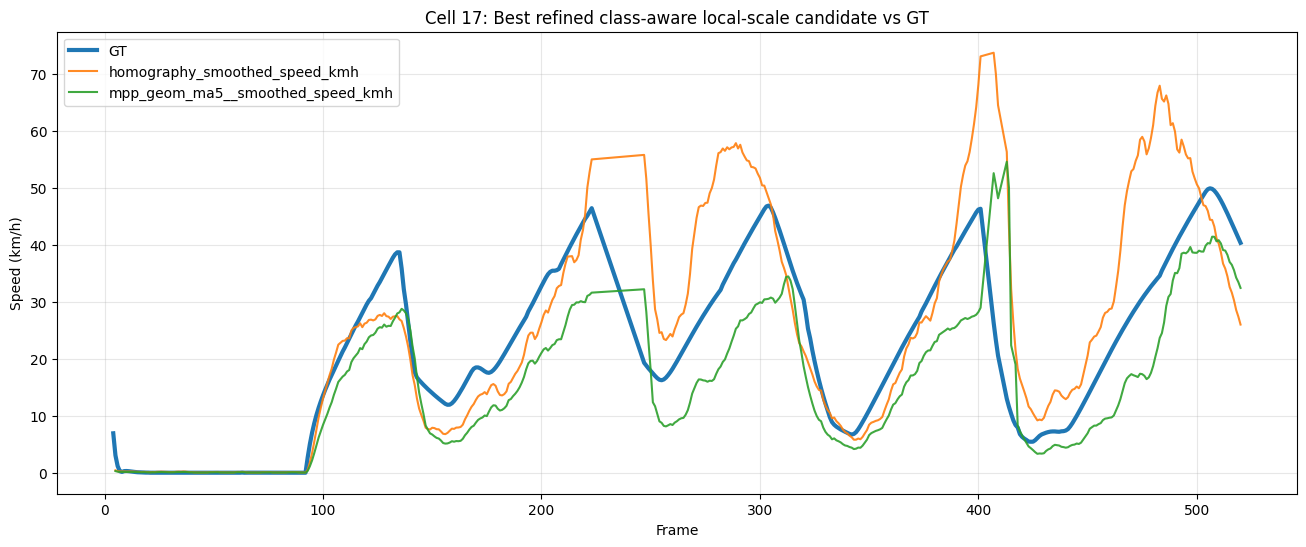

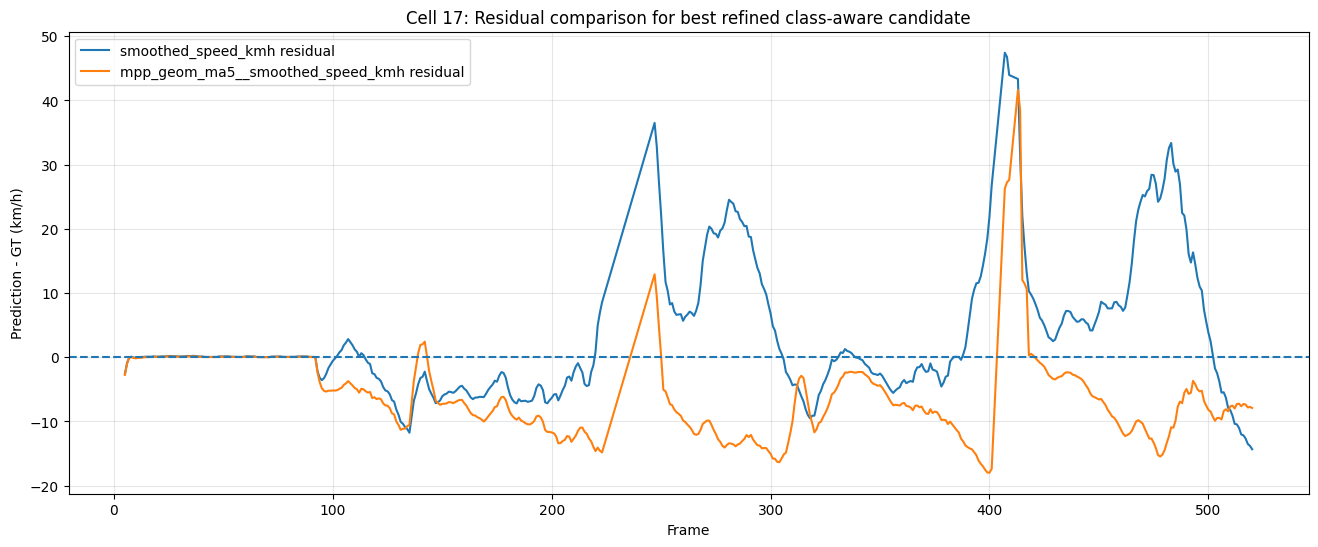


Saved for later cells:
BEST_REFINED_CLASS_SCALE_SERIES = mpp_geom_ma5__smoothed_speed_kmh


In [20]:
# ============================================================
# Cell 17: Refine class-aware local-scale fusion for the single-car case
# Goal:
# - keep the class-aware non-affine approach
# - test different ways to convert bbox size -> local meters-per-pixel
# - identify which local-scale formulation works best
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

assert "BEST_CLASS_LOCAL_COMPARE_DF" in globals(), "Run Cell 16 first."
assert "BEST_CLASS_LOCAL_SERIES" in globals(), "Run Cell 16 first."

compare_class_df = BEST_CLASS_LOCAL_COMPARE_DF.copy()

# ------------------------------------------------------------
# 1) Sanity check dominant label
# ------------------------------------------------------------
if "canonical_label" in compare_class_df.columns:
    label_counts = compare_class_df["canonical_label"].value_counts(dropna=False)
    print("=== Dominant track class distribution ===")
    display(label_counts.to_frame("count"))

# ------------------------------------------------------------
# 2) Scale-fusion helpers
# ------------------------------------------------------------
def moving_average_nan(values, window=5):
    out = np.full(len(values), np.nan, dtype=np.float64)
    for i in range(len(values)):
        lo = max(0, i - window + 1)
        vals = values[lo:i+1]
        vals = vals[np.isfinite(vals)]
        if len(vals) > 0:
            out[i] = np.mean(vals)
    return out

def build_speed_from_scale_series(rep_x, rep_y, mpp_series, fps):
    out = np.full(len(rep_x), np.nan, dtype=np.float64)
    disp_px = np.full(len(rep_x), np.nan, dtype=np.float64)

    for i in range(1, len(rep_x)):
        dx = float(rep_x[i] - rep_x[i - 1])
        dy = float(rep_y[i] - rep_y[i - 1])
        dpx = float(np.sqrt(dx * dx + dy * dy))
        disp_px[i] = dpx

        if np.isfinite(mpp_series[i]) and np.isfinite(mpp_series[i - 1]):
            local_mpp = 0.5 * (mpp_series[i] + mpp_series[i - 1])
            speed_kmh = (dpx * local_mpp) * fps * 3.6
            if speed_kmh < MIN_REASONABLE_SPEED_KMH or speed_kmh > MAX_REASONABLE_SPEED_KMH:
                speed_kmh = np.nan
            out[i] = speed_kmh

    return out, disp_px

# ------------------------------------------------------------
# 3) Build candidate local-scale series
# ------------------------------------------------------------
# These came from Cell 16 merge
mpp_x = compare_class_df["mpp_x"].to_numpy(dtype=np.float64)
mpp_y = compare_class_df["mpp_y"].to_numpy(dtype=np.float64)
mpp_geom = compare_class_df["mpp_geom"].to_numpy(dtype=np.float64)

rep_x = compare_class_df["rep_image_x"].to_numpy(dtype=np.float64) if "rep_image_x" in compare_class_df.columns else None
rep_y = compare_class_df["rep_image_y"].to_numpy(dtype=np.float64) if "rep_image_y" in compare_class_df.columns else None

# If rep points were not carried forward in Cell 16 merge, recover them from the source experiment
if rep_x is None or rep_y is None:
    source_experiment = BEST_UPSTREAM_SMOOTHED_EXPERIMENT
    source_obs_df = local_all_obs[source_experiment].copy()
    dominant_track_id = int(source_obs_df["track_id"].value_counts().index[0])
    traj_df = (
        source_obs_df[source_obs_df["track_id"] == dominant_track_id]
        .sort_values("frame_idx")
        .reset_index(drop=True)
    )
    compare_class_df = compare_class_df.merge(
        traj_df[["frame_idx", "rep_image_x", "rep_image_y"]],
        on="frame_idx",
        how="left"
    )
    rep_x = compare_class_df["rep_image_x"].to_numpy(dtype=np.float64)
    rep_y = compare_class_df["rep_image_y"].to_numpy(dtype=np.float64)

# Actual FPS from current video
cap = cv2.VideoCapture(str(VIDEO_PATH))
assert cap.isOpened(), f"Could not open video: {VIDEO_PATH}"
fps = cap.get(cv2.CAP_PROP_FPS)
cap.release()
if fps is None or not np.isfinite(fps) or fps <= 1:
    fps = DEFAULT_FPS

print("FPS used:", fps)

scale_candidates = {
    "mpp_width_only": mpp_x,
    "mpp_height_only": mpp_y,
    "mpp_geom": mpp_geom,
    "mpp_weighted_75w_25h": 0.75 * mpp_x + 0.25 * mpp_y,
    "mpp_weighted_90w_10h": 0.90 * mpp_x + 0.10 * mpp_y,
    "mpp_geom_ma5": moving_average_nan(mpp_geom, window=5),
    "mpp_width_ma5": moving_average_nan(mpp_x, window=5),
    "mpp_weighted_75w_25h_ma5": moving_average_nan(0.75 * mpp_x + 0.25 * mpp_y, window=5),
}

# ------------------------------------------------------------
# 4) Generate speed candidates from each scale formulation
# ------------------------------------------------------------
refine_df = compare_class_df[["frame_idx", "gt_speed_kmh", "smoothed_speed_kmh"]].copy()

for scale_name, scale_series in scale_candidates.items():
    raw_speed, disp_px = build_speed_from_scale_series(rep_x, rep_y, scale_series, fps=fps)
    refine_df[f"{scale_name}__raw_speed_kmh"] = raw_speed
    refine_df[f"{scale_name}__smoothed_speed_kmh"] = moving_average_nan(raw_speed, window=5)

# ------------------------------------------------------------
# 5) Metrics
# ------------------------------------------------------------
candidate_cols = ["smoothed_speed_kmh"]
candidate_cols += [c for c in refine_df.columns if c.endswith("__raw_speed_kmh")]
candidate_cols += [c for c in refine_df.columns if c.endswith("__smoothed_speed_kmh")]

metric_rows = []
for col in candidate_cols:
    if col == "gt_speed_kmh":
        continue
    metrics = compute_metrics(refine_df["gt_speed_kmh"], refine_df[col])
    metric_rows.append({
        "series": col,
        **metrics
    })

CLASS_SCALE_REFINEMENT_METRICS_DF = (
    pd.DataFrame(metric_rows)
    .sort_values(["rmse", "mae", "corr"], ascending=[True, True, False])
    .reset_index(drop=True)
)

print("\n=== Class-aware scale refinement metrics ===")
display(CLASS_SCALE_REFINEMENT_METRICS_DF)

best_refined_series = CLASS_SCALE_REFINEMENT_METRICS_DF.iloc[0]["series"]
print("Best refined class-aware series:", best_refined_series)

# ------------------------------------------------------------
# 6) Plot best refined candidate vs current homography-smoothed
# ------------------------------------------------------------
plt.figure(figsize=(16, 6))
plt.plot(refine_df["frame_idx"], refine_df["gt_speed_kmh"], label="GT", linewidth=3)
plt.plot(refine_df["frame_idx"], refine_df["smoothed_speed_kmh"], label="homography_smoothed_speed_kmh", alpha=0.9)
plt.plot(refine_df["frame_idx"], refine_df[best_refined_series], label=best_refined_series, alpha=0.9)
plt.xlabel("Frame")
plt.ylabel("Speed (km/h)")
plt.title("Cell 17: Best refined class-aware local-scale candidate vs GT")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# ------------------------------------------------------------
# 7) Residual comparison
# ------------------------------------------------------------
plt.figure(figsize=(16, 6))
for col in ["smoothed_speed_kmh", best_refined_series]:
    resid = refine_df[col] - refine_df["gt_speed_kmh"]
    plt.plot(refine_df["frame_idx"], resid, label=f"{col} residual")
plt.axhline(0.0, linestyle="--")
plt.xlabel("Frame")
plt.ylabel("Prediction - GT (km/h)")
plt.title("Cell 17: Residual comparison for best refined class-aware candidate")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# ------------------------------------------------------------
# 8) Save outputs
# ------------------------------------------------------------
BEST_REFINED_CLASS_SCALE_SERIES = best_refined_series
BEST_REFINED_CLASS_SCALE_COMPARE_DF = refine_df.copy()

print("\nSaved for later cells:")
print("BEST_REFINED_CLASS_SCALE_SERIES =", BEST_REFINED_CLASS_SCALE_SERIES)

=== Dominant track class_id distribution ===


,count
class_id,
3,486



=== Dominant track resolved class distribution ===


,count
class_id,
Car,486



FPS used: 20.0 (video metadata)

=== Car-prior tuning: RAW ranked ===


,experiment,width_m,length_m,fusion,smooth_mpp,series,count,mae,rmse,bias,corr
0,car_w2.05_l5.10_geom_mppMA5,2.05,5.1,geom,True,car_tuned_raw_speed_kmh,484,5.255842,9.205468,-4.327331,0.854481
1,car_w1.95_l5.10_geom_mppMA5,1.95,5.1,geom,True,car_tuned_raw_speed_kmh,484,5.609272,9.335232,-4.744042,0.854481
2,car_w2.05_l4.80_geom_mppMA5,2.05,4.8,geom,True,car_tuned_raw_speed_kmh,484,5.685077,9.366321,-4.831152,0.854481
3,car_w1.85_l5.10_geom_mppMA5,1.85,5.1,geom,True,car_tuned_raw_speed_kmh,484,5.983472,9.500544,-5.171582,0.854481
4,car_w1.95_l4.80_geom_mppMA5,1.95,4.8,geom,True,car_tuned_raw_speed_kmh,484,6.040123,9.527925,-5.235421,0.854481
5,car_w2.05_l4.50_geom_mppMA5,2.05,4.5,geom,True,car_tuned_raw_speed_kmh,484,6.143106,9.579225,-5.350980,0.854481
6,car_w1.75_l5.10_geom_mppMA5,1.75,5.1,geom,True,car_tuned_raw_speed_kmh,484,6.376211,9.702587,-5.610842,0.854481
7,car_w1.85_l4.80_geom_mppMA5,1.85,4.8,geom,True,car_tuned_raw_speed_kmh,484,6.411977,9.722215,-5.650196,0.854481
8,car_w1.95_l4.50_geom_mppMA5,1.95,4.5,geom,True,car_tuned_raw_speed_kmh,484,6.496686,9.769165,-5.742412,0.854481
9,car_w2.05_l4.20_geom_mppMA5,2.05,4.2,geom,True,car_tuned_raw_speed_kmh,484,6.630962,9.846215,-5.888443,0.854481



=== Car-prior tuning: SMOOTHED ranked ===


,experiment,width_m,length_m,fusion,smooth_mpp,series,count,mae,rmse,bias,corr
0,car_w2.05_l5.10_geom_mppMA5,2.05,5.1,geom,True,car_tuned_smoothed_speed_kmh,485,5.723852,7.769110,-4.449119,0.907005
1,car_w1.95_l5.10_geom_mppMA5,1.95,5.1,geom,True,car_tuned_smoothed_speed_kmh,485,6.053667,8.023645,-4.862726,0.907005
2,car_w2.05_l5.10_geom_noMppSmooth,2.05,5.1,geom,False,car_tuned_smoothed_speed_kmh,485,5.791679,8.072389,-4.397309,0.894443
3,car_w2.05_l4.80_geom_mppMA5,2.05,4.8,geom,True,car_tuned_smoothed_speed_kmh,485,6.125210,8.080289,-4.949187,0.907005
4,car_w1.95_l5.10_geom_noMppSmooth,1.95,5.1,geom,False,car_tuned_smoothed_speed_kmh,485,6.108802,8.300094,-4.812195,0.894443
5,car_w1.85_l5.10_geom_mppMA5,1.85,5.1,geom,True,car_tuned_smoothed_speed_kmh,485,6.407777,8.312305,-5.287081,0.907005
6,car_w2.05_l4.80_geom_noMppSmooth,2.05,4.8,geom,False,car_tuned_smoothed_speed_kmh,485,6.177410,8.351281,-4.898924,0.894443
7,car_w1.95_l4.80_geom_mppMA5,1.95,4.8,geom,True,car_tuned_smoothed_speed_kmh,485,6.460800,8.357626,-5.350445,0.907005
8,car_w2.05_l4.50_geom_mppMA5,2.05,4.5,geom,True,car_tuned_smoothed_speed_kmh,485,6.557070,8.441056,-5.465142,0.907005
9,car_w1.85_l5.10_geom_noMppSmooth,1.85,5.1,geom,False,car_tuned_smoothed_speed_kmh,485,6.454711,8.562530,-5.237863,0.894443



Best tuned car RAW experiment     : car_w2.05_l5.10_geom_mppMA5
Best tuned car SMOOTHED experiment: car_w2.05_l5.10_geom_mppMA5


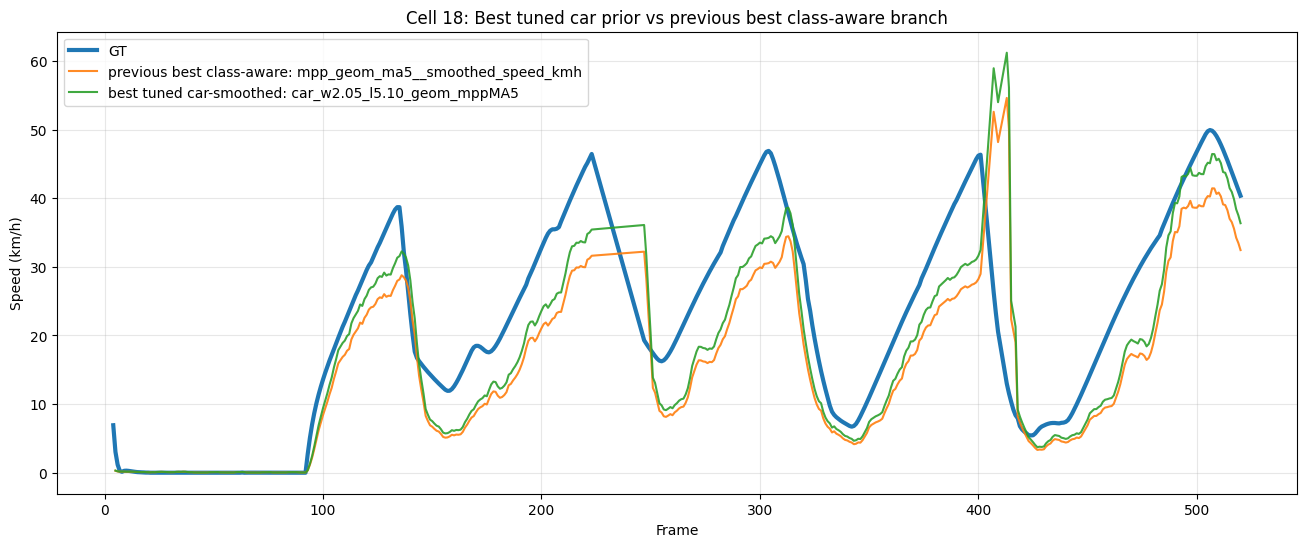

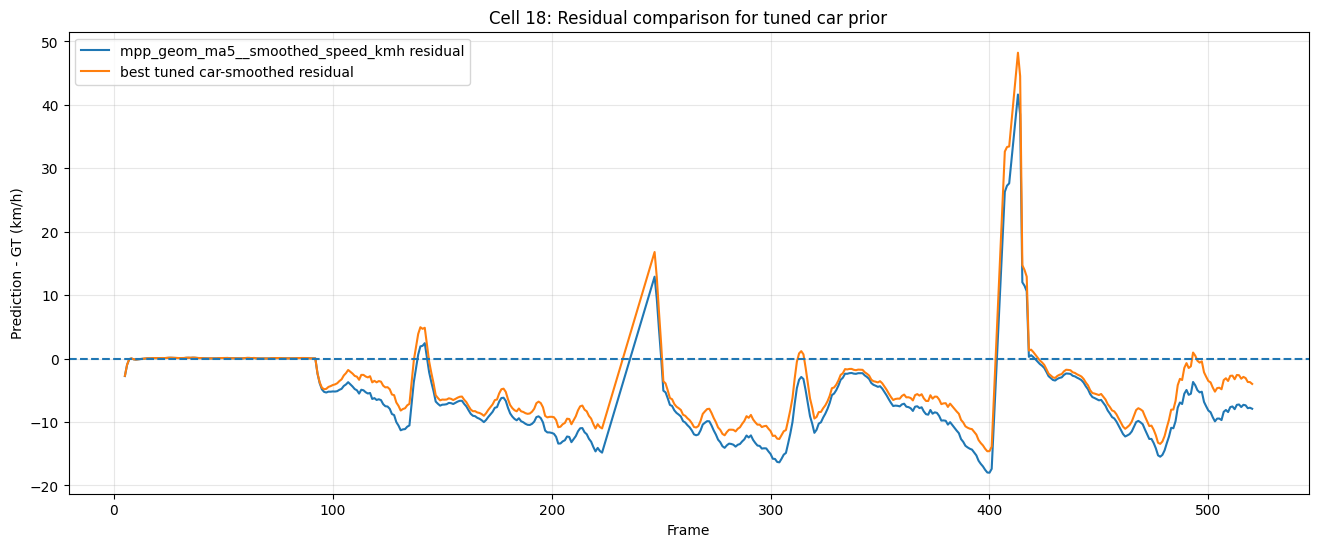


=== Saved best tuned car priors ===


,role,experiment,width_m,length_m,fusion,smooth_mpp,mae,rmse,bias,corr
0,best_car_raw,car_w2.05_l5.10_geom_mppMA5,2.05,5.1,geom,True,5.255842,9.205468,-4.327331,0.854481
1,best_car_smoothed,car_w2.05_l5.10_geom_mppMA5,2.05,5.1,geom,True,5.723852,7.769110,-4.449119,0.907005


In [21]:
# ============================================================
# Cell 18: Car-specific prior tuning for class-aware local-scale speed
# Goal:
# - stay focused only on the car class
# - tune car width / length priors directly
# - see whether the negative bias can be reduced without affine correction
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

assert "BEST_CLASS_LOCAL_COMPARE_DF" in globals(), "Run Cell 16 first."
assert "BEST_REFINED_CLASS_SCALE_COMPARE_DF" in globals(), "Run Cell 17 first."
assert "BEST_REFINED_CLASS_SCALE_SERIES" in globals(), "Run Cell 17 first."
assert "BEST_UPSTREAM_SMOOTHED_EXPERIMENT" in globals(), "Run Cell 11 first."
assert "local_all_obs" in globals(), "Run Cell 11 first."

# ------------------------------------------------------------
# 1) Recover the single-car dominant trajectory
# ------------------------------------------------------------
source_experiment = BEST_UPSTREAM_SMOOTHED_EXPERIMENT
source_obs_df = local_all_obs[source_experiment].copy()

track_counts = source_obs_df["track_id"].value_counts().sort_values(ascending=False)
assert len(track_counts) > 0, "No track IDs found in source observations."

dominant_track_id = int(track_counts.index[0])

traj_df = (
    source_obs_df[source_obs_df["track_id"] == dominant_track_id]
    .sort_values("frame_idx")
    .reset_index(drop=True)
)

assert len(traj_df) > 5, "Not enough trajectory points."

# Confirm this is really a car-only track
if "class_id" in traj_df.columns:
    class_counts = traj_df["class_id"].value_counts(dropna=False).sort_index()
    print("=== Dominant track class_id distribution ===")
    display(class_counts.to_frame("count"))

resolved_labels = traj_df["class_id"].map(lambda x: PHASE_CLASSES.get(int(x), "Other"))
print("\n=== Dominant track resolved class distribution ===")
display(resolved_labels.value_counts(dropna=False).to_frame("count"))

assert resolved_labels.nunique() == 1 and resolved_labels.iloc[0] == "Car", \
    "This cell is intended for the single-car case, but the dominant track is not purely Car."

gt_df = load_gt_csv(GT_CSV_PATH)

# ------------------------------------------------------------
# 2) FPS from video metadata
# ------------------------------------------------------------
cap = cv2.VideoCapture(str(VIDEO_PATH))
assert cap.isOpened(), f"Could not open video: {VIDEO_PATH}"
fps_from_video = cap.get(cv2.CAP_PROP_FPS)
cap.release()

if fps_from_video is None or not np.isfinite(fps_from_video) or fps_from_video <= 1:
    fps = DEFAULT_FPS
    fps_source = f"fallback DEFAULT_FPS={DEFAULT_FPS}"
else:
    fps = float(fps_from_video)
    fps_source = "video metadata"

print("\nFPS used:", fps, f"({fps_source})")

# ------------------------------------------------------------
# 3) Helper functions
# ------------------------------------------------------------
def moving_average_nan(values, window=5):
    out = np.full(len(values), np.nan, dtype=np.float64)
    for i in range(len(values)):
        lo = max(0, i - window + 1)
        vals = values[lo:i+1]
        vals = vals[np.isfinite(vals)]
        if len(vals) > 0:
            out[i] = np.mean(vals)
    return out

def safe_bbox_dims(box_row):
    w_px = float(box_row["bbox_x2"] - box_row["bbox_x1"])
    h_px = float(box_row["bbox_y2"] - box_row["bbox_y1"])
    return max(w_px, 1e-6), max(h_px, 1e-6)

def build_speed_from_scale_series(rep_x, rep_y, mpp_series, fps):
    out = np.full(len(rep_x), np.nan, dtype=np.float64)
    disp_px = np.full(len(rep_x), np.nan, dtype=np.float64)

    for i in range(1, len(rep_x)):
        dx = float(rep_x[i] - rep_x[i - 1])
        dy = float(rep_y[i] - rep_y[i - 1])
        dpx = float(np.sqrt(dx * dx + dy * dy))
        disp_px[i] = dpx

        if np.isfinite(mpp_series[i]) and np.isfinite(mpp_series[i - 1]):
            local_mpp = 0.5 * (mpp_series[i] + mpp_series[i - 1])
            speed_kmh = (dpx * local_mpp) * fps * 3.6
            if speed_kmh < MIN_REASONABLE_SPEED_KMH or speed_kmh > MAX_REASONABLE_SPEED_KMH:
                speed_kmh = np.nan
            out[i] = speed_kmh

    return out, disp_px

def compute_car_scale_series(df, width_m, length_m, fusion="geom", smooth_mpp=False, mpp_window=5):
    w_px = (df["bbox_x2"] - df["bbox_x1"]).to_numpy(dtype=np.float64)
    h_px = (df["bbox_y2"] - df["bbox_y1"]).to_numpy(dtype=np.float64)

    w_px = np.maximum(w_px, 1e-6)
    h_px = np.maximum(h_px, 1e-6)

    mpp_x = width_m / w_px
    mpp_y = length_m / h_px

    if fusion == "width_only":
        mpp = mpp_x
    elif fusion == "height_only":
        mpp = mpp_y
    elif fusion == "geom":
        mpp = np.sqrt(np.maximum(mpp_x, 1e-12) * np.maximum(mpp_y, 1e-12))
    elif fusion == "weighted_75w_25h":
        mpp = 0.75 * mpp_x + 0.25 * mpp_y
    elif fusion == "weighted_50w_50h":
        mpp = 0.50 * mpp_x + 0.50 * mpp_y
    else:
        raise ValueError(f"Unsupported fusion: {fusion}")

    if smooth_mpp:
        mpp = moving_average_nan(mpp, window=mpp_window)

    return mpp_x, mpp_y, mpp

# ------------------------------------------------------------
# 4) Build sweep over plausible car priors
# Keep this moderate and physically reasonable.
# ------------------------------------------------------------
car_width_grid_m = [1.75, 1.85, 1.95, 2.05]
car_length_grid_m = [4.20, 4.50, 4.80, 5.10]
fusion_grid = [
    "geom",
    "width_only",
    "height_only",
    "weighted_75w_25h",
]
smooth_mpp_grid = [False, True]

rep_x = traj_df["rep_image_x"].to_numpy(dtype=np.float64)
rep_y = traj_df["rep_image_y"].to_numpy(dtype=np.float64)

car_tuning_rows = []
car_candidate_store = {}

for width_m in car_width_grid_m:
    for length_m in car_length_grid_m:
        for fusion in fusion_grid:
            for smooth_mpp in smooth_mpp_grid:
                mpp_x, mpp_y, mpp = compute_car_scale_series(
                    traj_df,
                    width_m=width_m,
                    length_m=length_m,
                    fusion=fusion,
                    smooth_mpp=smooth_mpp,
                    mpp_window=5,
                )

                raw_speed, disp_px = build_speed_from_scale_series(rep_x, rep_y, mpp, fps=fps)
                smoothed_speed = moving_average_nan(raw_speed, window=5)

                exp_name = f"car_w{width_m:.2f}_l{length_m:.2f}_{fusion}_{'mppMA5' if smooth_mpp else 'noMppSmooth'}"

                candidate_df = pd.DataFrame({
                    "frame_idx": traj_df["frame_idx"].to_numpy(dtype=np.int64),
                    "car_tuned_raw_speed_kmh": raw_speed,
                    "car_tuned_smoothed_speed_kmh": smoothed_speed,
                    "car_tuned_disp_px": disp_px,
                    "car_tuned_mpp": mpp,
                    "car_tuned_mpp_x": mpp_x,
                    "car_tuned_mpp_y": mpp_y,
                })

                compare_df = gt_df.merge(candidate_df, on="frame_idx", how="inner")

                raw_metrics = compute_metrics(compare_df["gt_speed_kmh"], compare_df["car_tuned_raw_speed_kmh"])
                smooth_metrics = compute_metrics(compare_df["gt_speed_kmh"], compare_df["car_tuned_smoothed_speed_kmh"])

                car_tuning_rows.append({
                    "experiment": exp_name,
                    "width_m": width_m,
                    "length_m": length_m,
                    "fusion": fusion,
                    "smooth_mpp": smooth_mpp,
                    "series": "car_tuned_raw_speed_kmh",
                    **raw_metrics
                })
                car_tuning_rows.append({
                    "experiment": exp_name,
                    "width_m": width_m,
                    "length_m": length_m,
                    "fusion": fusion,
                    "smooth_mpp": smooth_mpp,
                    "series": "car_tuned_smoothed_speed_kmh",
                    **smooth_metrics
                })

                car_candidate_store[exp_name] = compare_df

# ------------------------------------------------------------
# 5) Results tables
# ------------------------------------------------------------
CAR_PRIOR_TUNING_DF = pd.DataFrame(car_tuning_rows)

CAR_TUNED_RAW_RANK_DF = (
    CAR_PRIOR_TUNING_DF[CAR_PRIOR_TUNING_DF["series"] == "car_tuned_raw_speed_kmh"]
    .sort_values(["rmse", "mae", "corr"], ascending=[True, True, False])
    .reset_index(drop=True)
)

CAR_TUNED_SMOOTH_RANK_DF = (
    CAR_PRIOR_TUNING_DF[CAR_PRIOR_TUNING_DF["series"] == "car_tuned_smoothed_speed_kmh"]
    .sort_values(["rmse", "mae", "corr"], ascending=[True, True, False])
    .reset_index(drop=True)
)

print("\n=== Car-prior tuning: RAW ranked ===")
display(CAR_TUNED_RAW_RANK_DF.head(15))

print("\n=== Car-prior tuning: SMOOTHED ranked ===")
display(CAR_TUNED_SMOOTH_RANK_DF.head(15))

best_car_raw_exp = CAR_TUNED_RAW_RANK_DF.iloc[0]["experiment"]
best_car_smooth_exp = CAR_TUNED_SMOOTH_RANK_DF.iloc[0]["experiment"]

print("\nBest tuned car RAW experiment     :", best_car_raw_exp)
print("Best tuned car SMOOTHED experiment:", best_car_smooth_exp)

# ------------------------------------------------------------
# 6) Compare best tuned car-smoothed vs previous best class-aware
# ------------------------------------------------------------
best_car_smooth_df = car_candidate_store[best_car_smooth_exp].copy()

baseline_compare_df = BEST_REFINED_CLASS_SCALE_COMPARE_DF.copy()
baseline_series = BEST_REFINED_CLASS_SCALE_SERIES

plt.figure(figsize=(16, 6))
plt.plot(best_car_smooth_df["frame_idx"], best_car_smooth_df["gt_speed_kmh"], label="GT", linewidth=3)
plt.plot(
    baseline_compare_df["frame_idx"],
    baseline_compare_df[baseline_series],
    label=f"previous best class-aware: {baseline_series}",
    alpha=0.9
)
plt.plot(
    best_car_smooth_df["frame_idx"],
    best_car_smooth_df["car_tuned_smoothed_speed_kmh"],
    label=f"best tuned car-smoothed: {best_car_smooth_exp}",
    alpha=0.9
)
plt.xlabel("Frame")
plt.ylabel("Speed (km/h)")
plt.title("Cell 18: Best tuned car prior vs previous best class-aware branch")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# ------------------------------------------------------------
# 7) Residual comparison
# ------------------------------------------------------------
plt.figure(figsize=(16, 6))
baseline_resid = baseline_compare_df[baseline_series] - baseline_compare_df["gt_speed_kmh"]
tuned_resid = best_car_smooth_df["car_tuned_smoothed_speed_kmh"] - best_car_smooth_df["gt_speed_kmh"]

plt.plot(baseline_compare_df["frame_idx"], baseline_resid, label=f"{baseline_series} residual")
plt.plot(best_car_smooth_df["frame_idx"], tuned_resid, label="best tuned car-smoothed residual")
plt.axhline(0.0, linestyle="--")
plt.xlabel("Frame")
plt.ylabel("Prediction - GT (km/h)")
plt.title("Cell 18: Residual comparison for tuned car prior")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# ------------------------------------------------------------
# 8) Save best tuned car branch for later notebook cells
# ------------------------------------------------------------
BEST_TUNED_CAR_RAW_EXPERIMENT = best_car_raw_exp
BEST_TUNED_CAR_SMOOTH_EXPERIMENT = best_car_smooth_exp
BEST_TUNED_CAR_COMPARE_DF = best_car_smooth_df.copy()

BEST_TUNED_CAR_SUMMARY_DF = pd.DataFrame([
    {
        "role": "best_car_raw",
        **CAR_TUNED_RAW_RANK_DF.iloc[0][["experiment", "width_m", "length_m", "fusion", "smooth_mpp", "mae", "rmse", "bias", "corr"]].to_dict()
    },
    {
        "role": "best_car_smoothed",
        **CAR_TUNED_SMOOTH_RANK_DF.iloc[0][["experiment", "width_m", "length_m", "fusion", "smooth_mpp", "mae", "rmse", "bias", "corr"]].to_dict()
    }
])

print("\n=== Saved best tuned car priors ===")
display(BEST_TUNED_CAR_SUMMARY_DF)

=== Car-prior zero-motion gate estimation ===
Low-disp quantile cutoff    : 1.391112 px
Low-disp median             : 0.013663 px
Low-disp MAD                : 0.008653 px
Disp noise floor (pixels)   : 0.039620 px

=== Tuned car branch: before vs after zero-motion gating ===


,series,count,mae,rmse,bias,corr
0,car_tuned_smoothed_speed_kmh,485,5.723852,7.769110,-4.449119,0.907005
1,car_tuned_smoothed_speed_zero_gated_kmh,485,5.716153,7.769142,-4.463030,0.907298



=== Tuned car branch subset metrics ===


,subset,series,count,mae,rmse,bias,corr
0,gt_stationary,car_tuned_smoothed_speed_kmh,86,0.066851,0.076204,0.055020,0.619979
1,gt_stationary,car_tuned_smoothed_speed_zero_gated_kmh,86,0.021069,0.059618,-0.021069,0.605755
2,gt_moving,car_tuned_smoothed_speed_kmh,399,6.943156,8.565485,-5.419936,0.860013
3,gt_moving,car_tuned_smoothed_speed_zero_gated_kmh,399,6.943665,8.565549,-5.420445,0.860035


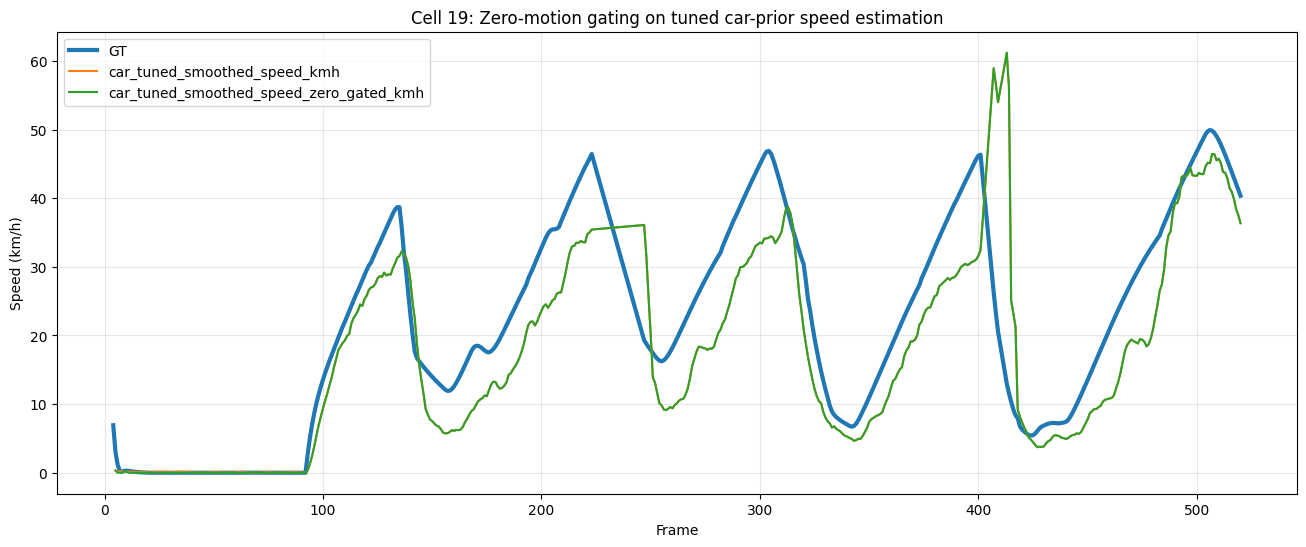

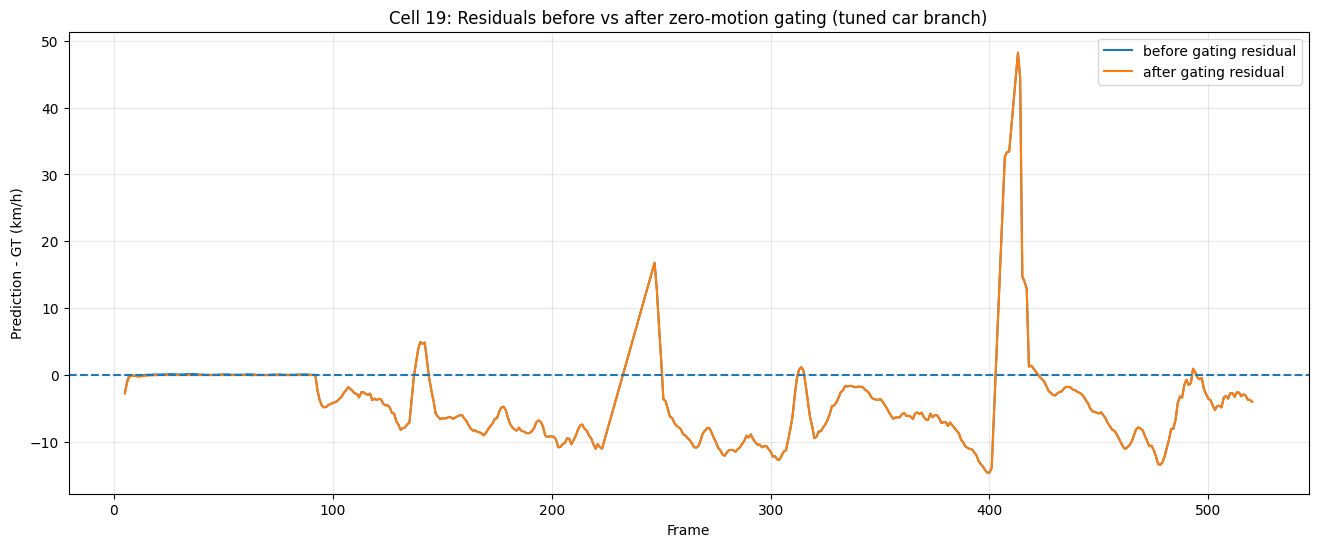


Saved for later cells:
BEST_TUNED_CAR_ZERO_GATED_SERIES = car_tuned_smoothed_speed_zero_gated_kmh
BEST_TUNED_CAR_ZERO_GATE_DISP_FLOOR_PX = 0.03962013664355622


In [22]:
# ============================================================
# Cell 19: Zero-motion gating for the best tuned car-prior branch
# Goal:
# - improve the tuned car-only estimator
# - force speed to 0 km/h when motion is indistinguishable from jitter
# - use a data-driven motion floor from image-space representative-point motion
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

assert "BEST_TUNED_CAR_COMPARE_DF" in globals(), "Run Cell 18 first."
assert "BEST_TUNED_CAR_SMOOTH_EXPERIMENT" in globals(), "Run Cell 18 first."

# ------------------------------------------------------------
# 1) Load best tuned car branch
# ------------------------------------------------------------
car_gated_df = BEST_TUNED_CAR_COMPARE_DF.copy()

assert "car_tuned_smoothed_speed_kmh" in car_gated_df.columns, \
    "Expected 'car_tuned_smoothed_speed_kmh' in BEST_TUNED_CAR_COMPARE_DF"

# Recover representative point trajectory from the source experiment
source_experiment = BEST_UPSTREAM_SMOOTHED_EXPERIMENT
source_obs_df = local_all_obs[source_experiment].copy()

track_counts = source_obs_df["track_id"].value_counts().sort_values(ascending=False)
assert len(track_counts) > 0, "No track IDs found in source observations."
dominant_track_id = int(track_counts.index[0])

traj_df = (
    source_obs_df[source_obs_df["track_id"] == dominant_track_id]
    .sort_values("frame_idx")
    .reset_index(drop=True)
)

# Merge rep points onto the tuned-car compare dataframe
car_gated_df = car_gated_df.merge(
    traj_df[["frame_idx", "rep_image_x", "rep_image_y"]],
    on="frame_idx",
    how="left"
)

assert car_gated_df["rep_image_x"].notna().sum() > 0, "Missing rep_image_x after merge."
assert car_gated_df["rep_image_y"].notna().sum() > 0, "Missing rep_image_y after merge."

# ------------------------------------------------------------
# 2) Compute image-space motion per frame
# We use image-space jitter
# ------------------------------------------------------------
rep_x = car_gated_df["rep_image_x"].to_numpy(dtype=np.float64)
rep_y = car_gated_df["rep_image_y"].to_numpy(dtype=np.float64)

disp_px = np.full(len(car_gated_df), np.nan, dtype=np.float64)
for i in range(1, len(car_gated_df)):
    dx = float(rep_x[i] - rep_x[i - 1])
    dy = float(rep_y[i] - rep_y[i - 1])
    disp_px[i] = float(np.sqrt(dx * dx + dy * dy))

car_gated_df["rep_disp_px"] = disp_px
car_gated_df["rep_disp_med3_px"] = (
    car_gated_df["rep_disp_px"]
    .rolling(window=3, min_periods=1, center=True)
    .median()
)

# ------------------------------------------------------------
# 3) Estimate an image-motion noise floor from the lowest-motion frames
# Data-driven, no hand-picked speed threshold.
# ------------------------------------------------------------
finite_disp = car_gated_df["rep_disp_px"].to_numpy(dtype=np.float64)
finite_disp = finite_disp[np.isfinite(finite_disp)]
assert len(finite_disp) > 0, "No finite representative-point displacements found."

low_q = np.quantile(finite_disp, 0.20)
low_disp = finite_disp[finite_disp <= low_q]

low_med = float(np.median(low_disp))
low_mad = float(np.median(np.abs(low_disp - low_med)))

disp_noise_floor_px = low_med + 3.0 * low_mad
if not np.isfinite(disp_noise_floor_px) or disp_noise_floor_px <= 0:
    disp_noise_floor_px = float(np.quantile(low_disp, 0.90))

print("=== Car-prior zero-motion gate estimation ===")
print(f"Low-disp quantile cutoff    : {low_q:.6f} px")
print(f"Low-disp median             : {low_med:.6f} px")
print(f"Low-disp MAD                : {low_mad:.6f} px")
print(f"Disp noise floor (pixels)   : {disp_noise_floor_px:.6f} px")
print("============================================")

# ------------------------------------------------------------
# 4) Build stationary mask
# ------------------------------------------------------------
car_gated_df["stationary_disp_mask"] = car_gated_df["rep_disp_med3_px"] <= disp_noise_floor_px

stationary_int = car_gated_df["stationary_disp_mask"].astype(np.int32)
car_gated_df["stationary_votes_3"] = (
    stationary_int.rolling(window=3, min_periods=1, center=True).sum()
)
car_gated_df["stationary_disp_mask_clean"] = car_gated_df["stationary_votes_3"] >= 2

# ------------------------------------------------------------
# 5) Apply zero-motion gating to tuned car smoothed speed
# ------------------------------------------------------------
car_gated_df["car_tuned_smoothed_speed_zero_gated_kmh"] = car_gated_df["car_tuned_smoothed_speed_kmh"].copy()
car_gated_df.loc[car_gated_df["stationary_disp_mask_clean"], "car_tuned_smoothed_speed_zero_gated_kmh"] = 0.0

# ------------------------------------------------------------
# 6) Metrics before vs after gating
# ------------------------------------------------------------
before_metrics = compute_metrics(
    car_gated_df["gt_speed_kmh"],
    car_gated_df["car_tuned_smoothed_speed_kmh"]
)

after_metrics = compute_metrics(
    car_gated_df["gt_speed_kmh"],
    car_gated_df["car_tuned_smoothed_speed_zero_gated_kmh"]
)

CAR_TUNED_ZERO_GATE_METRICS_DF = pd.DataFrame([
    {"series": "car_tuned_smoothed_speed_kmh", **before_metrics},
    {"series": "car_tuned_smoothed_speed_zero_gated_kmh", **after_metrics},
]).sort_values(["rmse", "mae"], ascending=[True, True]).reset_index(drop=True)

print("\n=== Tuned car branch: before vs after zero-motion gating ===")
display(CAR_TUNED_ZERO_GATE_METRICS_DF)

# ------------------------------------------------------------
# 7) Diagnostics on stationary GT frames
# Only for evaluation, not for the gating rule itself.
# ------------------------------------------------------------
stationary_gt_eval_threshold_kmh = 1.0

stationary_eval_df = car_gated_df[car_gated_df["gt_speed_kmh"] <= stationary_gt_eval_threshold_kmh].copy()
moving_eval_df = car_gated_df[car_gated_df["gt_speed_kmh"] > stationary_gt_eval_threshold_kmh].copy()

def eval_subset(df, pred_col, subset_name):
    m = compute_metrics(df["gt_speed_kmh"], df[pred_col])
    return {"subset": subset_name, "series": pred_col, **m}

CAR_TUNED_ZERO_GATE_SUBSET_DF = pd.DataFrame([
    eval_subset(stationary_eval_df, "car_tuned_smoothed_speed_kmh", "gt_stationary"),
    eval_subset(stationary_eval_df, "car_tuned_smoothed_speed_zero_gated_kmh", "gt_stationary"),
    eval_subset(moving_eval_df, "car_tuned_smoothed_speed_kmh", "gt_moving"),
    eval_subset(moving_eval_df, "car_tuned_smoothed_speed_zero_gated_kmh", "gt_moving"),
])

print("\n=== Tuned car branch subset metrics ===")
display(CAR_TUNED_ZERO_GATE_SUBSET_DF)

# ------------------------------------------------------------
# 8) Plot before vs after gating
# ------------------------------------------------------------
plt.figure(figsize=(16, 6))
plt.plot(car_gated_df["frame_idx"], car_gated_df["gt_speed_kmh"], label="GT", linewidth=3)
plt.plot(car_gated_df["frame_idx"], car_gated_df["car_tuned_smoothed_speed_kmh"], label="car_tuned_smoothed_speed_kmh")
plt.plot(car_gated_df["frame_idx"], car_gated_df["car_tuned_smoothed_speed_zero_gated_kmh"], label="car_tuned_smoothed_speed_zero_gated_kmh")
plt.xlabel("Frame")
plt.ylabel("Speed (km/h)")
plt.title("Cell 19: Zero-motion gating on tuned car-prior speed estimation")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# ------------------------------------------------------------
# 9) Residual comparison
# ------------------------------------------------------------
plt.figure(figsize=(16, 6))
plt.plot(
    car_gated_df["frame_idx"],
    car_gated_df["car_tuned_smoothed_speed_kmh"] - car_gated_df["gt_speed_kmh"],
    label="before gating residual"
)
plt.plot(
    car_gated_df["frame_idx"],
    car_gated_df["car_tuned_smoothed_speed_zero_gated_kmh"] - car_gated_df["gt_speed_kmh"],
    label="after gating residual"
)
plt.axhline(0.0, linestyle="--")
plt.xlabel("Frame")
plt.ylabel("Prediction - GT (km/h)")
plt.title("Cell 19: Residuals before vs after zero-motion gating (tuned car branch)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# ------------------------------------------------------------
# 10) Save outputs for later cells
# ------------------------------------------------------------
BEST_TUNED_CAR_ZERO_GATED_COMPARE_DF = car_gated_df.copy()
BEST_TUNED_CAR_ZERO_GATED_SERIES = "car_tuned_smoothed_speed_zero_gated_kmh"
BEST_TUNED_CAR_ZERO_GATE_DISP_FLOOR_PX = disp_noise_floor_px

print("\nSaved for later cells:")
print("BEST_TUNED_CAR_ZERO_GATED_SERIES =", BEST_TUNED_CAR_ZERO_GATED_SERIES)
print("BEST_TUNED_CAR_ZERO_GATE_DISP_FLOOR_PX =", BEST_TUNED_CAR_ZERO_GATE_DISP_FLOOR_PX)

# Locked-in speed estimation approach for live drone inference

## What we are doing now

We are moving away from a scene-specific, manually calibrated homography pipeline and toward a **live-inference style, class-aware speed estimator**.

This means the speed estimator should rely only on information that is realistically available at runtime on the drone:

1. **detected object class**
2. **tracked bounding boxes**
3. **representative image-point motion over time**
4. **object-size priors** (average physical dimensions by class)
5. **frame timing / FPS**

This avoids requiring manually clicked calibration points during deployment.

---

## How the current speed estimation works

For each tracked object:

1. We detect and classify the object.
2. We track it across frames.
3. We choose a representative point on the box, currently:
   - **bottom-center + small vertical offset**
4. We estimate local scale in **meters per pixel** using the object's class prior and bbox dimensions:
   - `mpp_x = class_width_m / bbox_width_px`
   - `mpp_y = class_length_m / bbox_height_px`
5. We combine these into a single local scale:
   - currently using the **geometric mean**
6. We smooth the local scale over time.
7. We measure representative-point displacement in pixels between frames.
8. We convert that displacement into meters:
   - `distance_m = displacement_px * local_mpp`
9. We compute speed:
   - `speed_kmh = distance_m / dt * 3.6`
10. We smooth the resulting speed.

---

## What dimensions are currently used

For cars, the current best version uses:

- **width**
- **length**

It does **not** currently use object height in the speed formula.

Height is still stored in the prior table for future experimentation, but it is not part of the current scale conversion.

---

## Why this is closer to live deployment

This approach is more deployment-friendly because it does **not** require:

- manual clicking
- scene-specific homography calibration
- affine correction fit to one video

Instead, it uses:

- detector output
- tracker output
- class priors
- temporal motion

That makes it much closer to what could realistically run on the drone in live inference.

---

## Current best practices we are locking in

### Representative point
- **bottom-center**
- with a small positive vertical offset

### Scale model
- class-aware local scale from bbox dimensions
- for cars, tuned prior:
  - width = **2.05 m**
  - length = **5.10 m**
- combine width-based and height-of-bbox-derived scale using:
  - **geometric mean**
- smooth meters-per-pixel over time

### Speed model
- compute speed from representative-point displacement over time
- smooth speed with a short moving average

---

## Note

This locked-in pipeline is currently best tuned for **cars**.

It still supports other classes through fallback priors, but those classes have not yet been optimized the same way cars have.

=== Live-Style Pipeline Environment ===
Python: 3.11.9
PyTorch: 2.5.1+cu121
CUDA available: False
CPU cores: 8
Checkpoint: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\models\infrared-training\dronevehicle_rfdetr_nano_best_ema.pth
Video: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\carla_rgb_speeds.mp4
Loading detector...
Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Loading pretrain weights
Detector ready.
FPS: 20.0 (video metadata)
Frames: 521
Frame size: 800x600


Live-style speed estimation:   0%|          | 0/521 [00:00<?, ?it/s]

Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().



=== Saved outputs ===
Annotated video: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\live_style_pipeline_outputs\live_style_speed_estimation.mp4
Observations CSV: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\personal_simulation\live_style_pipeline_outputs\live_style_speed_estimation_observations.csv

=== Class distribution in output ===


,count
canonical_label,
Car,486



=== Observation preview ===


,track_id,frame_idx,class_id,label,canonical_label,confidence,bbox_x1,bbox_y1,bbox_x2,bbox_y2,rep_image_x,rep_image_y,bbox_width_px,bbox_height_px,mpp_x,mpp_y,mpp_geom,mpp_smoothed,raw_speed_kmh,smoothed_speed_kmh
0,1,4,3,Car,Car,0.545935,360.362671,281.581848,441.133972,319.380188,400.748322,327.380188,80.771301,37.798340,0.025380,0.134927,0.058519,0.058519,NaN,NaN
1,1,5,3,Car,Car,0.644412,360.302826,281.607391,441.175140,319.454956,400.738983,327.454956,80.872314,37.847565,0.025349,0.134751,0.058444,0.058482,0.317372,0.317372
2,1,6,3,Car,Car,0.693534,360.242004,281.554932,441.197327,319.446503,400.719666,327.446503,80.955322,37.891571,0.025323,0.134595,0.058381,0.058448,0.088762,0.203067
3,1,7,3,Car,Car,0.708591,360.184784,281.540283,441.228394,319.479401,400.706604,327.479401,81.043610,37.939117,0.025295,0.134426,0.058312,0.058414,0.148912,0.185015
4,1,8,3,Car,Car,0.748485,360.148834,281.473999,441.263824,319.454163,400.706329,327.454163,81.114990,37.980164,0.025273,0.134281,0.058255,0.058382,0.106124,0.165292



=== Speed summary ===


,raw_speed_kmh,smoothed_speed_kmh,mpp_x,mpp_y,mpp_geom,mpp_smoothed
count,484.000000,485.000000,486.000000,486.000000,486.000000,486.000000
mean,16.874198,16.769002,0.026263,0.091960,0.048232,0.048252
std,14.993369,13.653997,0.004389,0.031195,0.008777,0.008630
min,0.002371,0.015563,0.017248,0.055220,0.033577,0.033759
25%,5.574730,5.470900,0.023746,0.061095,0.042362,0.042248
50%,14.082363,13.884633,0.025417,0.082158,0.046748,0.046958
75%,27.487730,27.565786,0.029202,0.130093,0.058295,0.058297
max,165.274597,61.206331,0.038315,0.139738,0.067540,0.065910


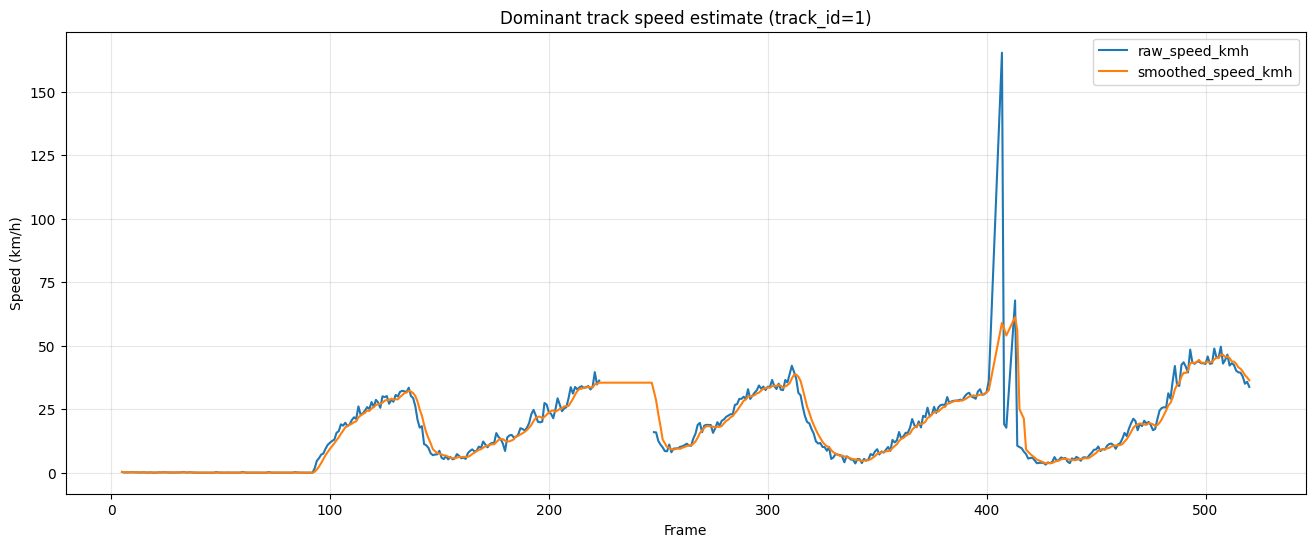

In [23]:
# ============================================================
# Final Locked-In Live-Style Inference + Speed Estimation Pipeline
# Purpose:
# - fully self-contained
# - no manual clicking
# - no homography
# - no affine correction
# - class-aware, bbox-scale-based speed estimation
# - tuned for cars, with fallback priors for other classes
# - takes a video and outputs:
#     1) annotated video
#     2) per-frame observations CSV
#
# Notes:
# - This is designed to resemble what live inference on the drone
#   would look like.
# - Car priors are tuned from experiments.
# - Other classes use reasonable fallback priors for now.
# ============================================================

# -----------------------------
# 0) Imports
# -----------------------------
import os
import sys
import json
import inspect
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import torch
from tqdm.auto import tqdm
import psutil

from rfdetr import RFDETRNano

try:
    import supervision as sv
    SUPERVISION_OK = True
except Exception as e:
    SUPERVISION_OK = False
    raise ImportError(f"supervision import failed: {repr(e)}")

# -----------------------------
# 1) Paths / config
# -----------------------------
PHASE_ROOT = Path.cwd().parent.parent

CKPT_PATH = PHASE_ROOT / "rfdetr" / "models" / "infrared-training" / "dronevehicle_rfdetr_nano_best_ema.pth"
VIDEO_PATH = PHASE_ROOT / "rfdetr" / "videos" / "personal_simulation" / "carla_rgb_speeds.mp4"

OUTPUT_DIR = PHASE_ROOT / "rfdetr" / "videos" / "personal_simulation" / "live_style_pipeline_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_VIDEO_PATH = OUTPUT_DIR / "live_style_speed_estimation.mp4"
OUTPUT_OBS_CSV_PATH = OUTPUT_DIR / "live_style_speed_estimation_observations.csv"

assert CKPT_PATH.exists(), f"Missing checkpoint: {CKPT_PATH}"
assert VIDEO_PATH.exists(), f"Missing video: {VIDEO_PATH}"

# -----------------------------
# 2) Class map
# -----------------------------
PHASE_CLASSES = {
    1: "Human",
    2: "Bicycle",
    3: "Car",
    4: "Truck",
    5: "Bus",
    6: "Other",
}

SPEED_ESTIMATION_CLASS_IDS = {1, 2, 3, 4, 5, 6}

# -----------------------------
# 3) Detection / tracking config
# -----------------------------
DET_THRESHOLD = 0.30
MIN_BOX_AREA = 30 * 30
DETECT_EVERY_N = 1

TRACK_THRESH = 0.30
TRACK_BUFFER = 30
MATCH_THRESH = 0.80
DEFAULT_FPS = 30.0

# -----------------------------
# 4) Locked-in class priors
# Car prior is tuned from experiments.
# Other classes are fallback priors for future live inference.
# -----------------------------
CLASS_DIMENSION_PRIORS = {
    "Human": {
        "width_m": 0.50,
        "length_m": 0.50,
        "height_m": 1.70,
        "rep_point_mode": "bottom_center",
        "rep_y_offset_px": 8.0,
    },
    "Bicycle": {
        "width_m": 0.60,
        "length_m": 1.80,
        "height_m": 1.10,
        "rep_point_mode": "bottom_center",
        "rep_y_offset_px": 8.0,
    },
    "Car": {
        "width_m": 2.05,   # tuned
        "length_m": 5.10,  # tuned
        "height_m": 1.50,
        "rep_point_mode": "bottom_center",
        "rep_y_offset_px": 8.0,
    },
    "Truck": {
        "width_m": 2.50,
        "length_m": 7.00,
        "height_m": 3.20,
        "rep_point_mode": "bottom_center",
        "rep_y_offset_px": 8.0,
    },
    "Bus": {
        "width_m": 2.55,
        "length_m": 12.00,
        "height_m": 3.20,
        "rep_point_mode": "bottom_center",
        "rep_y_offset_px": 8.0,
    },
    "Other": {
        "width_m": 2.00,
        "length_m": 4.50,
        "height_m": 1.80,
        "rep_point_mode": "bottom_center",
        "rep_y_offset_px": 8.0,
    },
}

CLASS_PRIOR_ALIASES = {
    "person": "Human",
    "pedestrian": "Human",
    "people": "Human",
    "bike": "Bicycle",
    "bicycle": "Bicycle",
    "cyclist": "Bicycle",
    "car": "Car",
    "sedan": "Car",
    "van": "Car",
    "suv": "Car",
    "pickup": "Car",
    "truck": "Truck",
    "lorry": "Truck",
    "semi": "Truck",
    "bus": "Bus",
    "coach": "Bus",
    "other": "Other",
    "motor": "Other",
    "vehicle": "Other",
}

# -----------------------------
# 5) Speed-estimation config
# -----------------------------
MIN_REASONABLE_SPEED_KMH = 0.0
MAX_REASONABLE_SPEED_KMH = 250.0
SPEED_WINDOW = 5
MPP_WINDOW = 5
BORDER_MARGIN_PX = 20

# -----------------------------
# 6) Environment print
# -----------------------------
print("=== Live-Style Pipeline Environment ===")
print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA version:", torch.version.cuda)
    print("GPU:", torch.cuda.get_device_name(0))
print("CPU cores:", psutil.cpu_count(logical=True))
print("Checkpoint:", CKPT_PATH)
print("Video:", VIDEO_PATH)
print("=======================================")

# -----------------------------
# 7) Helpers
# -----------------------------
def canonicalize_class_name(label: str) -> str:
    if label is None:
        return "Other"
    label = str(label).strip()
    if label in CLASS_DIMENSION_PRIORS:
        return label
    lowered = label.lower()
    if lowered in CLASS_PRIOR_ALIASES:
        return CLASS_PRIOR_ALIASES[lowered]
    return "Other"

def get_class_dimension_prior(label: str) -> dict:
    canonical = canonicalize_class_name(label)
    prior = CLASS_DIMENSION_PRIORS[canonical].copy()
    prior["canonical_label"] = canonical
    prior["requested_label"] = label
    return prior

def rfdetr_to_sv_detections(det, min_conf=0.30):
    xyxy = np.asarray(det.xyxy, dtype=np.float32)
    conf = np.asarray(det.confidence, dtype=np.float32)
    cls = np.asarray(det.class_id, dtype=np.int32)

    keep = conf >= float(min_conf)
    return sv.Detections(
        xyxy=xyxy[keep],
        confidence=conf[keep],
        class_id=cls[keep]
    )

def bbox_center_xyxy(box_xyxy):
    x1, y1, x2, y2 = map(float, box_xyxy)
    return np.array([(x1 + x2) / 2.0, (y1 + y2) / 2.0], dtype=np.float32)

def bbox_bottom_center_xyxy(box_xyxy, y_offset_px=0.0):
    x1, y1, x2, y2 = map(float, box_xyxy)
    cx = 0.5 * (x1 + x2)
    cy = y2 + float(y_offset_px)
    return np.array([cx, cy], dtype=np.float32)

def representative_point_xyxy(box_xyxy, class_label):
    prior = get_class_dimension_prior(class_label)
    mode = prior["rep_point_mode"]
    y_offset_px = prior["rep_y_offset_px"]

    if mode == "center":
        return bbox_center_xyxy(box_xyxy)
    elif mode == "bottom_center":
        return bbox_bottom_center_xyxy(box_xyxy, y_offset_px=y_offset_px)
    else:
        raise ValueError(f"Unsupported representative point mode: {mode}")

def bbox_touches_border(box_xyxy, image_width, image_height, margin_px=20):
    x1, y1, x2, y2 = map(float, box_xyxy)
    return (
        x1 <= margin_px or
        y1 <= margin_px or
        x2 >= (image_width - margin_px) or
        y2 >= (image_height - margin_px)
    )

def moving_average_ignore_none(values, window=5):
    recent = [float(v) for v in values if v is not None]
    if len(recent) == 0:
        return None
    recent = recent[-int(window):]
    return float(np.mean(recent))

def moving_average_nan(values, window=5):
    out = np.full(len(values), np.nan, dtype=np.float64)
    for i in range(len(values)):
        lo = max(0, i - window + 1)
        vals = values[lo:i+1]
        vals = vals[np.isfinite(vals)]
        if len(vals) > 0:
            out[i] = np.mean(vals)
    return out

def is_reasonable_speed_kmh(speed_kmh, min_kmh=0.0, max_kmh=250.0):
    if speed_kmh is None:
        return False
    return float(min_kmh) <= float(speed_kmh) <= float(max_kmh)

def build_tracker(frame_rate):
    sig = inspect.signature(sv.ByteTrack.__init__)
    params = set(sig.parameters.keys())
    kwargs = {}

    if "track_activation_threshold" in params:
        kwargs["track_activation_threshold"] = TRACK_THRESH
    if "lost_track_buffer" in params:
        kwargs["lost_track_buffer"] = TRACK_BUFFER
    if "minimum_matching_threshold" in params:
        kwargs["minimum_matching_threshold"] = MATCH_THRESH
    if "frame_rate" in params:
        kwargs["frame_rate"] = int(round(frame_rate))

    if "track_thresh" in params:
        kwargs["track_thresh"] = TRACK_THRESH
    if "track_buffer" in params:
        kwargs["track_buffer"] = TRACK_BUFFER
    if "match_thresh" in params:
        kwargs["match_thresh"] = MATCH_THRESH

    try:
        tracker = sv.ByteTrack(**kwargs)
    except TypeError:
        tracker = sv.ByteTrack()

    if hasattr(tracker, "reset"):
        tracker.reset()

    return tracker

def make_empty_track_history():
    return {
        "frames": [],
        "boxes": [],
        "labels": [],
        "confidences": [],
        "image_points": [],
        "mpp_x": [],
        "mpp_y": [],
        "mpp_geom": [],
        "mpp_smoothed": [],
        "raw_speeds_kmh": [],
        "smoothed_speeds_kmh": [],
    }

def safe_bbox_dims(box_xyxy):
    x1, y1, x2, y2 = map(float, box_xyxy)
    w_px = max(float(x2 - x1), 1e-6)
    h_px = max(float(y2 - y1), 1e-6)
    return w_px, h_px

def compute_local_scale_from_box(box_xyxy, class_label):
    prior = get_class_dimension_prior(class_label)
    width_m = float(prior["width_m"])
    length_m = float(prior["length_m"])

    bbox_w_px, bbox_h_px = safe_bbox_dims(box_xyxy)

    mpp_x = width_m / bbox_w_px
    mpp_y = length_m / bbox_h_px
    mpp_geom = float(np.sqrt(max(mpp_x, 1e-12) * max(mpp_y, 1e-12)))

    return {
        "canonical_label": prior["canonical_label"],
        "width_m": width_m,
        "length_m": length_m,
        "bbox_width_px": bbox_w_px,
        "bbox_height_px": bbox_h_px,
        "mpp_x": mpp_x,
        "mpp_y": mpp_y,
        "mpp_geom": mpp_geom,
    }

def append_track_observation(track_history, frame_idx, box_xyxy, class_label, confidence, fps):
    rep_pt = representative_point_xyxy(box_xyxy, class_label)
    scale_info = compute_local_scale_from_box(box_xyxy, class_label)

    track_history["frames"].append(int(frame_idx))
    track_history["boxes"].append(np.asarray(box_xyxy, dtype=np.float32))
    track_history["labels"].append(class_label)
    track_history["confidences"].append(float(confidence))
    track_history["image_points"].append(rep_pt)

    track_history["mpp_x"].append(scale_info["mpp_x"])
    track_history["mpp_y"].append(scale_info["mpp_y"])
    track_history["mpp_geom"].append(scale_info["mpp_geom"])

    mpp_smoothed_arr = moving_average_nan(np.asarray(track_history["mpp_geom"], dtype=np.float64), window=MPP_WINDOW)
    current_mpp_smoothed = float(mpp_smoothed_arr[-1]) if np.isfinite(mpp_smoothed_arr[-1]) else None
    track_history["mpp_smoothed"].append(current_mpp_smoothed)

    raw_speed_kmh = None
    if len(track_history["image_points"]) >= 2:
        p1 = np.asarray(track_history["image_points"][-2], dtype=np.float64)
        p2 = np.asarray(track_history["image_points"][-1], dtype=np.float64)

        dx = float(p2[0] - p1[0])
        dy = float(p2[1] - p1[1])
        disp_px = float(np.sqrt(dx * dx + dy * dy))

        prev_mpp = track_history["mpp_smoothed"][-2]
        curr_mpp = track_history["mpp_smoothed"][-1]

        if prev_mpp is not None and curr_mpp is not None:
            local_mpp = 0.5 * (float(prev_mpp) + float(curr_mpp))
            dt = 1.0 / float(fps)
            raw_speed_kmh = (disp_px * local_mpp / dt) * 3.6

            if not is_reasonable_speed_kmh(
                raw_speed_kmh,
                min_kmh=MIN_REASONABLE_SPEED_KMH,
                max_kmh=MAX_REASONABLE_SPEED_KMH,
            ):
                raw_speed_kmh = None

    track_history["raw_speeds_kmh"].append(raw_speed_kmh)

    smoothed_speed_kmh = moving_average_ignore_none(
        track_history["raw_speeds_kmh"],
        window=SPEED_WINDOW
    )
    track_history["smoothed_speeds_kmh"].append(smoothed_speed_kmh)

    return {
        "rep_pt": rep_pt,
        "scale_info": scale_info,
        "raw_speed_kmh": raw_speed_kmh,
        "smoothed_speed_kmh": smoothed_speed_kmh,
    }

def active_tracks_to_boxes_and_ids(tracker):
    tracks = getattr(tracker, "tracked_tracks", [])
    boxes, ids = [], []
    for t in tracks:
        boxes.append(np.array(t.tlbr, dtype=np.float32))
        ids.append(int(t.external_track_id))
    return boxes, ids

# -----------------------------
# 8) Load model
# -----------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Loading detector...")
DETECTOR = RFDETRNano(pretrain_weights=str(CKPT_PATH))
DETECTOR.model.model.to(device)
DETECTOR.model.model.eval()
print("Detector ready.")

# -----------------------------
# 9) Open video and tracker
# -----------------------------
cap = cv2.VideoCapture(str(VIDEO_PATH))
assert cap.isOpened(), f"Could not open video: {VIDEO_PATH}"

fps = cap.get(cv2.CAP_PROP_FPS)
if fps is None or not np.isfinite(fps) or fps <= 1:
    fps = DEFAULT_FPS
    fps_source = f"fallback DEFAULT_FPS={DEFAULT_FPS}"
else:
    fps = float(fps)
    fps_source = "video metadata"

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

TRACKER = build_tracker(frame_rate=fps)

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(str(OUTPUT_VIDEO_PATH), fourcc, fps, (width, height))
assert writer.isOpened(), f"Could not open writer: {OUTPUT_VIDEO_PATH}"

print(f"FPS: {fps} ({fps_source})")
print(f"Frames: {total_frames}")
print(f"Frame size: {width}x{height}")

# -----------------------------
# 10) Main loop
# -----------------------------
track_histories = {}
track_meta = {}
output_rows = []

temp_infer_path = OUTPUT_DIR / "_temp_live_style_frame.jpg"

pbar = tqdm(total=total_frames, desc="Live-style speed estimation")

for frame_idx in range(total_frames):
    ok, frame_bgr = cap.read()
    if not ok:
        break

    # Detection
    if frame_idx % DETECT_EVERY_N == 0:
        ok_write = cv2.imwrite(str(temp_infer_path), frame_bgr)
        assert ok_write, f"Failed to write temp inference image: {temp_infer_path}"

        det = DETECTOR.predict(str(temp_infer_path), threshold=DET_THRESHOLD)
        detections = rfdetr_to_sv_detections(det, min_conf=DET_THRESHOLD)

        if len(detections) > 0:
            xyxy = detections.xyxy
            areas = (xyxy[:, 2] - xyxy[:, 0]) * (xyxy[:, 3] - xyxy[:, 1])
            keep = areas >= MIN_BOX_AREA
            detections = detections[keep]

        det_with_ids = TRACKER.update_with_detections(detections)

        if len(det_with_ids) > 0 and getattr(det_with_ids, "tracker_id", None) is not None:
            for i in range(len(det_with_ids)):
                tid = int(det_with_ids.tracker_id[i])
                cls = int(det_with_ids.class_id[i])
                conf = float(det_with_ids.confidence[i])
                label = PHASE_CLASSES.get(cls, "Other")
                track_meta[tid] = (cls, label, conf)
    else:
        empty_dets = sv.Detections(
            xyxy=np.zeros((0, 4), dtype=np.float32),
            confidence=np.zeros((0,), dtype=np.float32),
            class_id=np.zeros((0,), dtype=np.int32),
        )
        _ = TRACKER.update_with_detections(empty_dets)

    boxes, ids = active_tracks_to_boxes_and_ids(TRACKER)
    out = frame_bgr.copy()

    for box, tid in zip(boxes, ids):
        cls, label, conf = track_meta.get(tid, (-1, "Other", 0.0))

        if cls not in SPEED_ESTIMATION_CLASS_IDS:
            continue

        if bbox_touches_border(box, width, height, margin_px=BORDER_MARGIN_PX):
            continue

        if tid not in track_histories:
            track_histories[tid] = make_empty_track_history()

        result = append_track_observation(
            track_history=track_histories[tid],
            frame_idx=frame_idx,
            box_xyxy=box,
            class_label=label,
            confidence=conf,
            fps=fps,
        )

        rep_pt = result["rep_pt"]
        scale_info = result["scale_info"]
        raw_speed = result["raw_speed_kmh"]
        smooth_speed = result["smoothed_speed_kmh"]

        # Save observation row
        output_rows.append({
            "track_id": int(tid),
            "frame_idx": int(frame_idx),
            "class_id": int(cls),
            "label": label,
            "canonical_label": scale_info["canonical_label"],
            "confidence": float(conf),

            "bbox_x1": float(box[0]),
            "bbox_y1": float(box[1]),
            "bbox_x2": float(box[2]),
            "bbox_y2": float(box[3]),

            "rep_image_x": float(rep_pt[0]),
            "rep_image_y": float(rep_pt[1]),

            "bbox_width_px": float(scale_info["bbox_width_px"]),
            "bbox_height_px": float(scale_info["bbox_height_px"]),
            "mpp_x": float(scale_info["mpp_x"]),
            "mpp_y": float(scale_info["mpp_y"]),
            "mpp_geom": float(scale_info["mpp_geom"]),
            "mpp_smoothed": track_histories[tid]["mpp_smoothed"][-1],

            "raw_speed_kmh": raw_speed,
            "smoothed_speed_kmh": smooth_speed,
        })

        # Draw bbox
        x1, y1, x2, y2 = map(int, np.round(box))
        cv2.rectangle(out, (x1, y1), (x2, y2), (0, 255, 0), 2)

        # Draw representative point
        rep_x, rep_y = map(int, np.round(rep_pt))
        cv2.circle(out, (rep_x, rep_y), 4, (0, 0, 255), -1)

        # Draw trail
        pts = np.array(track_histories[tid]["image_points"][-20:], dtype=np.float32)
        if len(pts) >= 2:
            pts = np.round(pts).astype(int)
            for j in range(1, len(pts)):
                cv2.line(out, tuple(pts[j - 1]), tuple(pts[j]), (255, 0, 0), 2, cv2.LINE_AA)

        # Label text
        text = f"ID {tid}: {label} {conf:.2f}"
        if smooth_speed is not None:
            text += f" | {smooth_speed:.2f} km/h"

        cv2.putText(
            out,
            text,
            (x1, max(0, y1 - 6)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 255, 0),
            1,
            cv2.LINE_AA,
        )

    writer.write(out)
    pbar.update(1)

pbar.close()
cap.release()
writer.release()

if temp_infer_path.exists():
    try:
        temp_infer_path.unlink()
    except Exception:
        pass

# -----------------------------
# 11) Save observations
# -----------------------------
obs_df = pd.DataFrame(output_rows)
assert len(obs_df) > 0, "No observations collected."

obs_df.to_csv(OUTPUT_OBS_CSV_PATH, index=False)

# -----------------------------
# 12) Summary and preview
# -----------------------------
print("\n=== Saved outputs ===")
print("Annotated video:", OUTPUT_VIDEO_PATH)
print("Observations CSV:", OUTPUT_OBS_CSV_PATH)

print("\n=== Class distribution in output ===")
display(obs_df["canonical_label"].value_counts().to_frame("count"))

print("\n=== Observation preview ===")
display(obs_df.head())

print("\n=== Speed summary ===")
display(
    obs_df[["raw_speed_kmh", "smoothed_speed_kmh", "mpp_x", "mpp_y", "mpp_geom", "mpp_smoothed"]].describe()
)

# -----------------------------
# 13) Optional dominant-track plot
# -----------------------------
dominant_track_id = int(obs_df["track_id"].value_counts().index[0])
dominant_df = obs_df[obs_df["track_id"] == dominant_track_id].sort_values("frame_idx").reset_index(drop=True)

plt.figure(figsize=(16, 6))
plt.plot(dominant_df["frame_idx"], dominant_df["raw_speed_kmh"], label="raw_speed_kmh")
plt.plot(dominant_df["frame_idx"], dominant_df["smoothed_speed_kmh"], label="smoothed_speed_kmh")
plt.xlabel("Frame")
plt.ylabel("Speed (km/h)")
plt.title(f"Dominant track speed estimate (track_id={dominant_track_id})")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

=== Live-Style Pipeline Environment ===
Python: 3.11.9
PyTorch: 2.5.1+cu121
CUDA available: False
CPU cores: 8
Checkpoint: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\models\enhanced-training\visdrone_rfdetr_nano_best_ema.pth
Video: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\roundabout_closeup_2.mp4
Loading detector...
Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Loading pretrain weights
Detector ready.
FPS: 30.0 (video metadata)
Frames: 521
Frame size: 3840x2160


Live-style speed estimation:   0%|          | 0/521 [00:00<?, ?it/s]

Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().



=== Saved outputs ===
Annotated video: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\live_style_pipeline_outputs\roundabout_closeup_2\live_style_speed_estimation.mp4
Observations CSV: C:\Users\apraka01\projects\object-identification-uav-camera\phase-3\rfdetr\videos\live_style_pipeline_outputs\roundabout_closeup_2\live_style_speed_estimation_observations.csv

=== Class distribution in output ===


,count
canonical_label,
Car,830
Truck,42



=== Observation preview ===


,track_id,frame_idx,class_id,label,canonical_label,confidence,bbox_x1,bbox_y1,bbox_x2,bbox_y2,bbox_width_px,bbox_height_px,mpp_x,mpp_y,mpp_geom,mpp_smoothed,raw_speed_kmh,smoothed_speed_kmh
0,1,3,3,Car,Car,0.939810,477.171173,430.971405,1035.584717,731.653809,558.413544,300.682404,0.003671,0.016961,0.007891,0.007891,NaN,NaN
1,1,4,3,Car,Car,0.942358,454.360352,434.136047,1017.068237,737.228638,562.707886,303.092590,0.003643,0.016827,0.007829,0.007860,18.204147,18.204147
2,1,5,3,Car,Car,0.935555,422.870239,434.491425,998.284485,744.868713,575.414246,310.377289,0.003563,0.016432,0.007651,0.007791,22.203802,20.203974
3,1,6,3,Car,Car,0.942298,394.955475,437.029388,979.836060,753.185852,584.880585,316.156464,0.003505,0.016131,0.007519,0.007723,20.631686,20.346545
4,1,7,3,Car,Car,0.950945,367.309875,440.182281,959.626526,761.216980,592.316650,321.034698,0.003461,0.015886,0.007415,0.007661,20.967125,20.501690



=== Speed summary ===


,raw_speed_kmh,smoothed_speed_kmh,mpp_x,mpp_y,mpp_geom,mpp_smoothed
count,854.000000,854.000000,872.000000,872.000000,872.000000,872.000000
mean,18.225432,18.115976,0.003805,0.014466,0.007324,0.007298
std,5.961431,4.232629,0.000601,0.003673,0.001010,0.000973
min,2.963270,4.712091,0.002310,0.008450,0.004772,0.004772
25%,15.637268,15.777259,0.003390,0.011464,0.006618,0.006620
50%,18.339301,18.549594,0.003695,0.014248,0.007241,0.007242
75%,20.396035,20.108719,0.004027,0.017471,0.008025,0.008045
max,134.883233,42.038910,0.007217,0.026133,0.011374,0.011031


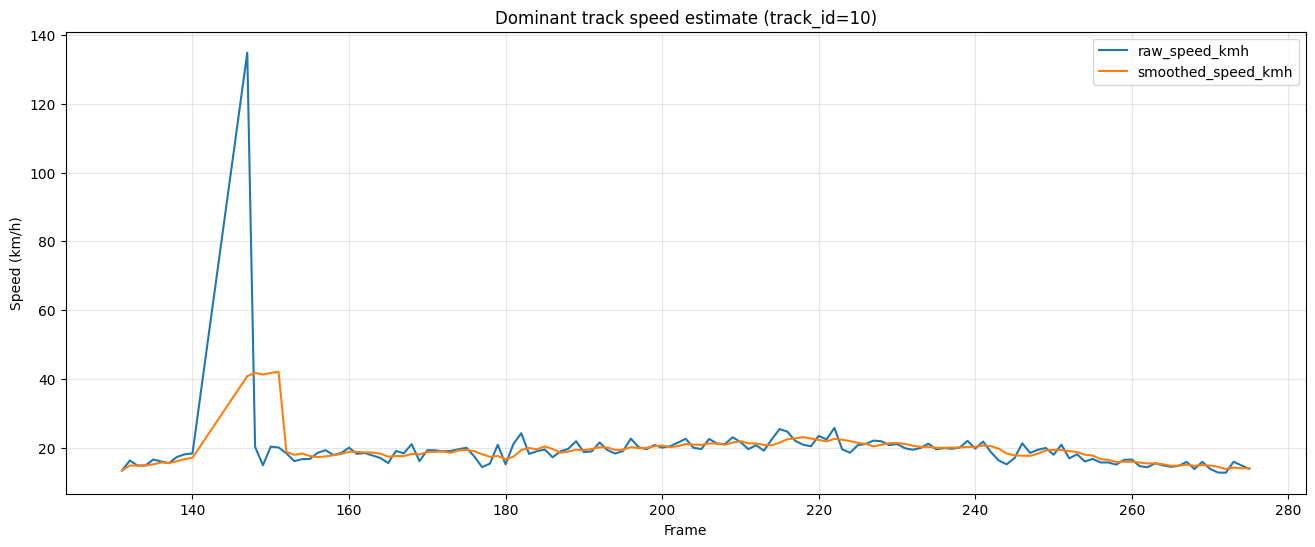

In [37]:
# ============================================================
# BONUS (updated: bbox + speed text only)
# ============================================================

# -----------------------------
# 0) Imports
# -----------------------------
import os
import sys
import json
import inspect
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import torch
from tqdm.auto import tqdm
import psutil

from rfdetr import RFDETRNano

try:
    import supervision as sv
    SUPERVISION_OK = True
except Exception as e:
    SUPERVISION_OK = False
    raise ImportError(f"supervision import failed: {repr(e)}")

# -----------------------------
# 1) Paths / config
# -----------------------------
PHASE_ROOT = Path.cwd().parent.parent

# CKPT_PATH = PHASE_ROOT / "rfdetr" / "models" / "infrared-training" / "dronevehicle_rfdetr_nano_best_ema.pth"
CKPT_PATH = PHASE_ROOT / "rfdetr" / "models" / "enhanced-training" / "visdrone_rfdetr_nano_best_ema.pth"
# VIDEO_PATH = PHASE_ROOT / "rfdetr" / "videos" / "custom_video.mp4"
# VIDEO_PATH = PHASE_ROOT / "rfdetr" / "videos" / "roundabout_speed.mp4"
# VIDEO_PATH = PHASE_ROOT / "rfdetr" / "videos" / "roundabout_closeup.mp4"
# VIDEO_PATH = PHASE_ROOT / "rfdetr" / "videos" / "roundabout_closeup_1.mp4"
VIDEO_PATH = PHASE_ROOT / "rfdetr" / "videos" / "roundabout_closeup_2.mp4"
# VIDEO_PATH = PHASE_ROOT / "rfdetr" / "videos" / "birds_eye_stationary_cam.mp4"

# OUTPUT_DIR = PHASE_ROOT / "rfdetr" / "videos" / "live_style_pipeline_outputs"
# OUTPUT_DIR = PHASE_ROOT / "rfdetr" / "videos" / "live_style_pipeline_outputs" / "roundabout_speed"
# OUTPUT_DIR = PHASE_ROOT / "rfdetr" / "videos" / "live_style_pipeline_outputs" / "roundabout_closeup"
# OUTPUT_DIR = PHASE_ROOT / "rfdetr" / "videos" / "live_style_pipeline_outputs" / "roundabout_closeup_1"
OUTPUT_DIR = PHASE_ROOT / "rfdetr" / "videos" / "live_style_pipeline_outputs" / "roundabout_closeup_2"
# OUTPUT_DIR = PHASE_ROOT / "rfdetr" / "videos" / "live_style_pipeline_outputs" / "birds_eye_stationary_cam"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_VIDEO_PATH = OUTPUT_DIR / "live_style_speed_estimation.mp4"
OUTPUT_OBS_CSV_PATH = OUTPUT_DIR / "live_style_speed_estimation_observations.csv"

assert CKPT_PATH.exists(), f"Missing checkpoint: {CKPT_PATH}"
assert VIDEO_PATH.exists(), f"Missing video: {VIDEO_PATH}"

# -----------------------------
# 2) Class map
# -----------------------------
PHASE_CLASSES = {
    1: "Human",
    2: "Bicycle",
    3: "Car",
    4: "Truck",
    5: "Bus",
    6: "Other",
}

SPEED_ESTIMATION_CLASS_IDS = {1, 2, 3, 4, 5, 6}

# -----------------------------
# 3) Detection / tracking config
# -----------------------------
DET_THRESHOLD = 0.30
MIN_BOX_AREA = 30 * 30
DETECT_EVERY_N = 1

TRACK_THRESH = 0.30
TRACK_BUFFER = 30
MATCH_THRESH = 0.80
DEFAULT_FPS = 30.0

# -----------------------------
# 4) Locked-in class priors
# -----------------------------
CLASS_DIMENSION_PRIORS = {
    "Human": {
        "width_m": 0.50,
        "length_m": 0.50,
        "height_m": 1.70,
        "rep_point_mode": "bottom_center",
        "rep_y_offset_px": 8.0,
    },
    "Bicycle": {
        "width_m": 0.60,
        "length_m": 1.80,
        "height_m": 1.10,
        "rep_point_mode": "bottom_center",
        "rep_y_offset_px": 8.0,
    },
    "Car": {
        "width_m": 2.05,
        "length_m": 5.10,
        "height_m": 1.50,
        "rep_point_mode": "bottom_center",
        "rep_y_offset_px": 8.0,
    },
    "Truck": {
        "width_m": 2.50,
        "length_m": 7.00,
        "height_m": 3.20,
        "rep_point_mode": "bottom_center",
        "rep_y_offset_px": 8.0,
    },
    "Bus": {
        "width_m": 2.55,
        "length_m": 12.00,
        "height_m": 3.20,
        "rep_point_mode": "bottom_center",
        "rep_y_offset_px": 8.0,
    },
    "Other": {
        "width_m": 2.00,
        "length_m": 4.50,
        "height_m": 1.80,
        "rep_point_mode": "bottom_center",
        "rep_y_offset_px": 8.0,
    },
}

CLASS_PRIOR_ALIASES = {
    "person": "Human",
    "pedestrian": "Human",
    "people": "Human",
    "bike": "Bicycle",
    "bicycle": "Bicycle",
    "cyclist": "Bicycle",
    "car": "Car",
    "sedan": "Car",
    "van": "Car",
    "suv": "Car",
    "pickup": "Car",
    "truck": "Truck",
    "lorry": "Truck",
    "semi": "Truck",
    "bus": "Bus",
    "coach": "Bus",
    "other": "Other",
    "motor": "Other",
    "vehicle": "Other",
}

# -----------------------------
# 5) Speed-estimation config
# -----------------------------
MIN_REASONABLE_SPEED_KMH = 0.0
MAX_REASONABLE_SPEED_KMH = 250.0
SPEED_WINDOW = 5
MPP_WINDOW = 5
BORDER_MARGIN_PX = 20

# -----------------------------
# 6) Environment print
# -----------------------------
print("=== Live-Style Pipeline Environment ===")
print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA version:", torch.version.cuda)
    print("GPU:", torch.cuda.get_device_name(0))
print("CPU cores:", psutil.cpu_count(logical=True))
print("Checkpoint:", CKPT_PATH)
print("Video:", VIDEO_PATH)
print("=======================================")

# -----------------------------
# 7) Helpers
# -----------------------------
def canonicalize_class_name(label: str) -> str:
    if label is None:
        return "Other"
    label = str(label).strip()
    if label in CLASS_DIMENSION_PRIORS:
        return label
    lowered = label.lower()
    if lowered in CLASS_PRIOR_ALIASES:
        return CLASS_PRIOR_ALIASES[lowered]
    return "Other"

def get_class_dimension_prior(label: str) -> dict:
    canonical = canonicalize_class_name(label)
    prior = CLASS_DIMENSION_PRIORS[canonical].copy()
    prior["canonical_label"] = canonical
    prior["requested_label"] = label
    return prior

def rfdetr_to_sv_detections(det, min_conf=0.30):
    xyxy = np.asarray(det.xyxy, dtype=np.float32)
    conf = np.asarray(det.confidence, dtype=np.float32)
    cls = np.asarray(det.class_id, dtype=np.int32)

    keep = conf >= float(min_conf)
    return sv.Detections(
        xyxy=xyxy[keep],
        confidence=conf[keep],
        class_id=cls[keep]
    )

def bbox_center_xyxy(box_xyxy):
    x1, y1, x2, y2 = map(float, box_xyxy)
    return np.array([(x1 + x2) / 2.0, (y1 + y2) / 2.0], dtype=np.float32)

def bbox_bottom_center_xyxy(box_xyxy, y_offset_px=0.0):
    x1, y1, x2, y2 = map(float, box_xyxy)
    cx = 0.5 * (x1 + x2)
    cy = y2 + float(y_offset_px)
    return np.array([cx, cy], dtype=np.float32)

def representative_point_xyxy(box_xyxy, class_label):
    prior = get_class_dimension_prior(class_label)
    mode = prior["rep_point_mode"]
    y_offset_px = prior["rep_y_offset_px"]

    if mode == "center":
        return bbox_center_xyxy(box_xyxy)
    elif mode == "bottom_center":
        return bbox_bottom_center_xyxy(box_xyxy, y_offset_px=y_offset_px)
    else:
        raise ValueError(f"Unsupported representative point mode: {mode}")

def bbox_touches_border(box_xyxy, image_width, image_height, margin_px=20):
    x1, y1, x2, y2 = map(float, box_xyxy)
    return (
        x1 <= margin_px or
        y1 <= margin_px or
        x2 >= (image_width - margin_px) or
        y2 >= (image_height - margin_px)
    )

def moving_average_ignore_none(values, window=5):
    recent = [float(v) for v in values if v is not None]
    if len(recent) == 0:
        return None
    recent = recent[-int(window):]
    return float(np.mean(recent))

def moving_average_nan(values, window=5):
    out = np.full(len(values), np.nan, dtype=np.float64)
    for i in range(len(values)):
        lo = max(0, i - window + 1)
        vals = values[lo:i+1]
        vals = vals[np.isfinite(vals)]
        if len(vals) > 0:
            out[i] = np.mean(vals)
    return out

def is_reasonable_speed_kmh(speed_kmh, min_kmh=0.0, max_kmh=250.0):
    if speed_kmh is None:
        return False
    return float(min_kmh) <= float(speed_kmh) <= float(max_kmh)

def build_tracker(frame_rate):
    sig = inspect.signature(sv.ByteTrack.__init__)
    params = set(sig.parameters.keys())
    kwargs = {}

    if "track_activation_threshold" in params:
        kwargs["track_activation_threshold"] = TRACK_THRESH
    if "lost_track_buffer" in params:
        kwargs["lost_track_buffer"] = TRACK_BUFFER
    if "minimum_matching_threshold" in params:
        kwargs["minimum_matching_threshold"] = MATCH_THRESH
    if "frame_rate" in params:
        kwargs["frame_rate"] = int(round(frame_rate))

    if "track_thresh" in params:
        kwargs["track_thresh"] = TRACK_THRESH
    if "track_buffer" in params:
        kwargs["track_buffer"] = TRACK_BUFFER
    if "match_thresh" in params:
        kwargs["match_thresh"] = MATCH_THRESH

    try:
        tracker = sv.ByteTrack(**kwargs)
    except TypeError:
        tracker = sv.ByteTrack()

    if hasattr(tracker, "reset"):
        tracker.reset()

    return tracker

def make_empty_track_history():
    return {
        "frames": [],
        "boxes": [],
        "labels": [],
        "confidences": [],
        "image_points": [],
        "mpp_x": [],
        "mpp_y": [],
        "mpp_geom": [],
        "mpp_smoothed": [],
        "raw_speeds_kmh": [],
        "smoothed_speeds_kmh": [],
    }

def safe_bbox_dims(box_xyxy):
    x1, y1, x2, y2 = map(float, box_xyxy)
    w_px = max(float(x2 - x1), 1e-6)
    h_px = max(float(y2 - y1), 1e-6)
    return w_px, h_px

def compute_local_scale_from_box(box_xyxy, class_label):
    prior = get_class_dimension_prior(class_label)
    width_m = float(prior["width_m"])
    length_m = float(prior["length_m"])

    bbox_w_px, bbox_h_px = safe_bbox_dims(box_xyxy)

    mpp_x = width_m / bbox_w_px
    mpp_y = length_m / bbox_h_px
    mpp_geom = float(np.sqrt(max(mpp_x, 1e-12) * max(mpp_y, 1e-12)))

    return {
        "canonical_label": prior["canonical_label"],
        "width_m": width_m,
        "length_m": length_m,
        "bbox_width_px": bbox_w_px,
        "bbox_height_px": bbox_h_px,
        "mpp_x": mpp_x,
        "mpp_y": mpp_y,
        "mpp_geom": mpp_geom,
    }

def append_track_observation(track_history, frame_idx, box_xyxy, class_label, confidence, fps):
    rep_pt = representative_point_xyxy(box_xyxy, class_label)
    scale_info = compute_local_scale_from_box(box_xyxy, class_label)

    track_history["frames"].append(int(frame_idx))
    track_history["boxes"].append(np.asarray(box_xyxy, dtype=np.float32))
    track_history["labels"].append(class_label)
    track_history["confidences"].append(float(confidence))
    track_history["image_points"].append(rep_pt)

    track_history["mpp_x"].append(scale_info["mpp_x"])
    track_history["mpp_y"].append(scale_info["mpp_y"])
    track_history["mpp_geom"].append(scale_info["mpp_geom"])

    mpp_smoothed_arr = moving_average_nan(np.asarray(track_history["mpp_geom"], dtype=np.float64), window=MPP_WINDOW)
    current_mpp_smoothed = float(mpp_smoothed_arr[-1]) if np.isfinite(mpp_smoothed_arr[-1]) else None
    track_history["mpp_smoothed"].append(current_mpp_smoothed)

    raw_speed_kmh = None
    if len(track_history["image_points"]) >= 2:
        p1 = np.asarray(track_history["image_points"][-2], dtype=np.float64)
        p2 = np.asarray(track_history["image_points"][-1], dtype=np.float64)

        dx = float(p2[0] - p1[0])
        dy = float(p2[1] - p1[1])
        disp_px = float(np.sqrt(dx * dx + dy * dy))

        prev_mpp = track_history["mpp_smoothed"][-2]
        curr_mpp = track_history["mpp_smoothed"][-1]

        if prev_mpp is not None and curr_mpp is not None:
            local_mpp = 0.5 * (float(prev_mpp) + float(curr_mpp))
            dt = 1.0 / float(fps)
            raw_speed_kmh = (disp_px * local_mpp / dt) * 3.6

            if not is_reasonable_speed_kmh(
                raw_speed_kmh,
                min_kmh=MIN_REASONABLE_SPEED_KMH,
                max_kmh=MAX_REASONABLE_SPEED_KMH,
            ):
                raw_speed_kmh = None

    track_history["raw_speeds_kmh"].append(raw_speed_kmh)

    smoothed_speed_kmh = moving_average_ignore_none(
        track_history["raw_speeds_kmh"],
        window=SPEED_WINDOW
    )
    track_history["smoothed_speeds_kmh"].append(smoothed_speed_kmh)

    return {
        "rep_pt": rep_pt,
        "scale_info": scale_info,
        "raw_speed_kmh": raw_speed_kmh,
        "smoothed_speed_kmh": smoothed_speed_kmh,
    }

def active_tracks_to_boxes_and_ids(tracker):
    tracks = getattr(tracker, "tracked_tracks", [])
    boxes, ids = [], []
    for t in tracks:
        boxes.append(np.array(t.tlbr, dtype=np.float32))
        ids.append(int(t.external_track_id))
    return boxes, ids

# -----------------------------
# 8) Load model
# -----------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Loading detector...")
DETECTOR = RFDETRNano(pretrain_weights=str(CKPT_PATH))
DETECTOR.model.model.to(device)
DETECTOR.model.model.eval()
print("Detector ready.")

# -----------------------------
# 9) Open video and tracker
# -----------------------------
cap = cv2.VideoCapture(str(VIDEO_PATH))
assert cap.isOpened(), f"Could not open video: {VIDEO_PATH}"

fps = cap.get(cv2.CAP_PROP_FPS)
if fps is None or not np.isfinite(fps) or fps <= 1:
    fps = DEFAULT_FPS
    fps_source = f"fallback DEFAULT_FPS={DEFAULT_FPS}"
else:
    fps = float(fps)
    fps_source = "video metadata"

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

TRACKER = build_tracker(frame_rate=fps)

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(str(OUTPUT_VIDEO_PATH), fourcc, fps, (width, height))
assert writer.isOpened(), f"Could not open writer: {OUTPUT_VIDEO_PATH}"

print(f"FPS: {fps} ({fps_source})")
print(f"Frames: {total_frames}")
print(f"Frame size: {width}x{height}")

# -----------------------------
# 10) Main loop
# -----------------------------
track_histories = {}
track_meta = {}
output_rows = []

# temp_infer_path = OUTPUT_DIR / "_temp_live_style_frame.jpg"

pbar = tqdm(total=total_frames, desc="Live-style speed estimation")

for frame_idx in range(total_frames):
    ok, frame_bgr = cap.read()
    if not ok:
        break

    if frame_idx % DETECT_EVERY_N == 0:
        # ok_write = cv2.imwrite(str(temp_infer_path), frame_bgr)
        # assert ok_write, f"Failed to write temp inference image: {temp_infer_path}"

        # det = DETECTOR.predict(str(temp_infer_path), threshold=DET_THRESHOLD)
        det = DETECTOR.predict(frame_bgr, threshold=DET_THRESHOLD)
        detections = rfdetr_to_sv_detections(det, min_conf=DET_THRESHOLD)

        if len(detections) > 0:
            xyxy = detections.xyxy
            areas = (xyxy[:, 2] - xyxy[:, 0]) * (xyxy[:, 3] - xyxy[:, 1])
            keep = areas >= MIN_BOX_AREA
            detections = detections[keep]

        det_with_ids = TRACKER.update_with_detections(detections)

        if len(det_with_ids) > 0 and getattr(det_with_ids, "tracker_id", None) is not None:
            for i in range(len(det_with_ids)):
                tid = int(det_with_ids.tracker_id[i])
                cls = int(det_with_ids.class_id[i])
                conf = float(det_with_ids.confidence[i])
                label = PHASE_CLASSES.get(cls, "Other")
                track_meta[tid] = (cls, label, conf)
    else:
        empty_dets = sv.Detections(
            xyxy=np.zeros((0, 4), dtype=np.float32),
            confidence=np.zeros((0,), dtype=np.float32),
            class_id=np.zeros((0,), dtype=np.int32),
        )
        _ = TRACKER.update_with_detections(empty_dets)

    boxes, ids = active_tracks_to_boxes_and_ids(TRACKER)
    out = frame_bgr.copy()

    for box, tid in zip(boxes, ids):
        cls, label, conf = track_meta.get(tid, (-1, "Other", 0.0))

        if cls not in SPEED_ESTIMATION_CLASS_IDS:
            continue

        if bbox_touches_border(box, width, height, margin_px=BORDER_MARGIN_PX):
            continue

        if tid not in track_histories:
            track_histories[tid] = make_empty_track_history()

        result = append_track_observation(
            track_history=track_histories[tid],
            frame_idx=frame_idx,
            box_xyxy=box,
            class_label=label,
            confidence=conf,
            fps=fps,
        )

        scale_info = result["scale_info"]
        raw_speed = result["raw_speed_kmh"]
        smooth_speed = result["smoothed_speed_kmh"]

        output_rows.append({
            "track_id": int(tid),
            "frame_idx": int(frame_idx),
            "class_id": int(cls),
            "label": label,
            "canonical_label": scale_info["canonical_label"],
            "confidence": float(conf),

            "bbox_x1": float(box[0]),
            "bbox_y1": float(box[1]),
            "bbox_x2": float(box[2]),
            "bbox_y2": float(box[3]),

            "bbox_width_px": float(scale_info["bbox_width_px"]),
            "bbox_height_px": float(scale_info["bbox_height_px"]),
            "mpp_x": float(scale_info["mpp_x"]),
            "mpp_y": float(scale_info["mpp_y"]),
            "mpp_geom": float(scale_info["mpp_geom"]),
            "mpp_smoothed": track_histories[tid]["mpp_smoothed"][-1],

            "raw_speed_kmh": raw_speed,
            "smoothed_speed_kmh": smooth_speed,
        })

        # Draw bbox only
        x1, y1, x2, y2 = map(int, np.round(box))
        # cv2.rectangle(out, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.rectangle(out, (x1, y1), (x2, y2), (0, 255, 0), 4)

        # Label text only
        # text = f"ID {tid}: {label} {conf:.2f}"
        text = f"ID {tid}: {label}"
        if smooth_speed is not None:
            text += f" | {smooth_speed:.2f} km/h"

        # cv2.putText(
        #     out,
        #     text,
        #     (x1, max(0, y1 - 6)),
        #     cv2.FONT_HERSHEY_SIMPLEX,
        #     0.5,
        #     (0, 255, 0),
        #     1,
        #     cv2.LINE_AA,
        # )

        cv2.putText(
            out,
            text,
            (x1, max(0, y1 - 6)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.9,
            (0, 255, 0),
            2,
            cv2.LINE_AA,
        )

    writer.write(out)
    pbar.update(1)

pbar.close()
cap.release()
writer.release()

# if temp_infer_path.exists():
#     try:
#         temp_infer_path.unlink()
#     except Exception:
#         pass

# -----------------------------
# 11) Save observations
# -----------------------------
obs_df = pd.DataFrame(output_rows)
assert len(obs_df) > 0, "No observations collected."

obs_df.to_csv(OUTPUT_OBS_CSV_PATH, index=False)

# -----------------------------
# 12) Summary and preview
# -----------------------------
print("\n=== Saved outputs ===")
print("Annotated video:", OUTPUT_VIDEO_PATH)
print("Observations CSV:", OUTPUT_OBS_CSV_PATH)

print("\n=== Class distribution in output ===")
display(obs_df["canonical_label"].value_counts().to_frame("count"))

print("\n=== Observation preview ===")
display(obs_df.head())

print("\n=== Speed summary ===")
display(
    obs_df[["raw_speed_kmh", "smoothed_speed_kmh", "mpp_x", "mpp_y", "mpp_geom", "mpp_smoothed"]].describe()
)

# -----------------------------
# 13) Optional dominant-track plot
# -----------------------------
dominant_track_id = int(obs_df["track_id"].value_counts().index[0])
dominant_df = obs_df[obs_df["track_id"] == dominant_track_id].sort_values("frame_idx").reset_index(drop=True)

plt.figure(figsize=(16, 6))
plt.plot(dominant_df["frame_idx"], dominant_df["raw_speed_kmh"], label="raw_speed_kmh")
plt.plot(dominant_df["frame_idx"], dominant_df["smoothed_speed_kmh"], label="smoothed_speed_kmh")
plt.xlabel("Frame")
plt.ylabel("Speed (km/h)")
plt.title(f"Dominant track speed estimate (track_id={dominant_track_id})")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()